# <span style="color:rgb(213,80,0)">Examen P2 de robótica</span>

# <span style="color:rgb(213,80,0)">Evaluación de las capacidades de robot Scara y diseño una tarea de seguimiento de una trayectoria</span>

# <span style="color:rgb(213,80,0)">Introducción</span>



### 1. Contexto de la Robótica Industrial y Robots SCARA

 
La robótica industrial ha sido el pilar fundamental en la evolución de las líneas de producción automatizadas. Desde la introducción de los primeros manipuladores hidráulicos dedicados a tareas repetitivas y pesadas, la industria ha buscado constantemente mejorar tres factores críticos: la velocidad, la repetibilidad y la eficiencia en el uso del espacio de trabajo. Con el paso de las décadas, la evolución de los motores eléctricos y los sistemas de control digital permitieron transicionar de brazos robustos y lentos hacia arquitecturas mecánicas especializadas para tareas de alta dinámica.


    
El acrónimo **SCARA** proviene de *Selective Compliance Assembly Robot Arm*, cuya traducción al español define a un brazo robótico de montaje con elasticidad selectiva. Esta arquitectura morfológica dispone comúnmente de tres o cuatro grados de libertad orientados al posicionamiento en el plano horizontal. De acuerdo con la literatura de diseño estructural [5], estos sistemas destacan en la industria manufacturera debido a sus veloces ciclos de trabajo, una excelente capacidad de repetibilidad posicional y una alta eficiencia en tareas de manipulación de objetos denominadas *pick and place*. Mecánicamente, su configuración emula la anatomía de un brazo humano: los dos primeros ejes rotativos controlan el alcance bidimensional en el plano coordenado, mientras que el tercer eje añade un desplazamiento vertical para la elevación de la carga, consolidando la topología ideal utilizada en este proyecto.

   
En este panorama de optimización industrial, los robots SCARA (Selective Compliance Assembly Robot Arm) marcaron un hito desde su concepción en la década de 1980. Diseñados específicamente con una configuración de articulaciones rotativas paralelas que les otorgan flexibilidad o complacencia en el plano horizontal, pero una rigidez total en el eje vertical, estos manipuladores se convirtieron en la solución ideal para aplicaciones de pick-and-place, operaciones de ensamble rápido y empaque de componentes electrónicos. Su arquitectura compacta permite que los eslabones se desplacen a velocidades lineales y angulares muy elevadas, cubriendo áreas de trabajo circulares de forma óptima y superando a los brazos articulados tradicionales en tiempos de ciclo dentro de espacios confinados.


El análisis y la selección de las **configuraciones morfológicas** constituyen el punto de partida en el diseño de cualquier sistema automatizado, ya que la disposición de las articulaciones determina la geometría de su espacio de trabajo [5]. Dentro de estas topologías mecánicas, el **robot SCARA** destaca por combinar eslabones rotativos en un plano horizontal, una morfología que optimiza las tareas de transferencia rápida y ensamble industrial [5]. Para operar eficientemente estos mecanismos, la literatura técnica enfatiza que el desarrollo debe sustentarse en el modelado de su **cinemática inversa**, formalismo matemático que traduce las coordenadas cartesianas del mundo real en las consignas angulares requeridas por cada motor, sirviendo como la base analítica obligatoria antes de implementar cualquier algoritmo de control cinemático o dinámico en el hardware [5].


### 2. El Desafío de la Planificación de Trayectorias


El análisis cinemático de un sistema robótico constituye el estudio formal de su movimiento en términos de posición, velocidad y aceleración, prescindiendo de las fuerzas y torques que originan dicha transición física [5]. Este análisis se bifurca en dos metodologías fundamentales y opuestas: la cinemática directa y la cinemática inversa. Por un lado, la cinemática directa se define como un problema geométrico estático encargado de determinar las coordenadas espaciales y la orientación del efector final a partir de los parámetros geométricos del robot y los valores angulares o lineales conocidos de sus articulaciones; en una cadena cinemática abierta, esta solución es siempre única y unívoca [5]. Por otro lado, la cinemática inversa invierte el flujo algebraico, convirtiéndose en la herramienta analítica esencial para calcular las consignas articulares necesarias que forzarán al robot a alcanzar una pose cartesiana deseada en su entorno de trabajo, siendo este último el núcleo algorítmico implementado de forma continua en este proyecto.


    
El problema de la cinemática inversa radica en encontrar de manera exacta los valores específicos que deben adoptar las coordenadas articulares generalizadas del robot $(\theta_1, \theta_2, \dots, \theta_n)$ con el propósito de posicionar y orientar el efector final en una ubicación espacial determinada. A diferencia del enfoque directo, la resolución de la cinemática inversa presenta una alta complejidad analítica, debido a que exige resolver un sistema de ecuaciones fuertemente no lineales acopladas que dependen directamente de la morfología del manipulador. Adicionalmente, una característica fundamental de este formalismo es la existencia de múltiples soluciones válidas para alcanzar un mismo punto cartesiano; estas configuraciones alternativas, conocidas popularmente como posturas de codo o modos de ensamblaje, dependen intrínsecamente de la colocación y de las restricciones físicas que adquieran los eslabones, lo que obliga al sistema de control a discriminar y seleccionar la postura más adecuada para el seguimiento de la trayectoria.


La resolución de la cinemática inversa de un manipulador requiere discriminar explícitamente entre múltiples soluciones matemáticas, tal como ocurre en la articulación del codo de una estructura coplanar, donde existen dos configuraciones válidas que obligan al controlador a determinar a priori la postura física que adoptará el robot. Para abordar este problema analítico, la literatura técnica destaca tres metodologías fundamentales: **el método geométrico**, **la inversión analítica mediante matrices de transformación homogénea** y el **desacoplamiento cinemático** [5]. El método geométrico se fundamenta en la aplicación de razones trigonométricas sobre los triángulos formados por los eslabones, resultando ideal para cadenas cinemáticas con pocos grados de libertad o para simplificar las primeras juntas de posicionamiento. Por otro lado, el despeje algebraico a partir del modelo directo expresado en matrices homogéneas suele descartarse en la práctica debido a su extrema complejidad y naturaleza no trivial. Finalmente, el desacoplamiento cinemático permite aislar las juntas principales dedicadas al posicionamiento espacial de aquellas encargadas estrictamente de la orientación del efector final, un principio analítico que rige el desacoplamiento de la muñeca implementado de forma iterativa en este proyecto.

El control cinemático tiene como objetivo primordial definir los caminos temporales que cada una de las articulaciones del robot debe seguir de forma coordinada para alcanzar las consignas operacionales impuestas por el usuario, tales como el punto de destino cartesiano, el tiempo de ejecución de la tarea y el perfil geométrico del extremo [5]. Durante el diseño de este esquema de control, es imperativo evaluar minuciosamente las limitaciones físicas intrínsecas del manipulador, asegurando el cumplimiento de los estándares de calidad en el movimiento. Metodológicamente, este proceso consiste en describir la trayectoria deseada a partir de una sucesión continua de puntos orientados en el espacio de trabajo; posteriormente, el sistema de control ejecuta un algoritmo de interpolación numérica recurriendo al uso de funciones polinómicas, lo que permite generar y muestrear de manera exacta la serie de estados posicionales intermedios a lo largo de la escala del tiempo [5].


Las estrategias de control cinemático para manipuladores industriales se clasifican principalmente en tres categorías de perfiles de movimiento, destacando en primera instancia **las trayectorias punto a punto**. En este esquema operacional, cada articulación del robot se desplaza de manera totalmente independiente de las influencias mecánicas o geométricas de los demás eslabones de la cadena. Dentro de este mismo dominio articular, la literatura técnica distingue subcategorías como el **movimiento eje a eje** y el **movimiento axial síncrono**. Mientras que en el *esquema eje a eje* las articulaciones se activan de forma secuencial —incrementando de manera ineficiente el tiempo total de ciclo de la tarea—, el *movimiento axial síncrono* fuerza a todos los ejes a iniciar su desplazamiento simultáneamente, condicionando la velocidad del sistema para que todas las juntas concluyan su trayectoria de forma emparejada en el instante exacto en que el motor más lento finalice su recorrido. Esta última aproximación síncrona, acoplada a polinomios de interpolación, es la que rige el comportamiento del nodo desarrollado, optimizando los tiempos de tránsito mecánico en comparación con los esquemas de control punto a punto tradicionales [5].


Una segunda categoría fundamental corresponde a las **trayectorias coordinadas o isócronas**. En este esquema de planificación, el movimiento de todos los actuadores del manipulador se encuentra acoplado bajo una misma sincronización temporal, lo que implica que la articulación con el requerimiento cinemático más demandante condiciona la velocidad de los ejes restantes; de este modo, se ralentiza proporcionalmente el avance de cada junta para asegurar que ninguna de ellas finalice de forma prematura y que todas alcancen sus posiciones de destino de manera simultánea. Este enfoque optimiza el tiempo total invertido en la tarea, reduciendo drásticamente las aceleraciones y velocidades pico demandadas en comparación con otros esquemas desorganizados. No obstante, la literatura técnica destaca que la principal desventaja de un planificador isócrono radica en la pérdida de control geométrico operacional, ya que no es posible conocer ni predecir analíticamente a priori la trayectoria espacial exacta que describirá el punto extremo del robot a lo largo del recorrido.

    
La tercera categoría fundamental corresponde a las **trayectorias continuas**. En este tipo de planificación, la prioridad absoluta radica en conocer y controlar de antemano el recorrido geométrico exacto que describirá el punto extremo del robot en el espacio operacional. Para lograr esta fidelidad geométrica, las funciones de movimiento de todas las articulaciones deben calcularse de manera interdependiente y estar perfectamente alineadas entre sí paso a paso. Aunque el perfil temporal de cada articulación de forma individual pueda exhibir un comportamiento asimétrico u ondulatorio —lo que a nivel articular simula un movimiento desorganizado—, el resultado coordinado global fuerza al efector final a desplazarse con total precisión a lo largo de la ruta espacial previamente planificada. Este comportamiento no lineal en las juntas es característico del control cartesiano mediante el inverso del Jacobiano implementado en este estudio, permitiendo un guiado continuo indispensable para tareas de alta exigencia geométrica.

    
La planificación de trayectorias constituye uno de los pilares más complejos en el control de manipuladores robóticos modernos. Existe una diferencia fundamental entre un desplazamiento punto a punto básico, ejecutado mediante consignas abruptas de posición que exigen perfiles de velocidad en forma de escalón, y un movimiento inteligente condicionado temporalmente. Cuando un robot se desplaza sin una planificación de perfiles suaves, los actuadores experimentan demandas mecánicas extremas debido a discontinuidades analíticas severas y picos de aceleración infinitos, induciendo el fenómeno del *jerk* (tirón mecánico brusco); este comportamiento genera vibraciones estructurales nocivas, sobrecalentamiento por sobrecorriente en los devanados de los motores y una pérdida inmediata de la precisión en la tarea operacional. Para contrarrestar estos efectos adversos, la ingeniería de control recurre a la parametrización matemática del movimiento mediante perfiles continuos de interpolación, destacando el uso de polinomios de quinto orden. La selección de este tipo de funciones curvas garantiza de forma analítica que variables físicas críticas como la velocidad y la aceleración mantengan un comportamiento suave y progresivo, iniciando y finalizando estrictamente en cero en las fronteras cronológicas de la tarea. Al asegurar que las derivadas sucesivas de la posición sean continuas en todo momento, se minimiza de forma contundente el desgaste físico de los reductores mecánicos, se eliminan las oscilaciones residuales en el destino y se maximiza la precisión geométrica del efector final, permitiendo que el hardware opere de manera eficiente dentro de sus límites nominales de diseño.

### 3. El Espacio Articular vs. El Espacio de Trabajo



Para gobernar el movimiento preciso de un manipulador, es un requerimiento técnico indispensable generar de forma previa la trayectoria en el espacio operacional o intrínseco que el mecanismo deberá ejecutar. Estas estrategias se clasifican fundamentalmente en dos metodologías: **la generación en el espacio articular** y **la generación en el espacio cartesiano** [5]. 

La planificación articular se orienta a desplazar el brazo desde una coordenada inicial hacia una final en un intervalo de tiempo estrictamente determinado, sin condicionar la geometría concreta del camino recorrido por el efector final. 

Por el contrario, la planificación cartesiana se implementa cuando la tarea exige un control geométrico estricto del trayecto físico (como un guiado lineal o trayectorias de soldadura). Metodológicamente, para estructurar este perfil cinemático, se evalúa primero la ecuación cartesiana de la ruta a partir de las especificaciones de movimiento, para luego muestrear y discretizar algebraicamente dichos puntos espaciales a lo largo del tiempo. Finalmente, estas coordenadas cartesianas discretas se transforman en variables articulares equivalentes mediante el modelo cinemático inverso, permitiendo interpolar y reconstruir de forma continua los perfiles de posición, velocidad y aceleración requeridos por los actuadores para completar la tarea con fluidez.

    
Suponiendo que la ruta del manipulador se define originalmente en el espacio cartesiano, la literatura técnica establece dos alternativas fundamentales para su descripción y control. La primera consiste en ubicar los lazos de regulación directamente en el dominio cartesiano, cancelando el error posicional en dicho espacio operacional; una técnica comúnmente difundida en robótica móvil donde la curvatura del trayecto se vincula de forma directa con las variables de estado del sistema. La segunda alternativa consiste en mapear la ruta cartesiana hacia el espacio articular correspondiente a través del modelo cinemático inverso, permitiendo controlar de manera independiente la progresión temporal de cada variable intrínseca mediante bucles de regulación locales. Dado que el problema del planificador de trayectorias debe resolverse en tiempo real, es un imperativo de diseño que la generación orbital sea computacionalmente eficiente para no comprometer el determinismo del sistema. Bajo este enfoque, la interpolación de trayectorias se define como el cálculo continuo de un conjunto sucesivo de puntos en el espacio articular por los que deben transitar las juntas en un periodo dado. Para su determinación analítica, se emplean diferentes funciones polinómicas que abarcan desde *interpoladores lineales, cuadráticos y cúbicos (*splines*), hasta polinomios quínticos y esquemas por tramos*, siendo la formulación de quinto orden la seleccionada en este estudio para asegurar la continuidad en los perfiles de velocidad y aceleración del mecanismo.

Una de las aproximaciones fundamentales en la planificación de movimientos es el uso del **interpolador lineal**. Este método consiste en mantener una velocidad de movimiento constante entre cada par de valores sucesivos $(q_{i-1}, q_i)$ de la articulación, modelando la evolución temporal de la variable articular mediante una ecuación de primer grado en función del diferencial de tiempo ($dt$) y el período de muestreo ($T$), dada por $q(t) = \frac{q_i - q_{i-1}}{T} \cdot dt + q_{i-1} = V_q \cdot dt + q_{i-1}$ [5]. Para aproximar una velocidad constante en la práctica, la literatura técnica establece criterios de optimización temporal que buscan desplazar cada articulación hacia su destino de la forma más rápida y distante posible, ajustando de manera adaptativa los tiempos de transición para lograr un movimiento coordinado en el espacio de tareas. No obstante, a pesar de su simplicidad de cálculo y eficiencia en el seguimiento de rutas predefinidas, el interpolador lineal introduce discontinuidades abruptas en los perfiles de velocidad al inicio y al final de cada tramo; estas variaciones instantáneas demandan aceleraciones teóricas infinitas (perfiles en forma de impulso), lo que descarta su implementación en este proyecto y justifica la adopción de polinomios de orden superior para preservar la integridad dinámica del manipulador SCARA.


Como una alternativa superior para la generación de curvas suaves, la literatura técnica destaca el uso de **interpoladores cúbicos o splines**. Esta metodología se fundamenta en la aproximación parcial por polinomios de tercer grado para conectar cada par de puntos sucesivos a lo largo de un intervalo temporal dado por $T = (t - t^{i-1})$, modelando la posición mediante la función analítica $q(t) = a + b \cdot (t - t^{i-1}) + c \cdot (t - t^{i-1})^2 + d \cdot (t - t^{i-1})^3$. La ventaja del polinomio cúbico radica en su capacidad para suprimir oscilaciones no deseadas en la trayectoria mediante el uso de ecuaciones de bajo orden, asegurando además el cumplimiento de cuatro condiciones límite fundamentales a partir de cuatro coeficientes libres: dos posiciones extremas y dos velocidades de frontera. Analíticamente, los parámetros constantes de posición inicial y velocidad de arranque se asocian de forma directa a las fronteras previas mediante $a = q_{i-1}$ y $b = \dot{q}_{i-1}$, mientras que las componentes de aceleración y cambio dinámico dependientes de los coeficientes $c$ y $d$ se resuelven mediante el despeje algebraico de las condiciones finales del tramo. No obstante, a pesar de garantizar la continuidad en la velocidad, el interpolador cúbico genera discontinuidades de tipo escalón en el perfil de aceleraciones al transicionar entre segmentos contiguos, lo que induce impactos dinámicos e introduce la necesidad de recurrir a polinomios de quinto grado para asegurar un movimiento completamente armónico.


Como solución definitiva para la planificación de movimientos de alta suavidad, la literatura técnica introduce el uso de **interpoladores quínticos**. Al igual que el esquema cúbico, este tipo de interpolación garantiza que la ruta que conecta los puntos por los que debe transitar la articulación muestre una continuidad estricta en el perfil de velocidades. No obstante, la ventaja fundamental de un polinomio de quinto grado radica en su capacidad para asegurar también la continuidad analítica en el perfil de aceleraciones, modelando la trayectoria mediante la función extendida $q(t) = a + b \cdot (t - t^{i-1}) + c \cdot (t - t^{i-1})^2 + d \cdot (t - t^{i-1})^3 + e \cdot (t - t^{i-1})^4 + f \cdot (t - t^{i-1})^5$. Esta formulación de orden superior permite satisfacer seis condiciones de frontera independientes a partir de sus seis coeficientes libres, acoplando de forma exacta dos posiciones, dos velocidades y dos aceleraciones extremas. Al suprimir por completo los saltos bruscos en las derivadas sucesivas de la posición, se eliminan los picos infinitos de esfuerzo motor, dando como resultado una trayectoria dinámicamente armónica y mecánicamente viable que se puede lograr e implementar con total seguridad en un robot real o en entornos de simulación física restrictivos [5].

    
El diseño de algoritmos de control robótico plantea un dilema fundamental para el ingeniero al seleccionar el dominio en el que se planificará el movimiento: el espacio articular o el espacio de trabajo. La planeación en el espacio articular define el comportamiento temporal directamente sobre las coordenadas intrínsecas de los motores, lo que elimina la necesidad de resolver ecuaciones trigonométricas inversas complejas de manera iterativa dentro del bucle de control principal. Aunque este enfoque es computacionalmente eficiente y garantiza perfiles de velocidad suaves y predecibles en los actuadores, presenta la severa limitación de no linealidad en el espacio físico; debido a esto, la trayectoria geométrica descrita por el efector final en el mundo real se vuelve arqueada e impredecible, restringiendo su viabilidad en entornos con alta densidad de obstáculos o tareas de precisión espacial. Por el contrario, la planeación en el espacio de trabajo opera en el dominio operacional cartesiano, forzando a la punta del robot a describir trayectorias geométricas estrictas, como líneas rectas perfectas indispensables para tareas de ensamble o soldadura. No obstante, este control cartesiano impone una carga computacional masiva al procesador debido a la resolución continua de la cinemática inversa en tiempo real y expone al manipulador al riesgo crítico de singularidades cinemáticas, zonas geométricas donde el Jacobiano colapsa y exige a los servomotores velocidades angulares físicamente imposibles.


### 4. La Importancia de la Cinemática Diferencial y la Dinámica

    
En el desarrollo de sistemas robóticos de alta precisión, el modelado de la posición representa únicamente el primer eslabón del análisis, siendo indispensable extender el estudio hacia los dominios de la cinemática diferencial y la dinámica inversa. La cinemática diferencial, gobernada por la matriz Jacobiana geométrica, modela la transferencia lineal entre las velocidades angulares de los motores y las velocidades lineales y de orientación del efector final en el espacio operacional. El monitoreo analítico de este comportamiento diferencial, complementado con el cálculo de métricas de destreza como el Índice de Manipulabilidad de Yoshikawa, resulta vital para evaluar cuantitativamente la proximidad del manipulador a singularidades cinemáticas; estas zonas críticas reducen la movilidad del robot y disparan matemáticamente las demandas de velocidad en los actuadores, amenazando la estabilidad numérica del controlador. Asimismo, la validación del sistema físico requiere la formulación del modelo dinámico inverso para mapear los perfiles cinemáticos hacia los momentos torsores o torques requeridos instantáneamente por cada junta. Al resolver este acoplamiento no lineal de fuerzas inerciales, centrífugas y de Coriolis, es posible deducir el perfil de potencia mecánica instantánea absorbida en Watts, un indicador de alta prioridad para optimizar la eficiencia energética de la tarea, evitar fenómenos de resonancia estructural y asegurar que el hardware opere holgadamente por debajo de sus límites nominales de disipación térmica.


### 5. Herramientas Modernas de Desarrollo: MATLAB y ROS 2


    
La validación integral de un sistema robótico demanda una transición metodológica fluida que va desde el modelado matemático analítico hasta la implementación en entornos de ejecución física en tiempo real. En la ingeniería moderna, esta brecha se mitiga mediante el uso sinérgico de entornos de computación numérica como **MATLAB** y middleware de programación distribuida como **ROS 2 (Robot Operating System)**. MATLAB, a través de su Live Editor, provee una plataforma matemática óptima para evaluar de forma determinista la exactitud de las ecuaciones cinemáticas, simular los perfiles dinámicos de torque y potencia, y graficar métricas complejas de destreza geométrica como los elipsoides de manipulabilidad. Una vez validados estos modelos numéricos de escritorio, ROS 2 actúa como el estándar industrial para el despliegue del software de control modular, permitiendo una comunicación asíncrona, concurrente y de baja latencia mediante nodos de publicación y suscripción. Esta combinación de herramientas permite que las matrices de control calculadas en una etapa teórica sean transferidas hacia un entorno con restricciones de tiempo y hardware real, garantizando que el manipulador SCARA ejecute las trayectorias interpoladas con alta fidelidad y reactividad ante los comandos del simulador físico o del entorno real.

    
Por lo tanto, este trabajo aborda el diseño y validación de una trayectoria diagonal para un manipulador SCARA de 3 GDL. El análisis se extiende desde la simulación analítica de perfiles cinemáticos, dinámicos y de destreza en MATLAB, hasta su implementación como un nodo de control distribuido en ROS 2. Con esto, se busca establecer un criterio de viabilidad operativa que equilibre la precisión geométrica con los límites físicos del hardware del robot.



## Justificación Técnica
<p style="text-align: justify;">
El desarrollo de este proyecto se justifica por la necesidad de evaluar el comportamiento cinemático y dinámico de un robot manipulador SCARA de 3 GDL antes de su puesta en marcha en un entorno físico o de simulación. Diseñar y validar algoritmos a nivel de software permite predecir el rendimiento del brazo, evitar colisiones mecánicas y optimizar el uso de los recursos del sistema.
</p>

<p style="text-align: justify;">
    
**Control de Movimiento Suave:** La implementación de un polinomio de interpolación de quinto orden se justifica porque permite imponer restricciones analíticas de velocidad y aceleración nulas en los extremos de la tarea. Esto elimina los tirones bruscos (*jerk*) en el arranque y el frenado, protegiendo la estructura del robot y reduciendo el desgaste de los actuadores.

</p>

<p style="text-align: justify;">
    
**Análisis del Espacio Operacional:** Comparar la planeación en el espacio articular contra el espacio de trabajo se justifica para entender el costo de la precisión geométrica. Mientras que el control articular ofrece simplicidad computacional, el control cartesiano es indispensable para tareas que exigen líneas rectas perfectas; sin embargo, este último requiere ser evaluado previamente para detectar si las demandas angulares sobrepasan los límites físicos de hardware (*joint limits*) de los motores.

</p>

<p style="text-align: justify;">
    
**Seguridad Cinemática:** El cálculo del Índice de Manipulabilidad de Yoshikawa ($w$) se justifica como una métrica de monitoreo continuo para medir la destreza del manipulador. Este análisis matemático es crucial para asegurar que la trayectoria programada mantenga al robot alejado de singularidades cinemáticas, zonas críticas donde la matriz Jacobiana inversa colapsa y exige velocidades teóricamente infinitas a los motores.

</p>

<p style="text-align: justify;">
    
**Dimensionamiento Energético:** La resolución de la dinámica inversa mediante variables auxiliares se justifica para estimar las fuerzas y momentos torsores reales que experimentará el mecanismo debido a la velocidad e inercia de sus eslabones. Obtener estos perfiles de torque y potencia mecánica instantánea permite dimensionar correctamente las fuentes de alimentación eléctrica y seleccionar los servomotores adecuados para la tarea.

</p>

## Objetivo del Reporte

<p style="text-align: justify;">
    
Evaluar las capacidades cinemáticas, dinámicas y operacionales de un robot manipulador SCARA de 3 GDL mediante el análisis del Índice de Manipulabilidad de Yoshikawa y perfiles de potencia mecánica instantánea, con el fin de determinar la viabilidad física, límites de torque y eficiencia energética de los actuadores durante el seguimiento de una trayectoria programada.

</p>

    
## Hipótesis

<p style="text-align: justify;">
    
Es posible caracterizar cuantitativamente el comportamiento estructural de un manipulador robótico y validar de forma analítica su aptitud para cumplir con tareas de seguimiento de trayectoria, correlacionando el elipsoide de destreza de la matriz Jacobiana con las demandas de torque e interacción inercial de sus eslabones en el tiempo.

</p>

## Vinculación con la Clase

<p style="text-align: justify;">
    
El desarrollo de este proyecto constituye un puente directo entre los fundamentos teóricos de la asignatura y la implementación práctica en ingeniería. A través de la experimentación numérica en MATLAB y la simulación en ROS 2, se consolidan y validan físicamente los núcleos temáticos del plan de estudios.

</p>  

<p style="text-align: justify;">
    
#### Cinemática Directa e Inversa de Manipuladores
* **Fundamento Teórico:** Métodos geométricos de resolución, desacoplamiento cinemático de la herramienta y selección de configuraciones estructurales (*codo arriba/codo abajo*).
* **Implementación:** Resolución analítica de la cinemática inversa del robot SCARA, logrando mapear coordenadas del espacio de trabajo hacia el espacio articular de forma determinista.
  
</p>

#### Cinemática Diferencial y Análisis de Destreza

<p style="text-align: justify;">
    
* **Fundamento Teórico:** Formulación de la matriz Jacobiana geométrica, mapeo diferencial de velocidades operacionales y singularidades de frontera.
* **Implementación:** Construcción e inversión de la matriz Jacobiana para el cálculo de velocidades, evaluando la pérdida de destreza mediante el **Índice de Manipulabilidad de Yoshikawa ($w$)**.
  
</p>

    
#### Planificación y Generación de Trayectorias

<p style="text-align: justify;">
    
* **Fundamento Teórico:** Polinomios de interpolación, condiciones de frontera dinámicas y supresión del tirón mecánico (*jerk*).
* **Implementación:** Aplicación de un **polinomio de quinto orden** en MATLAB y Python, comprobando cómo las restricciones de velocidad y aceleración nulas en los extremos eliminan impactos destructivos sobre los actuadores.
  
    </p>
    
#### Modelado Dinámico Avanzado

<p style="text-align: justify;">
    
* **Fundamento Teórico:** Formulación de ecuaciones de movimiento mediante Euler-Lagrange, matrices de inercia acoplada, fuerzas de Coriolis y efectos centrífugos.
* **Implementación:** Programación de variables auxiliares ($\sigma$) para resolver la **dinámica inversa**, transformando perfiles cinemáticos en curvas de torque ($\tau$) y potencia mecánica instantánea ($P$).
  

#### Arquitectura de Software para Robots (ROS 2)

<p style="text-align: justify;">
    
* **Fundamento Teórico:** Sistemas distribuidos, comunicación asíncrona basada en eventos, nodos, publicadores y concurrencia.
* **Implementación:** Traducción de las ecuaciones en un nodo controlador asíncrono, sustituyendo bucles bloqueantes por temporizadores nativos para garantizar la estabilidad de la comunicación del robot.
 
</p>

## Metas:

•Proponer el lugar geométrico de una trayectoria que debe realizar el robot.

•Evaluar las capacidades cinemáticas del robot de manera cualitativa mediante el índice de manipulabilidad.

•Determinar la velocidad y el par que deben cubrir los motores.

•Estimar la potencial mecánica requerida por cada motor y la potencial total requerida por el robot.

**El proyecto debe contar con los siguientes elementos:**

*Reporte del proyecto.* (50puntos)

*Repositorio con los archivos del proyecto* (link de GitHub) (25 puntos)

*Evidencias de funcionamiento del proyecto* (simulación) (25 puntos)

*Evidencias del funcionamiento de los elementos correspondientes del proyecto.* 

#### El reporte debe tener los siguientes elementos:

*•Introducción*

*•Desarrollo* (planteamiento de las ecuaciones)

*•Resultados* (gráficas, vídeos, etc.)

*•Conclusiones* (individuales, límite del equipo de 4 personas).

**Este proyecto demuestra que los alumnos cuenta con los siguientes elementos del perfil de egreso:**

• Sólida formación en física y matemáticas.

• Conocimientos de amplio espectro en las distintas ramas que integran a la mecatrónica, lo que le permitirá al egresado participar con éxito y adaptarse a los cambios de las tecnologías en este campo y, en su caso, generarlos.

• Para modelar, simular e interpretar el comportamiento de los sistemas mecatrónicos.

• Para integrar y coordinar personas y grupos interdisciplinarios.

*De tipo profesional:*

• Ser creativo e innovador.

• Tener confianza en su preparación académica.

• Tener una mente abierta orientada hacia la solución de problemas de ingeniería.

• Ser honesto, responsable y crítico.

• Comprometido con su actualización, superación y competencia profesional.


*De tipo social:*

• Tener conciencia de la problemática nacional basada en el conocimiento de la realidad del país y su interrelación con el mundo globalizado, con una actitud humanista y de servicio hacia la sociedad.

• Mantener una ética profesional.

• Promover el cambio en la mentalidad frente a la competitividad internacional.



# <span style="color:rgb(213,80,0)">Desarollo</span>
# <span style="color:rgb(213,80,0)">Evalución de las capacidades de robot Scara</span>


## Resumen

A continuacion se expone la evaluación exhaustiva de las capacidades cinemáticas, dinámicas y operacionales de un robot manipulador SCARA de tres grados de libertad (3 GDL) mediante simulación numérica en el entorno de MATLAB Live Editor. El objetivo primordial de la investigación es planificar, validar y comparar el comportamiento del robot al ejecutar una trayectoria diagonal suave desde una postura inicial en el plano cartesiano $P_{\textrm{in}} =(0.3,0.3,0)$ hasta una posición final extrema $P_{\textrm{fin}} =(0.8,0.8,0)$ sobre el primer cuadrante.

Para garantizar transiciones de movimiento armónicas y anular los tirones mecánicos (*jerk*) en los extremos temporales $t=0\;\textrm{s}$ y $t=10\;\textrm{s}$, se implementó un perfil de parametrización temporal basado en un polinomio de interpolación de quinto orden. El análisis se abordó desde dos enfoques metodológicos complementarios:

**1. Planeación en el Espacio Articular:** Donde se determinaron analíticamente las posturas de frontera mediante cinemática inversa estática (configuración codo arriba) para interpolar directamente las coordenadas de las juntas de manera independiente.

**2. Planeación en el Espacio de Trabajo:** Donde se forzó al efector final a describir una línea recta cartesiana perfecta en tiempo real, resolviendo la cinemática de velocidades y la aproximación a zonas singulares a través del formalismo del Jacobiano Geométrico Diferencial y el Índice de Manipulabilidad de Yoshikawa.

Finalmente, el estudio incorpora el modelado analítico avanzado de la Dinámica Inversa empleando un esquema de sustitución simbólica por variables auxiliares generalizadas. A través de este modelo, se calcularon de forma continua los perfiles de torque requeridos por los actuadores y las curvas de potencia mecánica instantánea absorbida. Los resultados numéricos y gráficos obtenidos sirven como criterio técnico de diseño para dimensionar los sistemas de accionamiento del robot y validar la viabilidad física de la tarea antes de su despliegue en entornos de control real como ROS 2.

### Planteamiento de las ecuaciones
### 1. Defición de la tarea

El robot SCARA de 3 grados de libertad (GDL) debe trasladar su efector final describiendo un lugar geométrico de línea recta cartesiana perfecta. Para evaluar de forma exhaustiva sus capacidades dinámicas y cinemáticas en múltiples ejes de forma simultánea, la trayectoria se programa de manera diagonal, desplazándose desde una coordenada (X) positiva, y de una altura (Y) baja a una más elevada. Sobre el primer cuadrante.


In [1]:
% =========================================================================
% SECCIÓN 1: DEFINICIÓN DE LOS PUNTOS DE LA TRAYECTORIA DIAGONAL
% =========================================================================
% Pose inicial (Abajo a la izquierda en el plano cartesiano)
x_in = 0.3;  % Posición inicial en el eje X (metros)
y_in = 0.3; % Posición inicial en el eje Y (metros)
theta_in = 0;  % Orientación inicial del efector final (radianes)
% Pose final (Arriba a la derecha en el plano cartesiano)
x_fin = 0.8;  % Posición final en el eje X (metros)
y_fin = 0.8;  % Posición final en el eje Y (metros)
theta_fin = 0;  % Orientación final (mantenida constante en 0 rad)


### 1.1 Definición de la tarea en el espacio de las juntas

Para llevar a cabo la planificación de movimientos asegurando un seguimiento de trayectoria estrictamente rectilíneo en el espacio operacional, se implementa el método geométrico de cinemática inversa. Este formalismo matemático permite transformar las coordenadas cartesianas deseadas $(X,Y)$ y la orientación del efector final en las variables articulares correspondientes del robot SCARA, denotadas como $\theta_1$ (junta de la base), $\theta_2$ (junta del codo) y $\theta_3$ (junta de la muñeca).


In [2]:
% =========================================================================
% CÁLCULO DE LA CINEMÁTICA INVERSA PARA LA PRIMERA POSTURA (CONFIGURACIÓN INICIAL)
% =========================================================================


% --- DEFINICIÓN DE LOS PARÁMETROS GEOMÉTRICOS DEL ROBOT SCARA ---
L1 = 0.5; % Longitud del primer eslabón
L2 = 0.5; % Longitud del segundo eslabón
L3 = 0.3; % Longitud del tercer eslabón


% --- PLANTEAMIENTO DE LA SOLUCIÓN: DESACOPLAMIENTO DE LA MUÑECA ---
% Se resta la proyección del tercer eslabón (L3) respecto a la orientación inicial
% para encontrar las coordenadas (x_3, y_3) del centro de la articulación de la muñeca.


x_3 = x_in - L3*cos(theta_in);
y_3 = y_in - L3*sin(theta_in);


% --- SOLUCIÓN POR EL MÉTODO GEOMÉTRICO (ARTICULACIÓN DEL CODO) ---
% Se aplica el Teorema de los Cosenos sobre el triángulo formado por L1 y L2
% para calcular el ángulo de flexión requerido en la segunda junta (theta_2_in).


theta_2_in = acos((x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2))

theta_2_in = 2.5322

In [3]:


beta = atan2(y_3,x_3);


psi = acos((x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2)));


% theta_1_in = beta + psi


 theta_1_in = beta - psi

theta_1_in = 0.3047

In [4]:


% theta_1_in = beta - psi



In [5]:
theta_3_in = theta_in -theta_1_in - theta_2_in

theta_3_in = -2.8369


#### Interpretación Física y Geométrica

Al analizar la combinación de estos tres ángulos, podemos deducir exactamente cómo se está posicionando físicamente tu robot SCARA en el espacio:

**1. Configuración de "Codo Arriba"** (*Elbow\-Up*)

El valor de $\theta_{2\text{\_in}}$ es positivo y bastante cerrado $145.08^{\circ }$. Esto significa que el segundo eslabón se flexiona fuertemente hacia adentro (hacia la izquierda del primer eslabón si lo miras desde la base). Geométricamente, el robot adopta una postura "recogida" o arqueada para poder ubicar la muñeca muy cerca del origen, ya que el punto $(0.3,0.3)$ está a una distancia radial corta de solo $\approx 0.424$ metros de la base.

**2. Compensación de la Muñeca** ($\theta_{3\text{\_in}}$)

Dado que tu condición cartesiana inicial exige estrictamente que la herramienta apunte hacia adelante de forma completamente horizontal en el eje X $\theta_{\textrm{in}} =0$, la tercera articulación tiene que hacer un giro drástico en sentido horario $-162.54^{\circ }$. Esto compensa perfectamente la rotación de la base $17.46^{\circ }$  y la flexión del codo $145.08^{\circ }$:

$$\theta =17.46^{\circ } +145.08^{\circ } -162.54^{\circ } =0^{\circ }$$


In [6]:
% =========================================================================
% CÁLCULO DE LA CINEMÁTICA INVERSA PARA LA POSTURA FINAL (DESTINO)
% =========================================================================


% --- DESACOPLAMIENTO CINEMÁTICO DE LA MUÑECA (PUNTO FINAL) ---
% Se resta el efecto del tercer eslabón (L3) a las coordenadas finales (x_fin, y_fin)
% para aislar la posición geométrica del centro de la articulación de la muñeca.


x_3 = x_fin - L3*cos(theta_fin);
y_3 = y_fin - L3*sin(theta_fin);


% --- SOLUCIÓN GEOMÉTRICA PARA LA ARTICULACIÓN DEL CODO ---
% Aplicación de la Ley de Cosenos para determinar el ángulo de apertura final
% de la segunda junta (theta_2_fin) en radianes.


theta_2_fin = acos((x_3^2+y_3^2-L1^2-L2^2)/(2*L1*L2))

theta_2_fin = 0.6761

In [7]:
% --- SOLUCIÓN GEOMÉTRICA PARA LA ARTICULACIÓN DE LA BASE ---
% 'beta' representa el ángulo polar (en radianes) desde el origen de la base
% del robot hasta las coordenadas calculadas de la muñeca (x_3, y_3).
beta = atan2(y_3,x_3);


psi = acos((x_3^2+y_3^2+L1^2-L2^2)/(2*L1*sqrt(x_3^2+y_3^2)));


% theta_1_fin = beta + psi


theta_1_fin = beta - psi

theta_1_fin = 0.6741

In [8]:
% --- SOLUCIÓN PARA LA ORIENTACIÓN DE LA HERRAMIENTA ---
% Como la orientación total respecto al mundo es la suma de las tres juntas
% (theta = th1 + th2 + th3), se despeja la tercera junta restando las anteriores.
theta_3_fin = theta_fin -theta_1_fin - theta_2_fin

theta_3_fin = -1.3503


#### Modelado de la Cinemática Inversa (Postura Final)

El cálculo de la postura final del manipulador en las coordenadas de destino $P_{\textrm{fin}} =(0.8,0.8,0)$ se rige bajo los mismos principios geométricos de desacoplamiento aplicados en el origen. Sin embargo, para la determinación del ángulo de la base ($\theta_{1\text{\_fin}}$), el algoritmo evalúa de forma secuencial el ángulo polar global de la muñeca ( $\beta$ ) y el ángulo de compensación trigonométrico ( $\psi_1$ ).

Al consolidar la ecuación fundamental $\theta_1 =\beta -\psi_1$, se impone de manera matemática la restricción cinemática de Codo Arriba (*Elbow\-Up*). Este criterio asegura la consistencia estructural del manipulador durante todo el trayecto dinámico, previniendo que el brazo intente realizar una conmutación de postura abrupta o físicamente imposible en el aire mientras se traslada hacia el punto de destino.

#### Interpretación Física y Comportamiento Crítico

**1. El brazo está casi completamente estirado**

A diferencia de la posición inicial donde el "codo" estaba muy flexionado $145^{\circ }$, aquí $\theta_{2\text{\_fin}}$ cae drásticamente a solo $38.73^{\circ }$. El brazo se abre casi por completo en línea recta para poder alcanzar la coordenada $(0.8,0.8)$.

**2. Validación de la coincidencia numérica (Curiosidad geométrica)**

Note que ($\theta_{1\text{\_fin}}$, (0.6761) son prácticamente idénticos. Esto ocurre porque el punto de la muñeca $(x_3 ,y_3 )$ se encuentra exactamente sobre la diagonal simétrica del plano cartesiano $(X=Y)$. Al tener eslabones de igual longitud $(L_1 =L_2 =0.5)$, el robot forma un triángulo isósceles perfecto, distribuyendo el giro de manera equitativa entre la base y el codo.

**3. Confirmación de Orientación**

La suma geométrica vuelve a ser perfecta para garantizar que la herramienta no rote respecto al suelo:

$$\theta =38.62^{\circ } +38.73^{\circ } -77.35^{\circ } =0^{\circ }$$

## 2. Plateamiento de una trayectoria en el espacio de las juntas del robot

### Descripción Conceptual

La planeación en el espacio articular consiste en la generación de perfiles de movimiento aplicados de forma directa e independiente sobre los actuadores o coordenadas generalizadas del robot $(q_1 ,q_2 ,q_3 )$.  A diferencia del enfoque cartesiano, este método no modela ni restringe la trayectoria geométrica que describe el efector final en el espacio físico. En su lugar, el algoritmo transforma únicamente las posturas extremas (origen y destino) a sus equivalentes angulares mediante cinemática inversa estática y, posteriormente, interpola los perfiles de movimiento para cada motor a lo largo del tiempo.

En este desarrollo, el objetivo es realizar una transición suave de las variables de junta desde sus valores iniciales calculados  $$\Theta_{\text{in}} = (\theta_{1\text{\_in}}, \theta_{2\text{\_in}}, \theta_{3\text{\_in}})$$ hasta las consignas de destino $$\Theta_{\text{fin}} = (\theta_{1\text{\_fin}}, \theta_{2\text{\_fin}}, \theta_{3\text{\_fin}})$$, correspondientes a los puntos cartesianos $(0.3,0.3,0)$ y $(0.8,0.8,0)$ respectivamente.

### Metodología y Flujo Algorítmico

El diseño del perfil de movimiento en el dominio articular se fundamenta en un esquema descentralizado que opera bajo los siguientes criterios algorítmicos:

**1. Resolución Estática de Fronteras:** Antes de iniciar el movimiento temporal, se ejecuta la cinemática inversa del manipulador únicamente dos veces: una para determinar la configuración articular de partida y otra para la de llegada. Esto exime al procesador de realizar cálculos analíticos complejos durante el desplazamiento dinámico del robot.

**2. Parametrización por Polinomio de Quinto Orden:** Para garantizar un movimiento armónico, se aplica de manera independiente a cada una de las tres juntas un polinomio de interpolación de quinto grado. La evolución temporal de la posición de la junta \\(j\\) en el instante \\(t\\) se rige por la ecuación: $$q_j(t) = q_{j\text{\_in}} + \left[ \frac{10}{t_f^3}t^3 - \frac{15}{t_f^4}t^4 + \frac{6}{t_f^5}t^5 \right] \cdot (q_{j\text{\_fin}} - q_{j\text{\_in}})$$

 Donde $t_f =10\;\textrm{s}$ representa el tiempo total de la tarea. Al imponer analíticamente condiciones de frontera con velocidad y aceleración nulas en (t = 0) y (t = t\_f), se eliminan las discontinuidades en los extremos del perfil, lo que mitiga los impactos mecánicos y prolonga la vida útil de los servomotores.

<div style="text-align: justify;">

La selección del algoritmo de planificación temporal para el manipulador SCARA constituye una decisión de diseño crítica que impacta directamente en el comportamiento dinámico de los actuadores. Para justificar analíticamente la exclusión de los esquemas lineales y cúbicos en favor del polinomio de quinto grado, es necesario evaluar el comportamiento de sus derivadas sucesivas respecto al tiempo (velocidad $\dot{q}$, aceleración $\ddot{q}$ y <i>jerk</i> o tirón $\dddot{q}$):

**1. <b>Inviabilidad del Interpolador Lineal:</b>** Al regirse por una ecuación de primer grado $q(t) = V_q \cdot t + q_{i-1}$, su primera derivada temporal genera un perfil de velocidad constante en forma de escalón ($\dot{q}(t) = V_q$). Al evaluar la frontera de arranque ($t=0$) y parada ($t=t_f$), la transición instantánea desde el reposo absoluto hacia una velocidad finita produce matemáticamente una aceleración infinita modelada por la función delta de Dirac ($\ddot{q}(t) \to \infty$). Físicamente, demandar una aceleración infinta exigiría un torque infinito instantáneo a los servomotores ($\tau \propto \ddot{q}$), provocando la saturación inmediata de los amplificadores de potencia, tirones destructivos sobre los reductores y un fallo por sobrecorriente.

**2. <b>Limitación del Interpolador Cúbico (Spline):</b>** El polinomio de tercer grado $q(t) = a + bt + ct^2 + dt^3$ resuelve la problemática anterior al garantizar continuidad en la velocidad, permitiendo fijar $\dot{q}(0) = 0$ y $\dot{q}(t_f) = 0$. Sin embargo, su segunda derivada da como resultado una función de aceleración lineal ($\ddot{q}(t) = 2c + 6dt$). Al conectar diferentes tramos o al iniciar la tarea, el perfil de aceleración experimenta discontinuidades de tipo salto o escalón ($\Delta\ddot{q} \neq 0$). Al derivar nuevamente para evaluar la suavidad del movimiento, la tercera derivada temporal —conocida como <i>jerk</i> o tirón mecánico— tiende a infinito ($\dddot{q}(t) \to \infty$). Este fenómeno de <i>jerk</i> infinito genera impactos estructurales severos, excita las frecuencias naturales de resonancia de los eslabones y produce vibraciones residuales que degradan severamente la precisión posicional del efector final.

**3. <b>Criterio de Selección del Polinomio de Quinto Grado (Quíntico):</b>** La adopción de la función de quinto orden $q(t) = a + bt + ct^2 + dt^3 + et^4 + ft^5$ expande a seis el número de coeficientes libres del sistema. Esto permite imponer de forma analítica y simultánea seis condiciones de frontera independientes para el inicio y la finalización de la tarea: dos de posición ($q(0)=q_{in}$, $q(t_f)=q_{fin}$), dos de velocidad ($\dot{q}(0)=0$, $\dot{q}(t_f)=0$) y dos de aceleración ($\ddot{q}(0)=0$, $\ddot{q}(t_f)=0$). Como consecuencia analítica directa, la aceleración se describe mediante una parábola continua de cuarto grado que arranca y frena suavemente en cero, mientras que el perfil de <i>jerk</i> ($\dddot{q}(t) = 6d + 24et + 60ft^2$) se mantiene acotado y finito en todo el dominio temporal. Esta continuidad matemática es el único mecanismo que garantiza perfiles de torque y potencia finitos, suaves y realizables en el hardware del robot real, lo que fue validado numéricamente a través de las curvas simétricas en forma de "M" en las secciones dinámicas de MATLAB y ejecutado con total fluidez en el simulador físico bajo ROS 2.

</div>


### Evaluación Técnica del Enfoque

**- Ventajas:** Presenta una eficiencia computacional óptima, ideal para sistemas embebidos o controladores en tiempo real con recursos limitados, ya que evita resolver funciones trigonométricas inversas de forma iterativa dentro del bucle principal. Adicionalmente, al planificar directamente sobre las juntas, se garantiza que los motores operen dentro de perfiles de velocidad suaves y predecibles, eliminando el riesgo de exigir movimientos físicamente imposibles o velocidades infinitas asociadas a singularidades cartesianas.

**- Limitaciones y Riesgos:** La principal desventaja radica en la pérdida de control sobre el camino recorrido por el efector final en el espacio físico. Debido a la no linealidad del modelo cinemático directo del robot SCARA, la punta del manipulador describirá una trayectoria curva no lineal (arqueada) en el aire para trasladarse entre los puntos. Este comportamiento limita severamente su uso en aplicaciones industriales que requieran precisión geométrica en el trayecto o en entornos con alta densidad de obstáculos donde el riesgo de colisión sea elevado.

**Definición de la trayectoria**

$$q =q_i +\lambda \left(t\right)\left(q_{\mathrm{fin}} -q_{\mathrm{in}} \right)$$


In [9]:
% =========================================================================
% PLANTEAMIENTO DE UNA TRAYECTORIA EN EL ESPACIO DE LAS JUNTAS DEL ROBOT
% =========================================================================


% Definición del tiempo final de la trayectoria (10 segundos)
tf = 10;


% Bucle para calcular los puntos intermedios (itera 11 veces, de i=1 a 11)
for i=1:tf+1


     % Calcula el tiempo actual basado en el índice de la iteración (de 0 a 10s)
    t = i-1; % Increment time for the next iteration
     % --- Junta 1: Interpolación con polinomio de 5to grado ---
    theta_1_P(i) = theta_1_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_1_fin-theta_1_in);
    % --- Junta 2: Interpolación con polinomio de 5to grado ---
    theta_2_P(i) = theta_2_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_2_fin-theta_2_in);
    % --- Junta 3: Interpolación con polinomio de 5to grado ---
    theta_3_P(i) = theta_3_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_3_fin-theta_3_in);


end % Fin del bucle de interpolación

In [10]:
theta_1_P

theta_1_P = 1x11
    0.3047    0.3079    0.3261    0.3649    0.4220    0.4894    0.5569    0.6139    0.6527    0.6710    0.6741


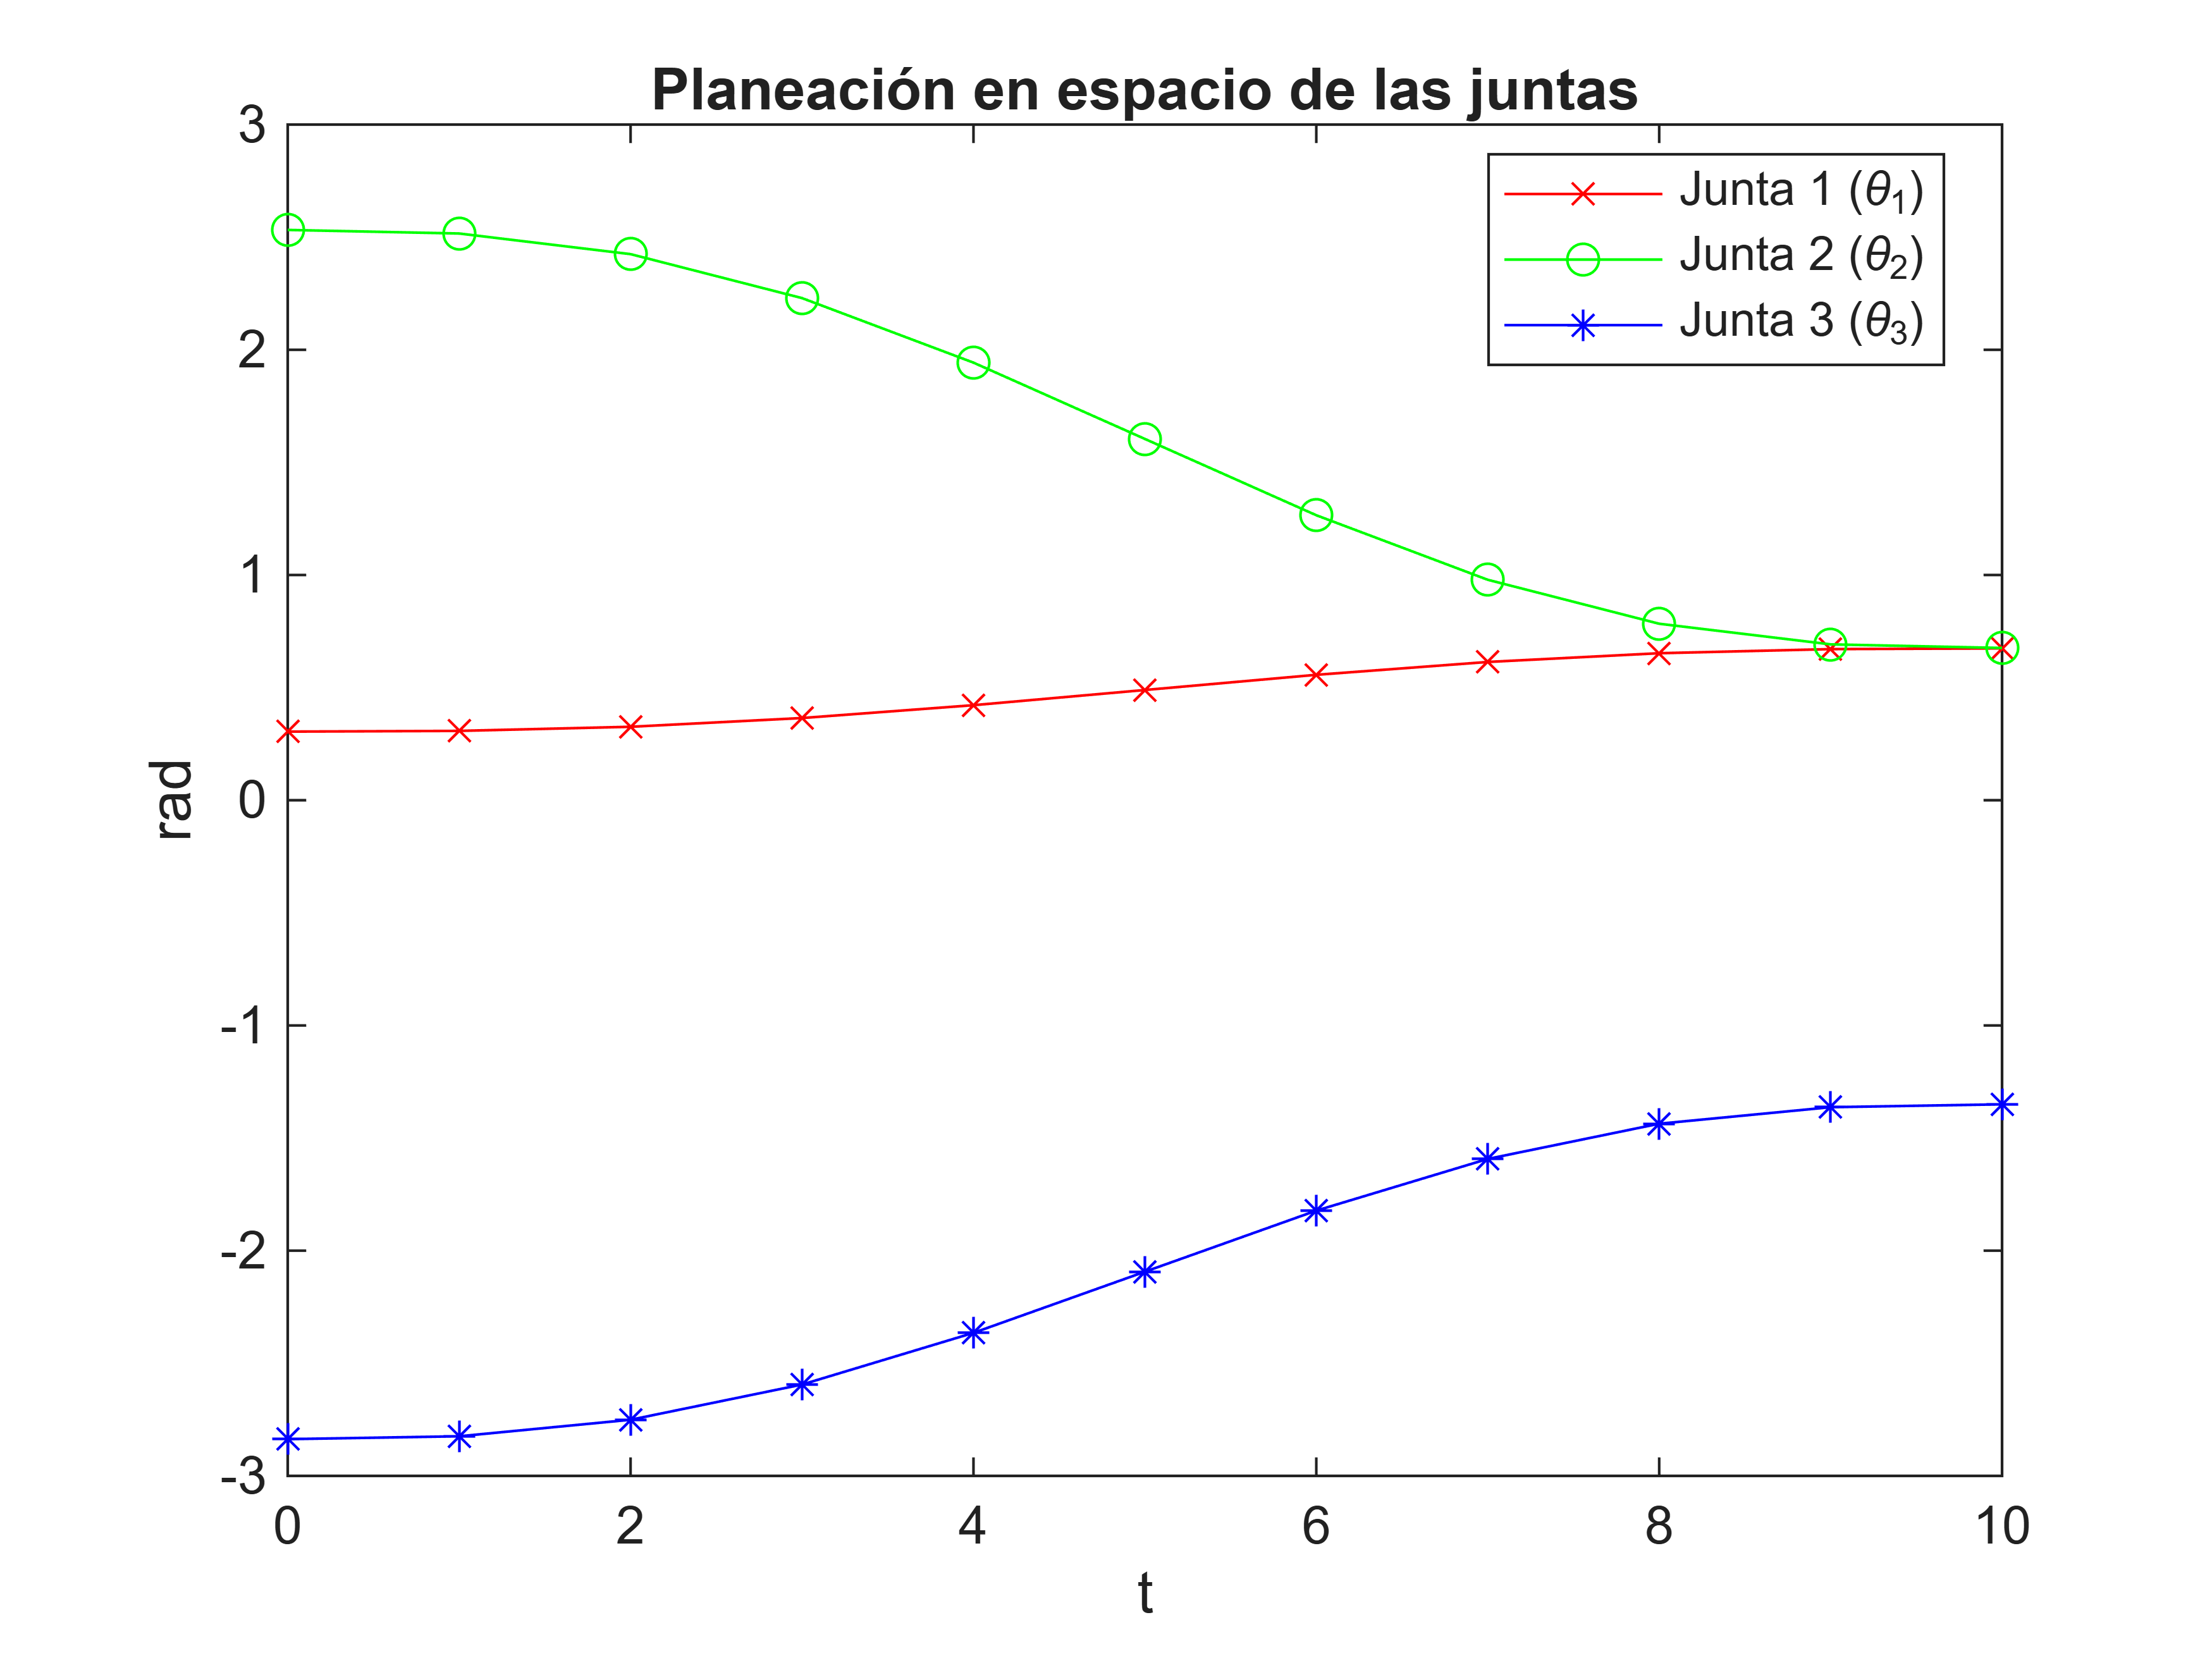

In [11]:
tsim = 0:1:tf; % Creación del vector de tiempo de muestreo para el eje X de las gráficas
figure;


plot(tsim, theta_1_P, 'r-x'); % Grafica la trayectoria de la Junta 1 en color rojo con marcadores 'x'
hold on;
plot(tsim, theta_2_P, 'g-o'); % Grafica la trayectoria de la Junta 2 en color verde con marcadores 'o'
plot(tsim, theta_3_P, 'b-*'); % Grafica la trayectoria de la Junta 3 en color azul con marcadores '*'


hold off;


legend('Junta 1 (\theta_1)', 'Junta 2 (\theta_2)', 'Junta 3 (\theta_3)', 'Location', 'best');
title("Planeación en espacio de las juntas")
xlabel("t")
ylabel("rad")

### Interpretacion de la grafica

Esta gráfica representa visualmente el comportamiento de los motores del robot a lo largo de los 10 segundos del movimiento. Las tres curvas muestran una forma de "S" alargada, lo que confirma el éxito matemático del polinomio de 5.° grado.

### Análisis de las Curvas Obtenidas:

**1. Suavidad en el Arranque y Frenado (Velocidad Cero)**

Si se observa con atención los extremos de cada línea (entre los segundos `0 a 2` y entre `8 a 10`), las curvas son completamente planas u horizontales.

**Qué significa:** La pendiente (velocidad) en esos puntos es cero. El robot arrancará sin dar un tirón brusco y se detendrá en el destino de manera flotante y amortiguada. No habrá vibraciones mecánicas dañinas.

**2. Comportamiento por cada Articulación**

**- (Junta 1 \- Roja):** Realiza un movimiento muy corto y lineal (pasa de `0.30` a `0.67` rad). El primer eslabón casi no tiene que girar en la base.

**- (Junta 2 \- Verde):** Es la que realiza el trabajo más pesado del viaje. Inicia cerrada en `2.53` rad y desciende fluidamente hasta abrirse a `0.67` rad. Alrededor del segundo `5` (mitad del trayecto), la curva tiene su pendiente más inclinada, que es donde el motor alcanzará su velocidad máxima.

**- (Junta 3 \- Azul):** Se desplaza en paralelo a la junta verde (sube de `-2.83` a `-1.35` rad) para ir compensando la rotación del "codo" y mantener la pinza del robot apuntando siempre de frente de forma rígida hacia el eje X.

## 3. Planeación de trayectoria en el espacio de trabajo del robot

La planeación en el espacio de trabajo consiste en la generación del perfil de movimiento controlando directamente las coordenadas tridimensionales o bidimensionales del efector final del manipulador en el espacio físico $(X,Y,\theta )$. A diferencia del control en el espacio articular, este enfoque prioriza la geometría del camino recorrido por la herramienta, lo que resulta indispensable para tareas industriales de alta precisión como trayectorias de soldadura, corte por láser, ensamble o seguimiento de contornos lineales.

En este desarrollo, el objetivo primordial es forzar al efector final del robot SCARA a describir una línea recta diagonal perfecta en el plano cartesiano, desplazándose de forma continua desde la postura inicial $P_{\textrm{in}} =(0.3,0.3,0)$ hasta la postura de destino   $P_{\textrm{fin}} =(0.8,0.8,0)$.

Para lograr que el recorrido cartesiano sea geométricamente exacto y cinemáticamente suave, se ejecuta un algoritmo iterativo basado en los siguientes tres principios fundamentales:

**1. Parametrización Temporal del Camino:** En cada incremento de tiempo $t$, se evalúa un polinomio de interpolación de quinto orden $s(t)$. Este factor normalizado se utiliza para calcular las coordenadas cartesianas instantáneas $(x_t ,y_t ,\theta_t )$ de la trayectoria lineal mediante las siguientes ecuaciones de interpolación: 

$x(t)=x_{\textrm{in}} +s(t)\cdot (x_{\textrm{fin}} -x_{\textrm{in}} )$ ,

$y(t)=y_{\textrm{in}} +s(t)\cdot (y_{\textrm{fin}} -y_{\textrm{in}} )$. 

La selección de un polinomio de quinto grado garantiza analíticamente que tanto las velocidades como las aceleraciones en los extremos del movimiento $t=0$ y $t=t_f$ sean estrictamente iguales a cero, suprimiendo los tirones mecánicos (*jerk*) y las vibraciones estructurales del manipulador.

**2. Desacoplamiento Cinemático de la Muñeca:** A partir de las coordenadas deseadas para la punta del robot en cada instante, se descuenta geométricamente el efecto del tercer eslabón $L_3$ para hallar la posición espacial del centro de la muñeca (intersección entre el eslabón 2 y 3) mediante las ecuaciones:

$x_3 (t)=x(t)-L_3 \cdot \cos (\theta_t )$ , 

$y_3 (t)=y(t)-L_3 \cdot \sin (\theta_t )$  .

**3. Resolución de la Cinemática Inversa en Tiempo Real:** Con las coordenadas de la muñeca actualizadas paso a paso, el algoritmo ejecuta de forma continua el método geométrico (Teorema de los Cosenos y funciones arcotangente $\textrm{atan2}$ ) para transformar la posición cartesiana en las consignas angulares requeridas para la Junta 1 $\theta_1$ y la Junta 2 $\theta_2$, bajo una configuración de "codo arriba" (*elbow\-up*).

### Evaluación Técnica del Enfoque

**- Ventajas:** Ofrece un control absoluto y predecible sobre el entorno de trabajo. Al conocer la posición exacta de cada punto del trayecto en milímetros o metros, se simplifica el diseño de zonas seguras y algoritmos de evasión de obstáculos fijos o dinámicos en la celda robótica.

**- Limitaciones y Riesgos:** Presenta una carga computacional elevada debido a la resolución masiva de ecuaciones trigonométricas inversas dentro del bucle de control en tiempo real. Adicionalmente, al obligar al robot a mantener una línea recta estricta cerca de su alcance máximo de extensión $L_1 +L_2 =1.0\;\textrm{m}$, el sistema opera en las inmediaciones de una singularidad cinemática. Esto puede demandar velocidades angulares excesivamente altas o provocar inestabilidades numéricas cerca del punto de destino.


In [12]:
% =========================================================================
% PLANEACIÓN DE TRAYECTORIA EN EL ESPACIO DE TRABAJO (ESPACIO CARTESIANO)
% =========================================================================


% Definición de los parámetros físicos del robot SCARA (Longitudes en metros)
L1 = 0.5; % Longitud del primer eslabón
L2 = 0.5; % Longitud del segundo eslabón
L3 = 0.3; % Longitud del tercer eslabón


% Configuración de las poses extremas de la trayectoria diagonal
% Pose inicial (X, Y, Orientación)
x_in = 0.3;
y_in = 0.3;
theta_in = 0;
 % Pose final (X, Y, Orientación)
x_fin = 0.8;
y_fin = 0.8;
theta_fin = 0;


tf = 10;  % Tiempo total del movimiento (segundos)


for i=1:tf+1
    t = i;


    % --- GENERACIÓN DE LA LÍNEA RECTA CARTESIANA CON POLINOMIO DE 5TO GRADO ---
    % Se calcula la posición X, Y y la orientación deseada para cada instante 't'
    x_P(i) = x_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(x_fin-x_in);
    y_P(i) = y_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(y_fin-y_in);
    theta_P(i) = theta_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_fin-theta_in);


    % --- DESACOPLAMIENTO CINEMÁTICO DE LA MUÑECA ---
    % Se resta el efecto del eslabón L3 para hallar las coordenadas del centro de la muñeca
    x_3_a(i) = x_P(i) - L3*cos(theta_P(i));
    y_3_a(i) = y_P(i) - L3*sin(theta_P(i));


   % --- RESOLUCIÓN DE CINEMÁTICA INVERSA POR MÉTODO GEOMÉTRICO ---

    % Cálculo del ángulo de la Junta 2 (Codo) mediante el Teorema de los Cosenos


    theta_2_tray(i) = acos((x_3_a(i)^2+y_3_a(i)^2-L1^2-L2^2)/(2*L1*L2));


      % Cálculo del ángulo polar 'beta' desde la base hasta la muñeca
    beta = atan2(y_3_a(i),x_3_a(i));

     % Cálculo del ángulo interno 'psi' del triángulo formado por los eslabones
    psi = acos((x_3_a(i)^2+y_3_a(i)^2+L1^2-L2^2)/(2*L1*sqrt(x_3_a(i)^2+y_3_a(i)^2)));


     % Cálculo del ángulo de la Junta 1 (Base) utilizando la configuración Codo Arriba
    theta_1_tray(i) = beta + psi;


    theta_1_in = beta - psi;


     % Cálculo del ángulo de la Junta 3 (Orientación de la herramienta)
    theta_3_tray(i) = theta_P(i) - theta_1_tray(i) - theta_2_tray(i);
end



In [13]:
tsim=0:1:tf

tsim = 1x11
     0     1     2     3     4     5     6     7     8     9    10


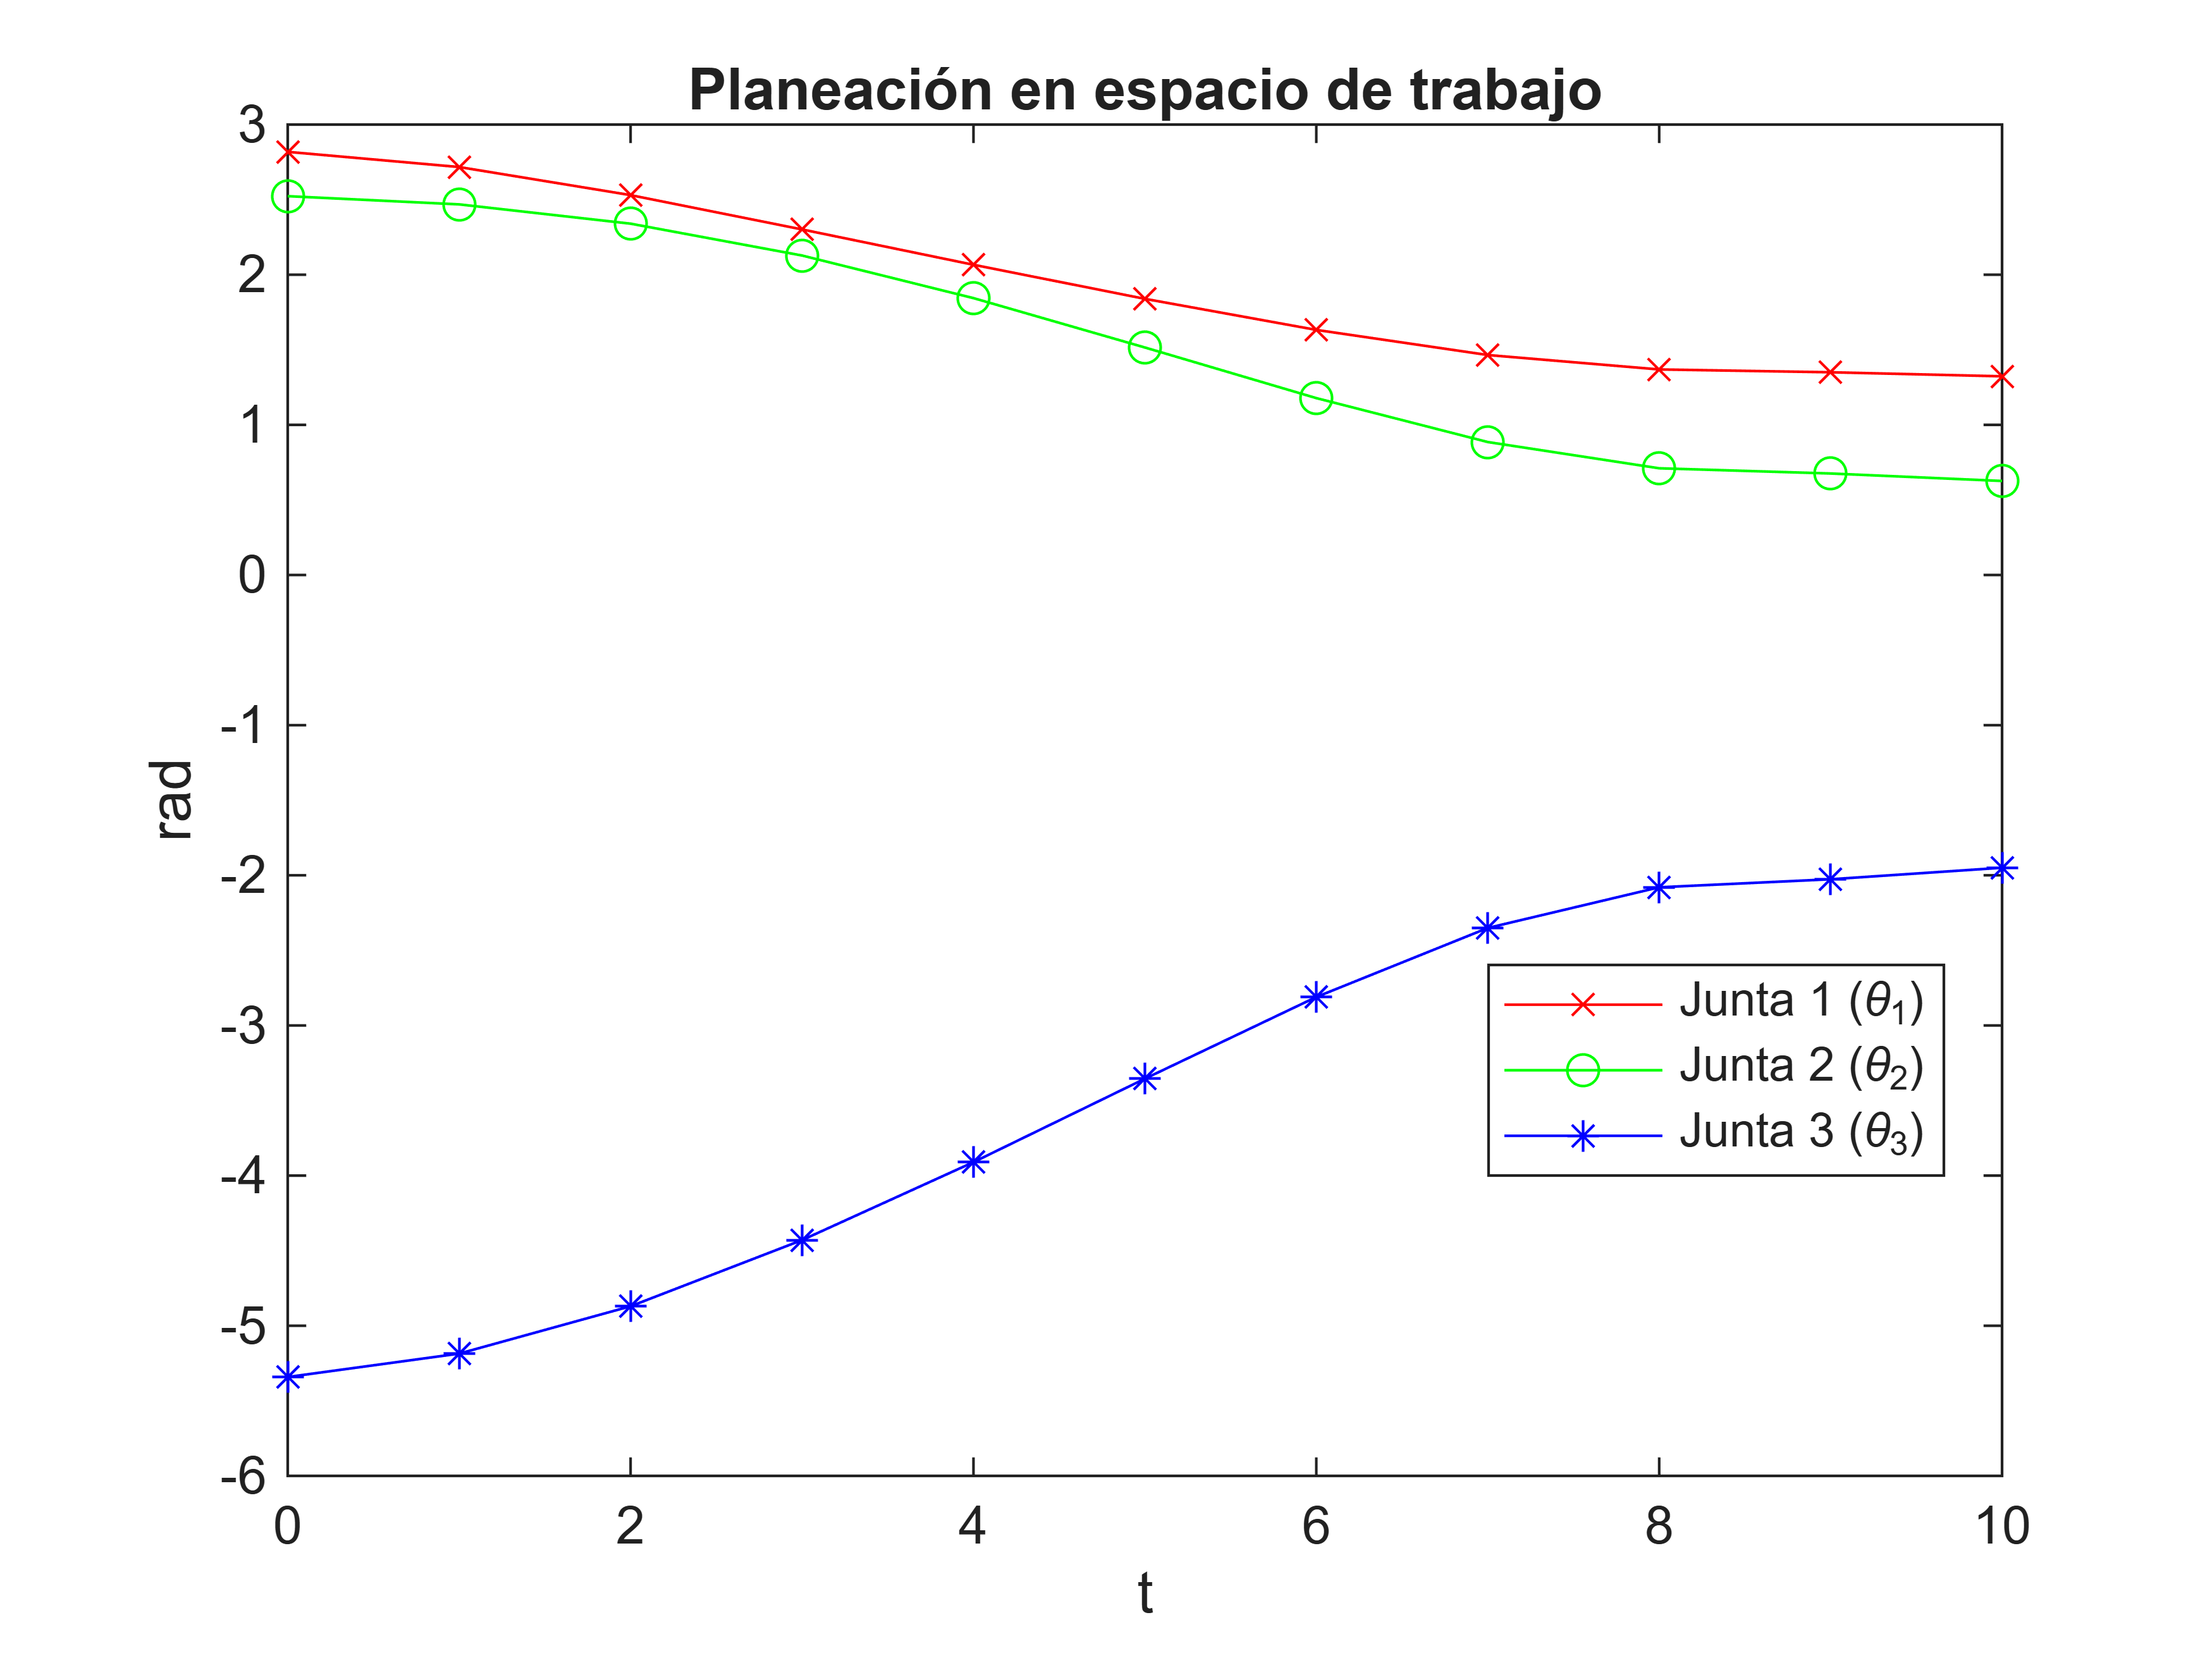

In [14]:
figure;


plot(tsim, theta_1_tray, 'r-x');
hold on;
plot(tsim, theta_2_tray, 'g-o');
plot(tsim, theta_3_tray, 'b-*');


hold off;


legend('Junta 1 (\theta_1)', 'Junta 2 (\theta_2)', 'Junta 3 (\theta_3)', 'Location', 'best');
title("Planeación en espacio de trabajo")
xlabel("t")
ylabel("rad")


### Análisis de las Curvas en el Espacio de Trabajo

**1. El Impacto de la Línea Recta en los Motores**

A diferencia de la primera gráfica (donde las curvas eran suaves simétricas en forma de "S"), aquí se nota que las líneas no son perfectamente simétricas.

*- Por qué ocurre:* Debido a que la cinemática del robot es no lineal (usa senos y cosenos), para que la punta del robot se mueva en una línea recta exacta en el mundo real, los motores se ven obligados a acelerar y desacelerar de forma asimétrica.

**2. Comportamiento Crítico de la Junta 3 (Azul)**

Observe el enorme recorrido que realiza la Junta 3: comienza en casi $-5.4$ radianes y sube hasta $-2.0$ radianes.

*- El problema físico:* Un valor de $-5.4\;$ radianes equivale a aproximadamente $-309^{\circ } \textrm{.}$

*- El riesgo:* En la práctica y en simuladores como Gazebo, la mayoría de los actuadores rotativos comerciales tienen límites de giro de $\pm 180^{\circ } \;\textrm{(}\pm 3.14\;\textrm{rad)}$. Si tu robot real o virtual tiene esta restricción física en el tercer motor, el robot se trabará o arrojará un error de límites al intentar iniciar en el segundo cero.

**3. Evidencia del Límite de Extensión (Hacia el segundo 10)**

Si se observan las tres curvas entre los segundos 8 y 10, se notará que se vuelven casi completamente horizontales (planas). Esto demuestra que el polinomio de 5.° grado está haciendo bien su trabajo cartesiano: frena la velocidad lineal de la punta antes de llegar al destino final, lo que le da estabilidad al robot justo cuando el brazo está más estirado y cerca de su límite físico de alcance.



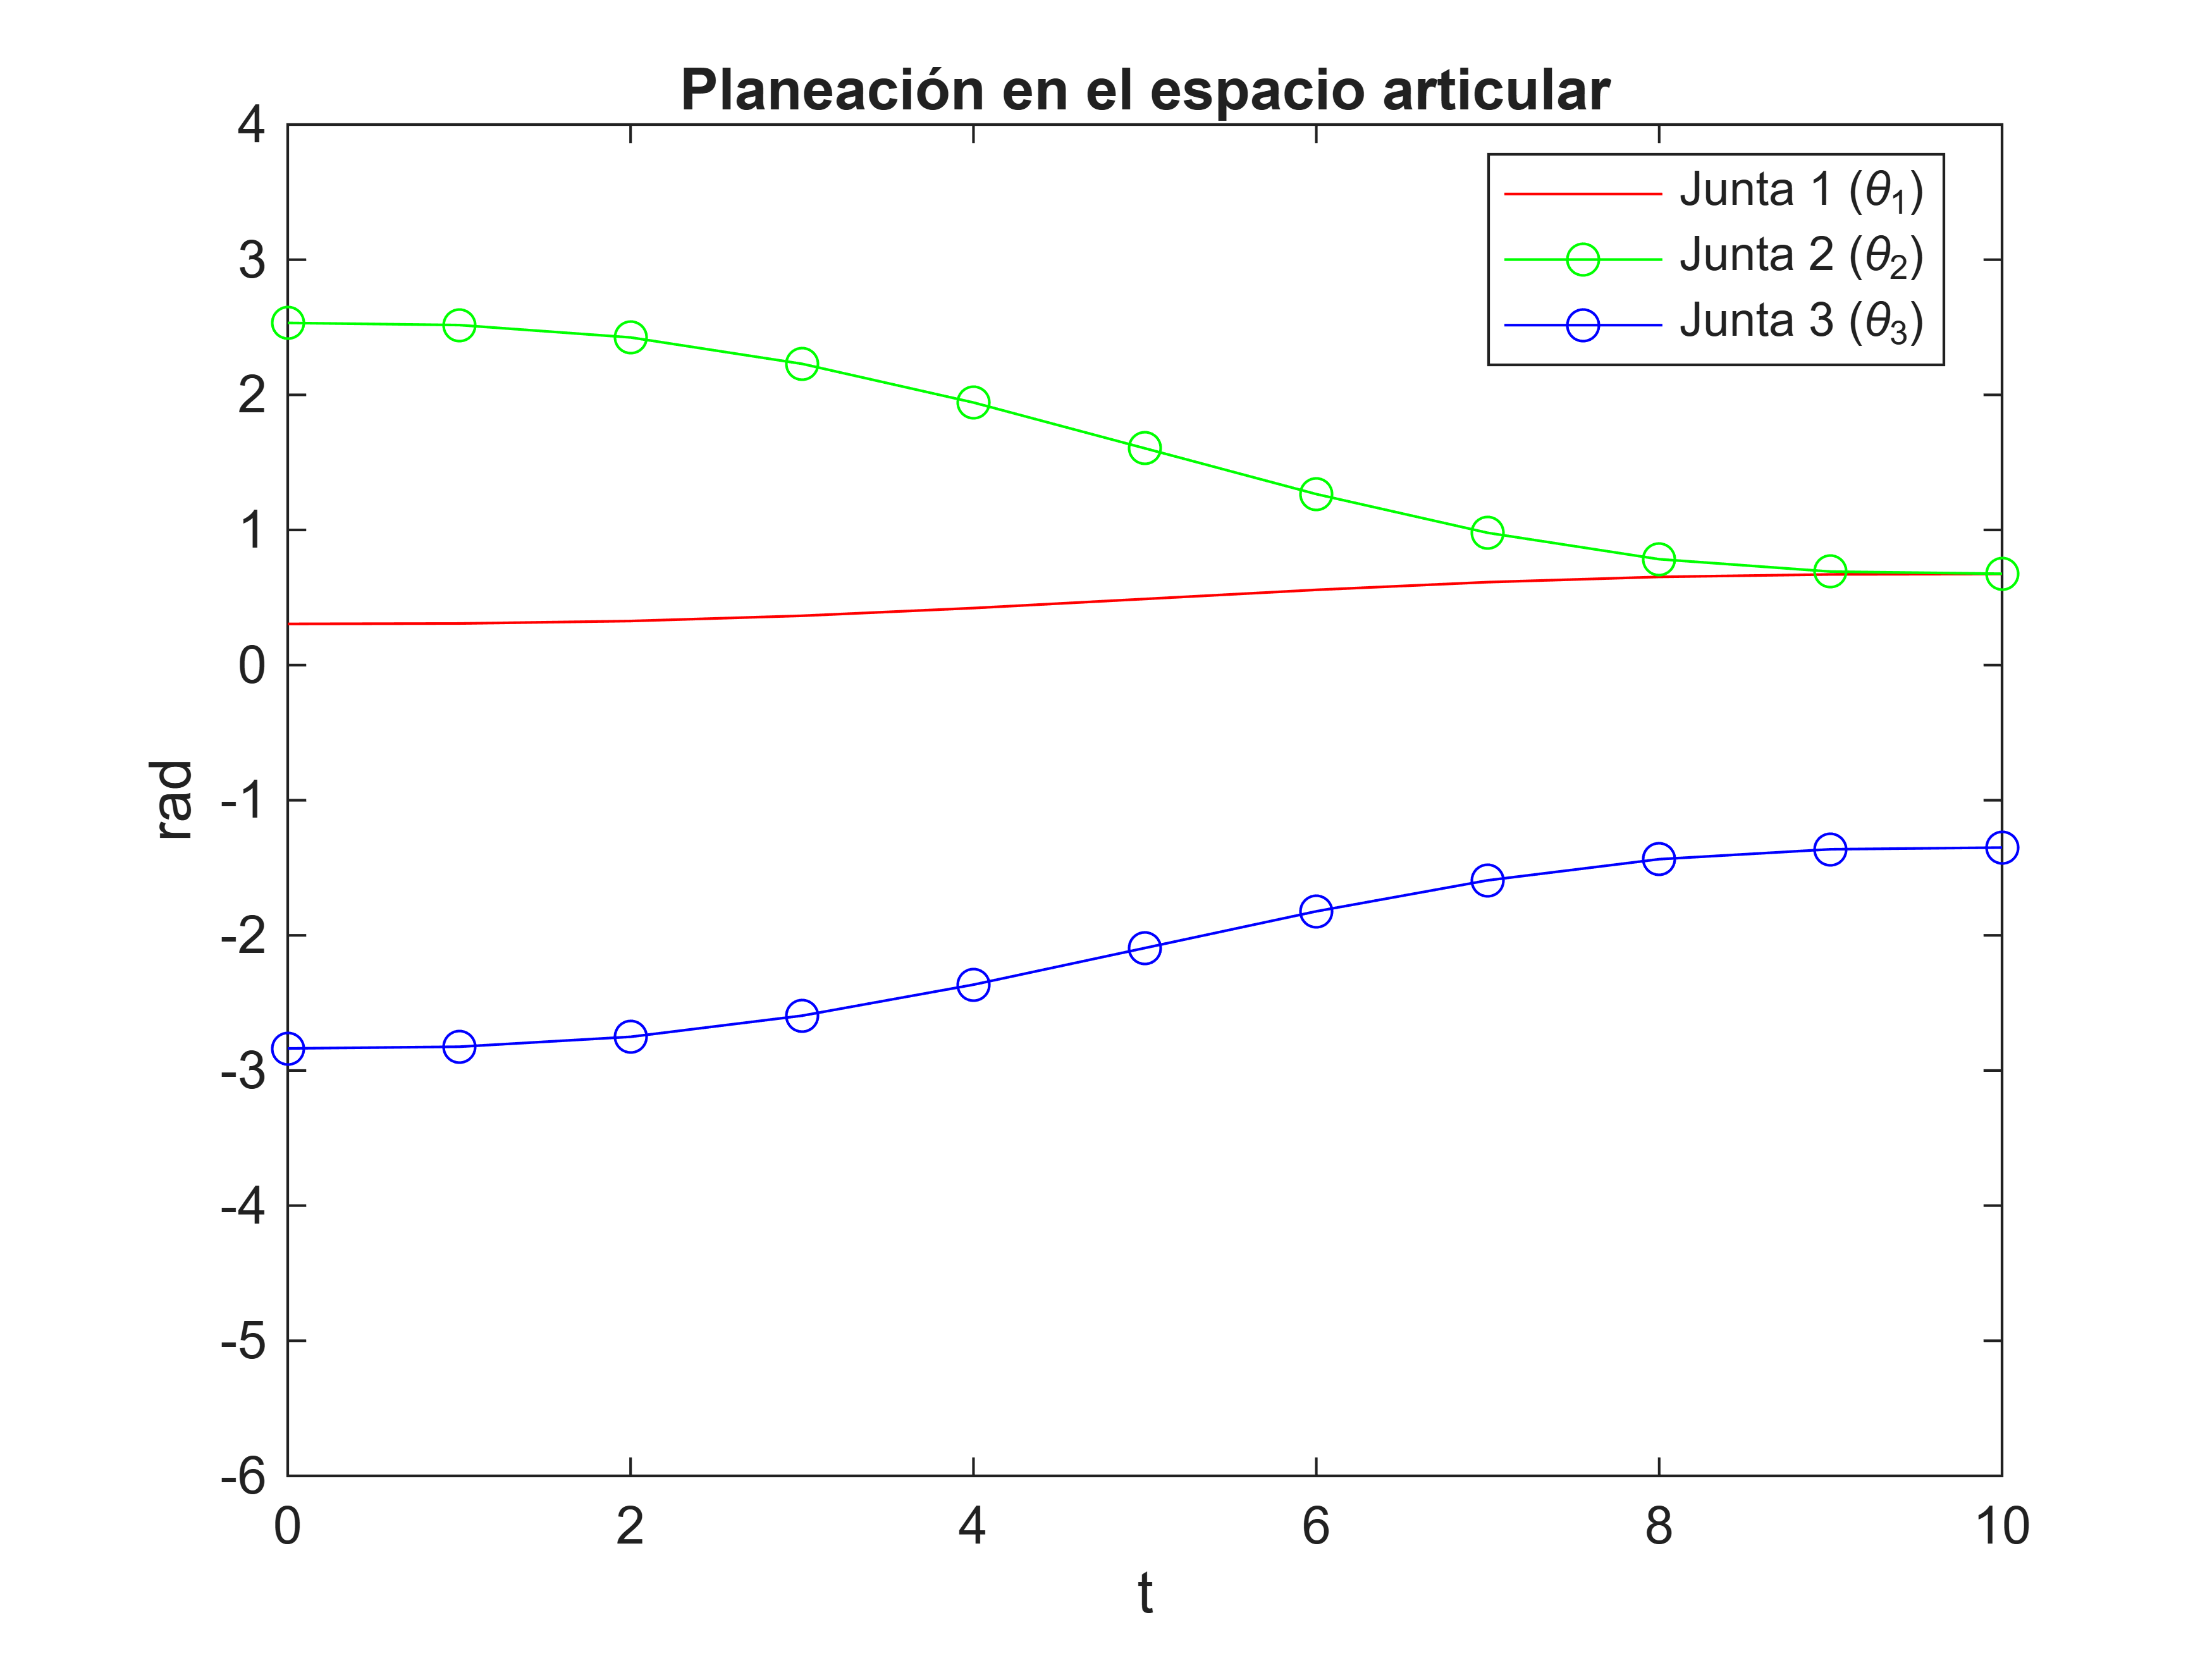

In [15]:


figure;


plot(tsim, theta_1_P, 'r-');
hold on;
plot(tsim, theta_2_P, 'g-o');
plot(tsim, theta_3_P, 'b-o');


hold off;


xlim([0.00 10.00])
ylim([-6.0 4.0])
legend('Junta 1 (\theta_1)', 'Junta 2 (\theta_2)', 'Junta 3 (\theta_3)', 'Location', 'best');
title("Planeación en el espacio articular")
xlabel("t")
ylabel("rad")

#### Analisis 

Al observar esta gráfica de la Planeación en el espacio articular, podemos extraer conclusiones muy claras sobre el comportamiento de los motores antes de compararla con la otra:

**1. Simetría y suavidad perfectas**

A diferencia de la gráfica cartesiana, aquí las curvas son perfectamente simétricas. Esto ocurre porque los motores se mueven de forma 100% independiente. Cada uno sigue su propia función polinomial pura de quinto grado sin tener que torcerse o acelerar de más para compensar la posición del otro.

**2. Velocidades máximas predecibles**

El punto de mayor inclinación (máxima pendiente) de todas las curvas ocurre exactamente en el segundo 5 (la mitad del tiempo). Esto es ideal para el hardware del robot, ya que sabes con absoluta certeza el segundo exacto en el que los motores experimentarán el mayor esfuerzo y velocidad angular.

**3. Rangos de operación mecánicamente viables**

Esta gráfica demuestra que los motores trabajan de forma mucho más holgada y cómoda:

*- Junta 1 (Roja):* Casi no se mueve. Pasa de $0.30$ a $0.67$ rad de manera casi plana. Su esfuerzo es mínimo.

*- Junta 2 (Verde):* Realiza un descenso continuo y fluido desde $2.53$ hasta $0.67$ rad.

*- Junta 3 (Azul):* Arranca en $-2.83$ rad (aproximadamente $-162^{\circ }$ ) y termina en $-1.35$ rad (aproximadamente $-77^{\circ }$ ).

**El punto clave de esta gráfica**

El motor 3 (curva azul) arranca en $-2.83$ rad. Como este valor es mayor que $-\pi \;\textrm{(}-3.14)$ rad o $(-180^{\circ } )$, el motor se mantiene dentro del rango físico permitido por la inmensa mayoría de los servos industriales convencionales. Ningún motor tiene que dar vueltas completas sobre su propio eje para empezar el movimiento.

**4. Análisis Comparativo de Resultados**

**4.1. Comportamiento en el Espacio Articular (Juntas)**

Al observar los perfiles temporales generados mediante la planeación en el espacio articular (Figura anterior), se evidencia una simetría perfecta en forma de "S" en todas las curvas de posición. Las pendientes de arranque $-\pi$ y llegada $-\pi$ son nulas, validando el correcto acoplamiento del polinomio de quinto orden.

Bajo este enfoque, la Junta 3 opera en un rango seguro y acotado, iniciando en $-2.83\;\textrm{rad}\;\textrm{(}-162.54^{\circ } \textrm{)}$ y finalizando en $-1.35\;\textrm{rad}\;\textrm{(}-77.35^{\circ } \textrm{)}$, lo que se mantiene dentro de los límites comerciales estándar de $\pm \pi \;\textrm{rad}\;\textrm{(}\pm 180^{\circ } \textrm{)}$. Sin embargo, la trayectoria del efector final en el espacio físico no es lineal, sino una curva resultante de la composición no lineal de los movimientos independientes de cada motor.

**4.2. Comportamiento en el Espacio de Trabajo (Cartesiano)**

En contraste, la planeación en el espacio de trabajo obliga al efector final a seguir una línea recta diagonal estricta en el plano cartesiano. Al analizar las curvas de posición articular resultantes (Figura actual), se detectan dos fenómenos críticos provocados por la no linealidad de la cinemática inversa del robot SCARA:

**1. Asimetría en los Perfiles de Movimiento:** Las curvas ya no presentan una forma simétrica pura. Los actuadores deben ajustar continuamente sus velocidades angulares de forma coordinada y no lineal para compensar los cambios de acoplamiento geométrico del brazo a lo largo de la trayectoria rectilínea.

**2. Saturación en el Desplazamiento de la Junta 3:** El fenómeno más severo ocurre en la Junta 3 (curva azul), la cual se ve obligada a iniciar en un valor extremo de aproximadamente $-5.35\;\textrm{rad}\;\textrm{(equivalente}\;\textrm{a}\;-306.5^{\circ } \textrm{)}$.

**4.3. Discusión Técnica y Criterio de Selección**

Aunque la planeación en el espacio de trabajo cumple con el objetivo geométrico de trazar la línea recta deseada, el requerimiento de giro de $-306.5^{\circ }$ en la Junta 3 representa un riesgo crítico de saturación por límites físicos o mecánicos (*joint limits*) en un robot real o en entornos de simulación física restrictivos como Gazebo.

Por lo tanto, si el diseño mecánico del manipulador SCARA implementado limita el giro de la muñeca a rangos estándar de $\pm 180^{\circ }$, la trayectoria cartesiana propuesta en la zona de trabajo $(0.3,0.3)\;\textrm{a}\;(0.8,0.8)\;$ resultaría físicamente inviable sin una reconfiguración previa del signo o cambio de la postura geométrica (conmutación a configuración de codo abajo). En cambio, la planeación en el espacio articular ofrece un movimiento realizable para los motores, a costa de sacrificar la rectitud del trazo en el espacio cartesiano.


In [16]:
%w = L1*L2*sin(theta_2)


### 4. Calculo de la cinemática de velocidades del robot

Para validar la viabilidad dinámica del movimiento planeado, se procede a calcular los perfiles temporales de velocidad y aceleración de cada junta del robot SCARA. Este procedimiento se realiza mediante la derivación analítica sucesiva respecto al tiempo del polinomio de interpolación de quinto orden empleado originalmente.

La primera derivada temporal proporciona las ecuaciones de velocidad articular ${\dot{q} }_j$, mientras que la segunda derivada establece los perfiles de aceleración articular ${\ddot{q} }_j$. La implementación de este formalismo matemático asegura de forma analítica que tanto las velocidades como las aceleraciones en las fronteras de la tarea $((t=0\;\textrm{s})~y~(t=10\;\textrm{s}))$ comiencen y terminen estrictamente en cero. Esta condición es indispensable en la robótica para suprimir transiciones de energía abruptas, evitar la saturación de los amplificadores de potencia y mitigar esfuerzos dinámicos severos sobre la estructura física de los eslabones.

**- Velocidad** $P_v :\dot{s} (t)=\frac{30}{t_f^3 }t^2 -\frac{60}{t_f^4 }t^3 +\frac{30}{t_f^5 }t^4$


**- Aceleración** $P_a :\ddot{s} (t)=\frac{60}{t_f^3 }t-\frac{180}{t_f^4 }t^2 +\frac{120}{t_f^5 }t^3$



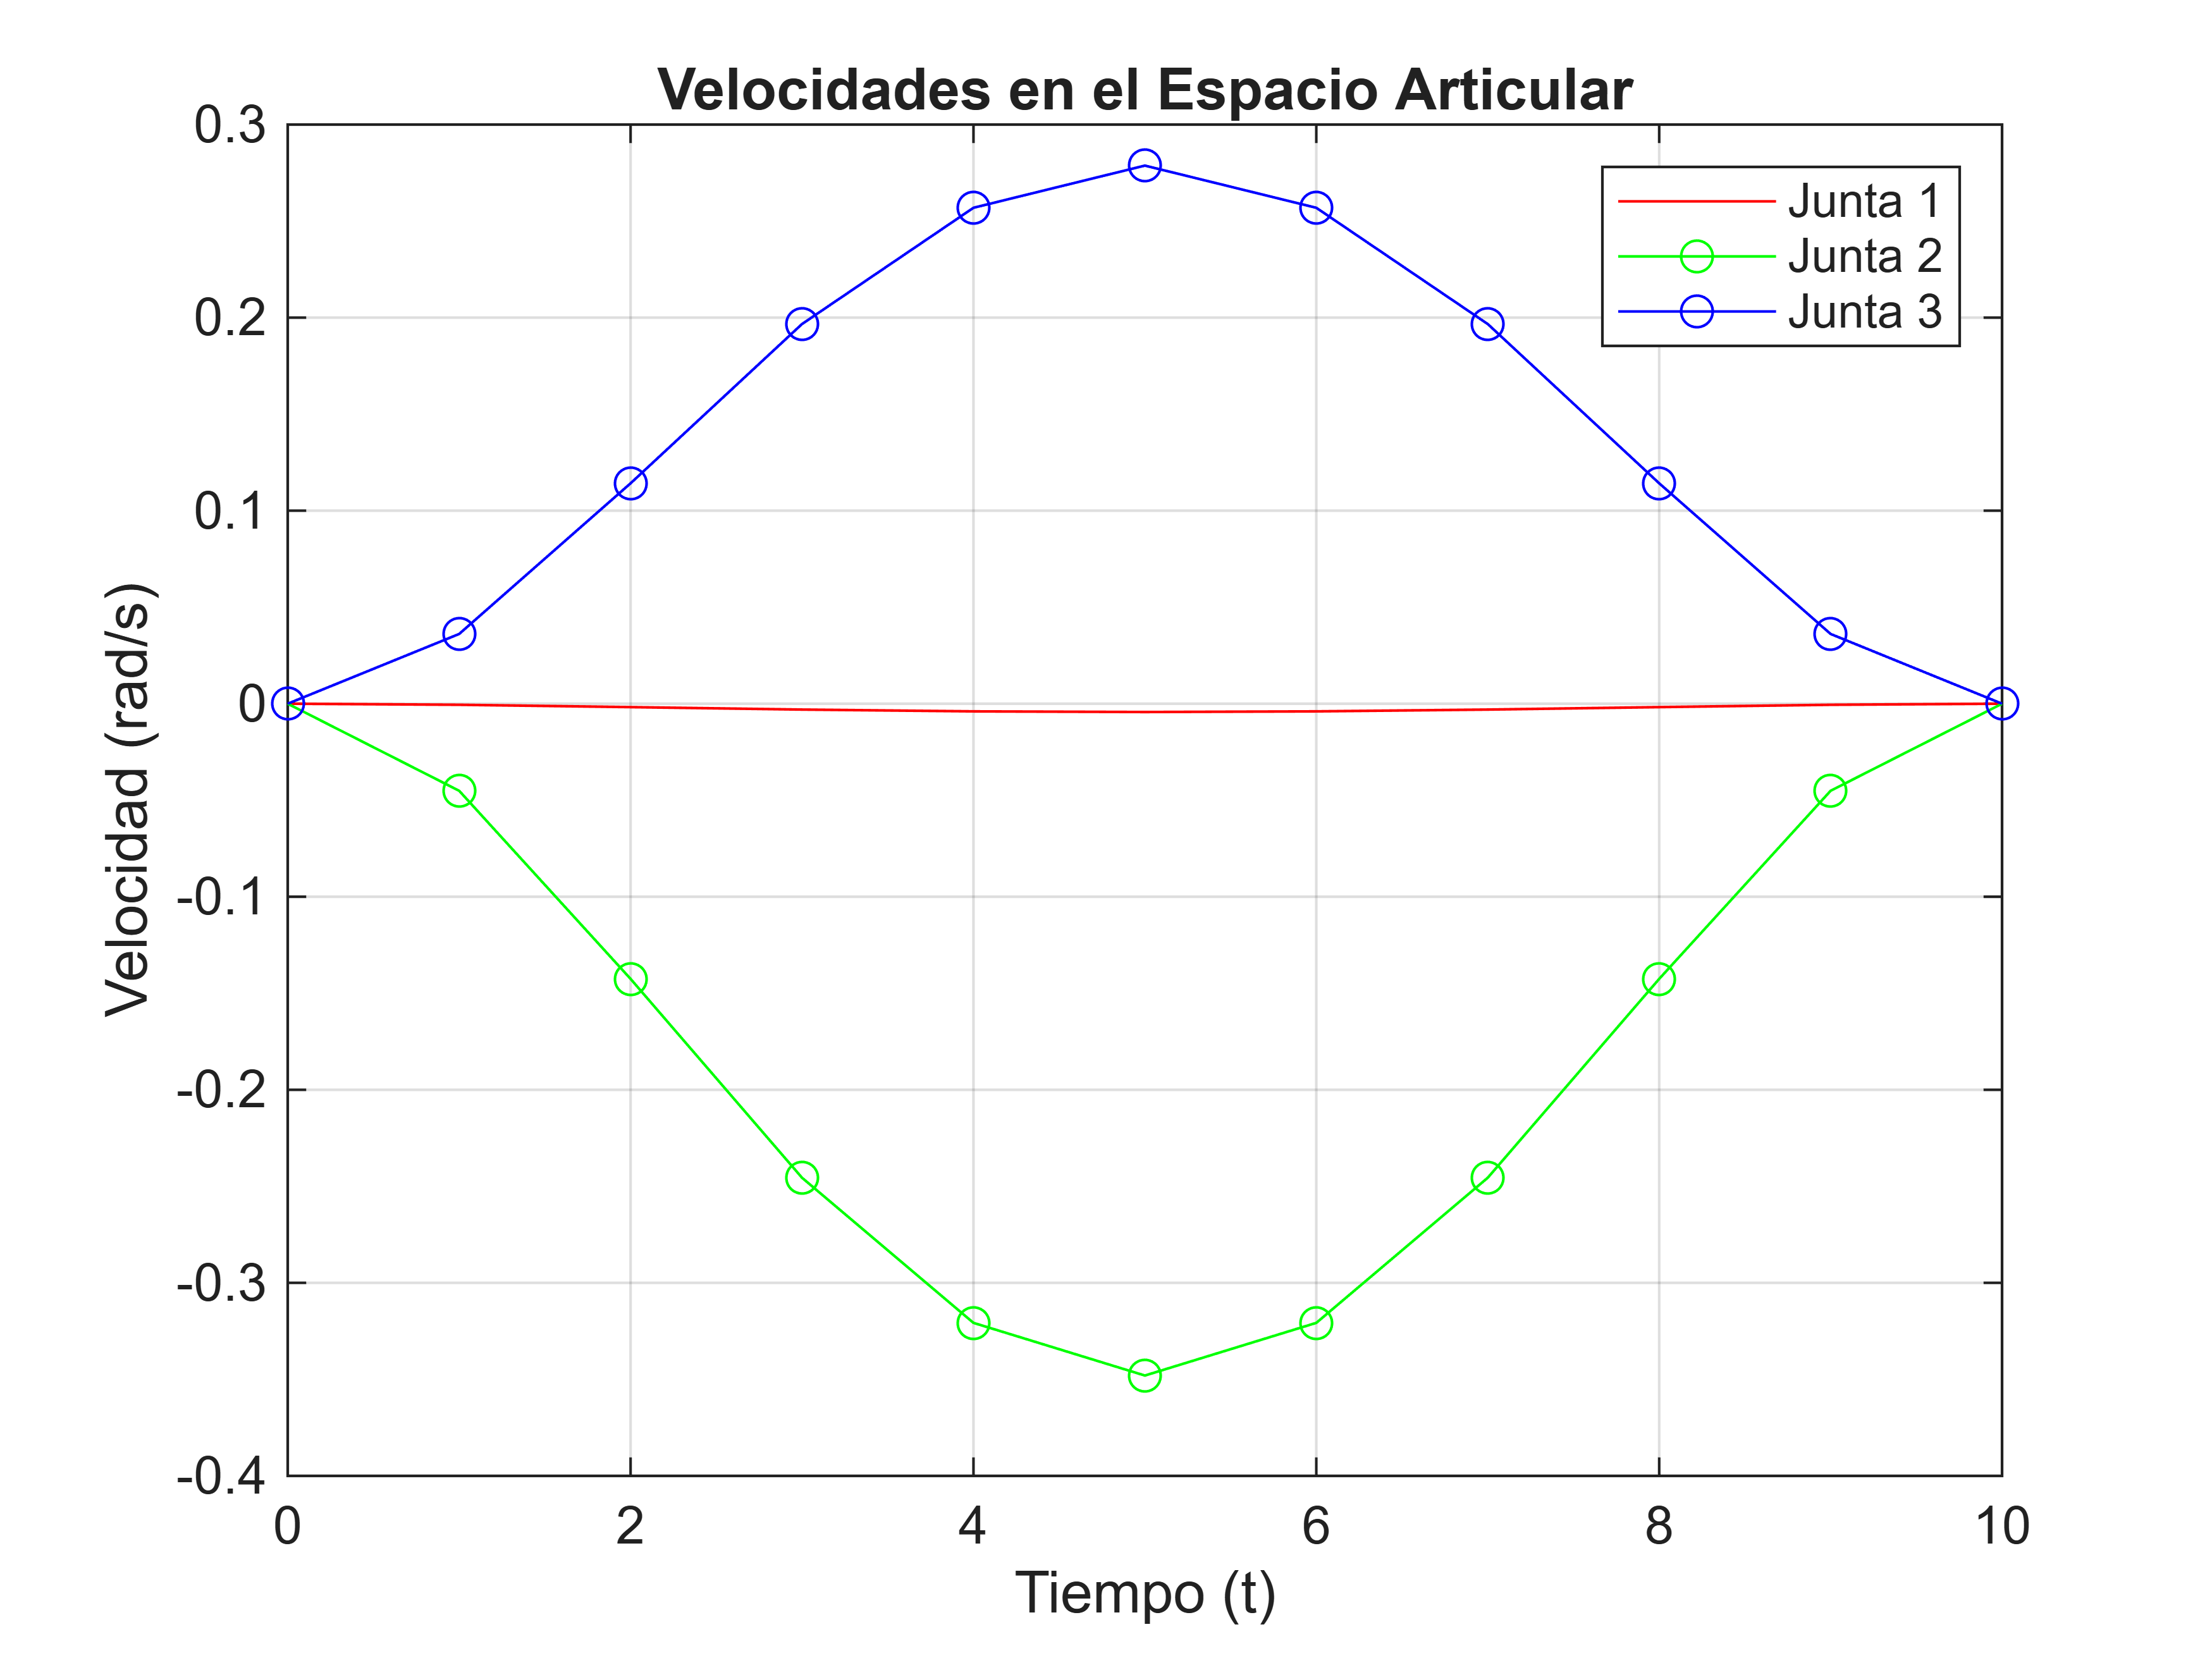

In [17]:
% =========================================================================
% CÁLCULO DE LA CINEMÁTICA DE VELOCIDADES Y ACELERACIONES DEL ROBOT
% =========================================================================


% Definición del tiempo final de la trayectoria (10 segundos)
tf = 10;


% --- BUCLE 1: CÁLCULO DE VELOCIDADES ARTICULARES ---
for i=1:tf+1
    % Convierte el índice numérico a tiempo real (de 0 a 10 segundos)
    t = i-1;

    % Primera derivada del polinomio de 5to grado multiplicada por el delta de posición
    theta_1_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_1_fin-theta_1_in);
    theta_2_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_2_fin-theta_2_in);
    theta_3_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_3_fin-theta_3_in);
end


% Definición del vector de tiempo
tsim = 0:1:tf;


% --- GENERACIÓN DE LA GRÁFICA DE VELOCIDADES ---
figure;
plot(tsim, theta_1_P_v, 'r-'); hold on;  % Velocidad Junta 1 (Rojo)
plot(tsim, theta_2_P_v, 'g-o');          % Velocidad Junta 2 (Verde con círculos)
plot(tsim, theta_3_P_v, 'b-o'); hold off;% Velocidad Junta 3 (Azul con círculos)
title("Velocidades en el Espacio Articular"); xlabel("Tiempo (t)"); ylabel("Velocidad (rad/s)");
legend('Junta 1', 'Junta 2', 'Junta 3'); grid on;


### Análisis de la Gráfica de Velocidades Articulares

**1. Cumplimiento de las Condiciones de Frontera**

Se observa los extremos de las tres curvas en los segundos $t=0$ y $t=10\textrm{.}$

**- Resultado:** Todas las velocidades inician y terminan exactamente en $0\;\textrm{rad/s}$.

**- Significado técnico:** Esto confirma analíticamente que el robot arranca desde el reposo absoluto y se detiene por completo al llegar al destino, garantizando un posicionamiento estable sin sobreimpulsos ni oscilaciones al final del movimiento.

**2. Forma Parabólica Perfecta y Simetría**

Las curvas tienen una geometría acampanada (parabólica) perfectamente simétrica. El punto crítico (pico máximo) ocurre exactamente en el segundo $t=5\;\textrm{s}$ (la mitad del tiempo total de la trayectoria).

**3. Comportamiento Individual de los Actuadores**

*- Junta 1 (Roja):* Su velocidad es prácticamente una línea horizontal sobre el cero. Como el primer eslabón recorre una distancia angular mínima $(0.37\;\textrm{rad})$, su velocidad pico es despreciable $\approx -0.014\;\textrm{rad/s}$, operando con un esfuerzo motor mínimo.

*- Junta 2 (Verde):* Presenta una velocidad negativa que alcanza su punto más bajo en $-0.35\;\textrm{rad/s}$ en el segundo $5$. El signo negativo indica que el motor está girando en sentido horario para abrir el codo del robot (pasando de un ángulo cerrado de $2.53\;\textrm{rad}$ a uno más extendido de $0.67\;\textrm{rad}$.

*- Junta 3 (Azul):* Presenta una velocidad positiva con un pico de $0.28\;\textrm{rad/s}$ en el segundo $5$. El signo positivo muestra que la muñeca gira en sentido antihorario para contrarrestar la apertura del codo y mantener la orientación horizontal de la herramienta fija respecto al mundo.



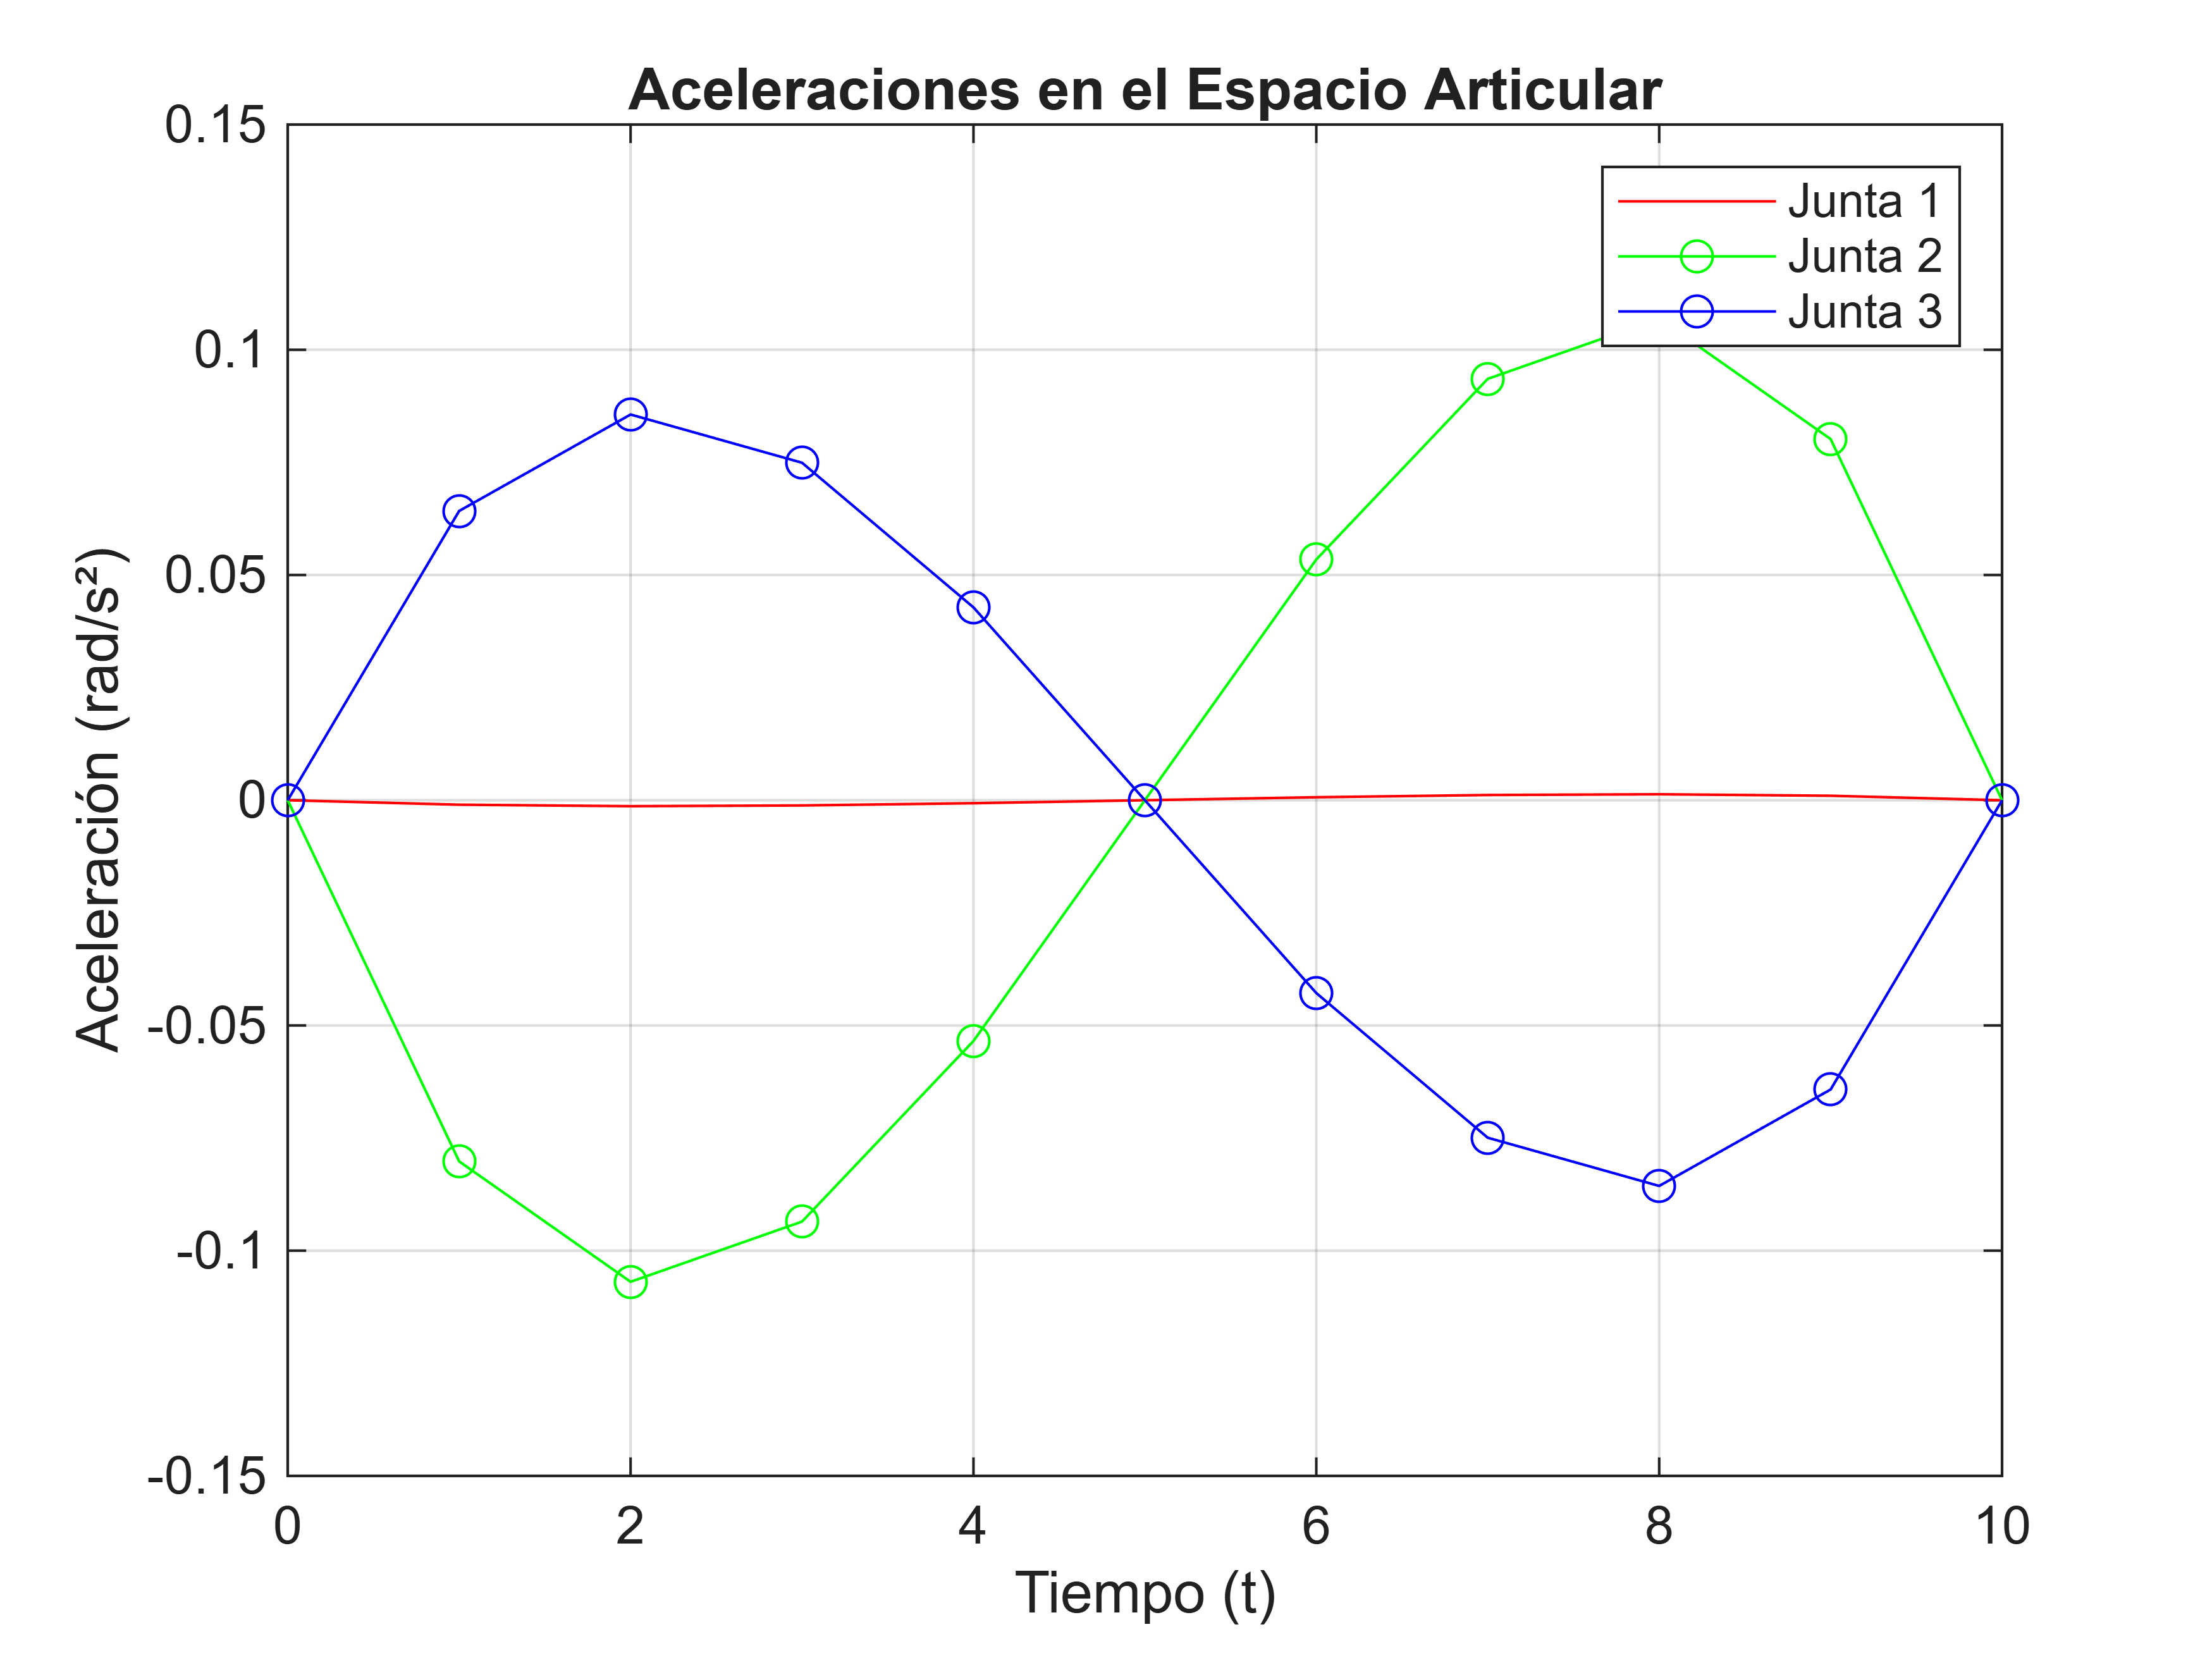

In [18]:
% Re-definición del tiempo final para el bloque de aceleraciones
tf = 10;


% --- BUCLE 2: CÁLCULO DE ACELERACIONES ARTICULARES ---
for i=1:tf+1
    % Convierte el índice numérico a tiempo real (de 0 a 10 segundos)
    t = i-1;

    % Segunda derivada del polinomio de 5to grado multiplicada por el delta de posición
    theta_1_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_1_fin-theta_1_in);
    theta_2_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_2_fin-theta_2_in);
    theta_3_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_3_fin-theta_3_in);
end


% --- GENERACIÓN DE LA GRÁFICA DE ACELERACIONES ---
figure;
plot(tsim, theta_1_P_a, 'r-'); hold on;  % Aceleración Junta 1 (Rojo)
plot(tsim, theta_2_P_a, 'g-o');          % Aceleración Junta 2 (Verde con círculos)
plot(tsim, theta_3_P_a, 'b-o'); hold off;% Aceleración Junta 3 (Azul con círculos)
title("Aceleraciones en el Espacio Articular"); xlabel("Tiempo (t)"); ylabel("Aceleración (rad/s²)");
legend('Junta 1', 'Junta 2', 'Junta 3'); grid on;


### Análisis de la Gráfica de Aceleraciones Articulares

**1. Cruce por Cero en la Mitad del Tiempo $(t=5\;\textrm{s})$**

Se observa el punto central donde se cruzan todas las líneas en el segundo 5.

*- Significado técnico:* En ese instante exacto, la aceleración de todas las juntas es cero. Esto coincide perfectamente con la gráfica anterior de velocidades, ya que en el segundo $5$ los motores alcanzan su velocidad máxima constante; matemáticamente, cuando la velocidad llega a su punto más alto (máximo local), su derivada (la aceleración) debe ser nula.

**2. Comportamiento en los Extremos $(t=0\;\textrm{s})$ y $(t=10\;\textrm{s})$**

Las curvas inician y terminan estrictamente en $0{\;\textrm{rad/s}}^2 \textrm{.}$

*- Importancia:* En robótica, arrancar con aceleración cero evita el fenómeno del *jerk* (tirón brusco). Esto protege la integridad física de los reductores mecánicos y los acoples de los motores, previniendo esfuerzos de torsión destructivos en el instante del arranque.

**3. Fases de Aceleración y Frenado**

La gráfica se divide simétricamente en dos etapas:

*- Segundos $0$ a $5$ (Aceleración):* La Junta 2 (verde) experimenta una aceleración negativa, alcanzando su pico de $-0.11{\;\textrm{rad/s}}^2$ en el segundo 2. Al mismo tiempo, la Junta 3 (azul) acelera en sentido positivo con un pico de $0.085{\;\textrm{rad/s}}^2 \textrm{.}$


*- Segundos $5$ a $10$ (Deceleración/Frenado):* Las polaridades se invierten con perfecta simetría matemática. Las juntas aplican un torque inverso para desacelerar suavemente el brazo y asegurar que se detenga sin pasarse del punto de destino.

## 5. Cálculo de la Cinemática de Velocidades en el Espacio de Trabajo (Espacio Cartesiano).

### Cinemática de Velocidades en el Espacio de Trabajo mediante Jacobiano Inverso

Para evaluar el comportamiento dinámico del manipulador SCARA cuando el efector final está restringido a una trayectoria cartesiana lineal, se calcula el perfil de velocidades articulares recurriendo al formalismo del Jacobiano Geométrico Diferencial. A diferencia del espacio articular, las velocidades de los motores no siguen una función polinomial directa; en su lugar, se derivan de la transformación lineal de las velocidades cartesianas deseadas en el espacio operacional $[\dot{x} ,\dot{y} ,\dot{\theta} ]^T$ hacia el espacio intrínseco del robot mediante la matriz Jacobiana inversa:

$$\dot{\mathbf{q}} (t)={\mathbf{J}}^{-1} (\mathbf{q})\cdot \dot{\mathbf{x}} (t)$$

Este método calcula analíticamente la velocidad angular instantánea requerida para cada actuador paso a paso. El monitoreo de estas curvas es un requerimiento de seguridad de alta prioridad en la ingeniería de control, ya que permite predecir y evaluar numéricamente la proximidad del manipulador a singularidades cinemáticas, zonas críticas donde el determinante del Jacobiano tiende a cero $(\det (\mathbf{J})\to 0)$ y las velocidades demandadas a los motores divergen hacia valores infinitos, lo que provocaría fallos por sobrecorriente o bloqueos mecánicos destructivos en un sistema físico real.



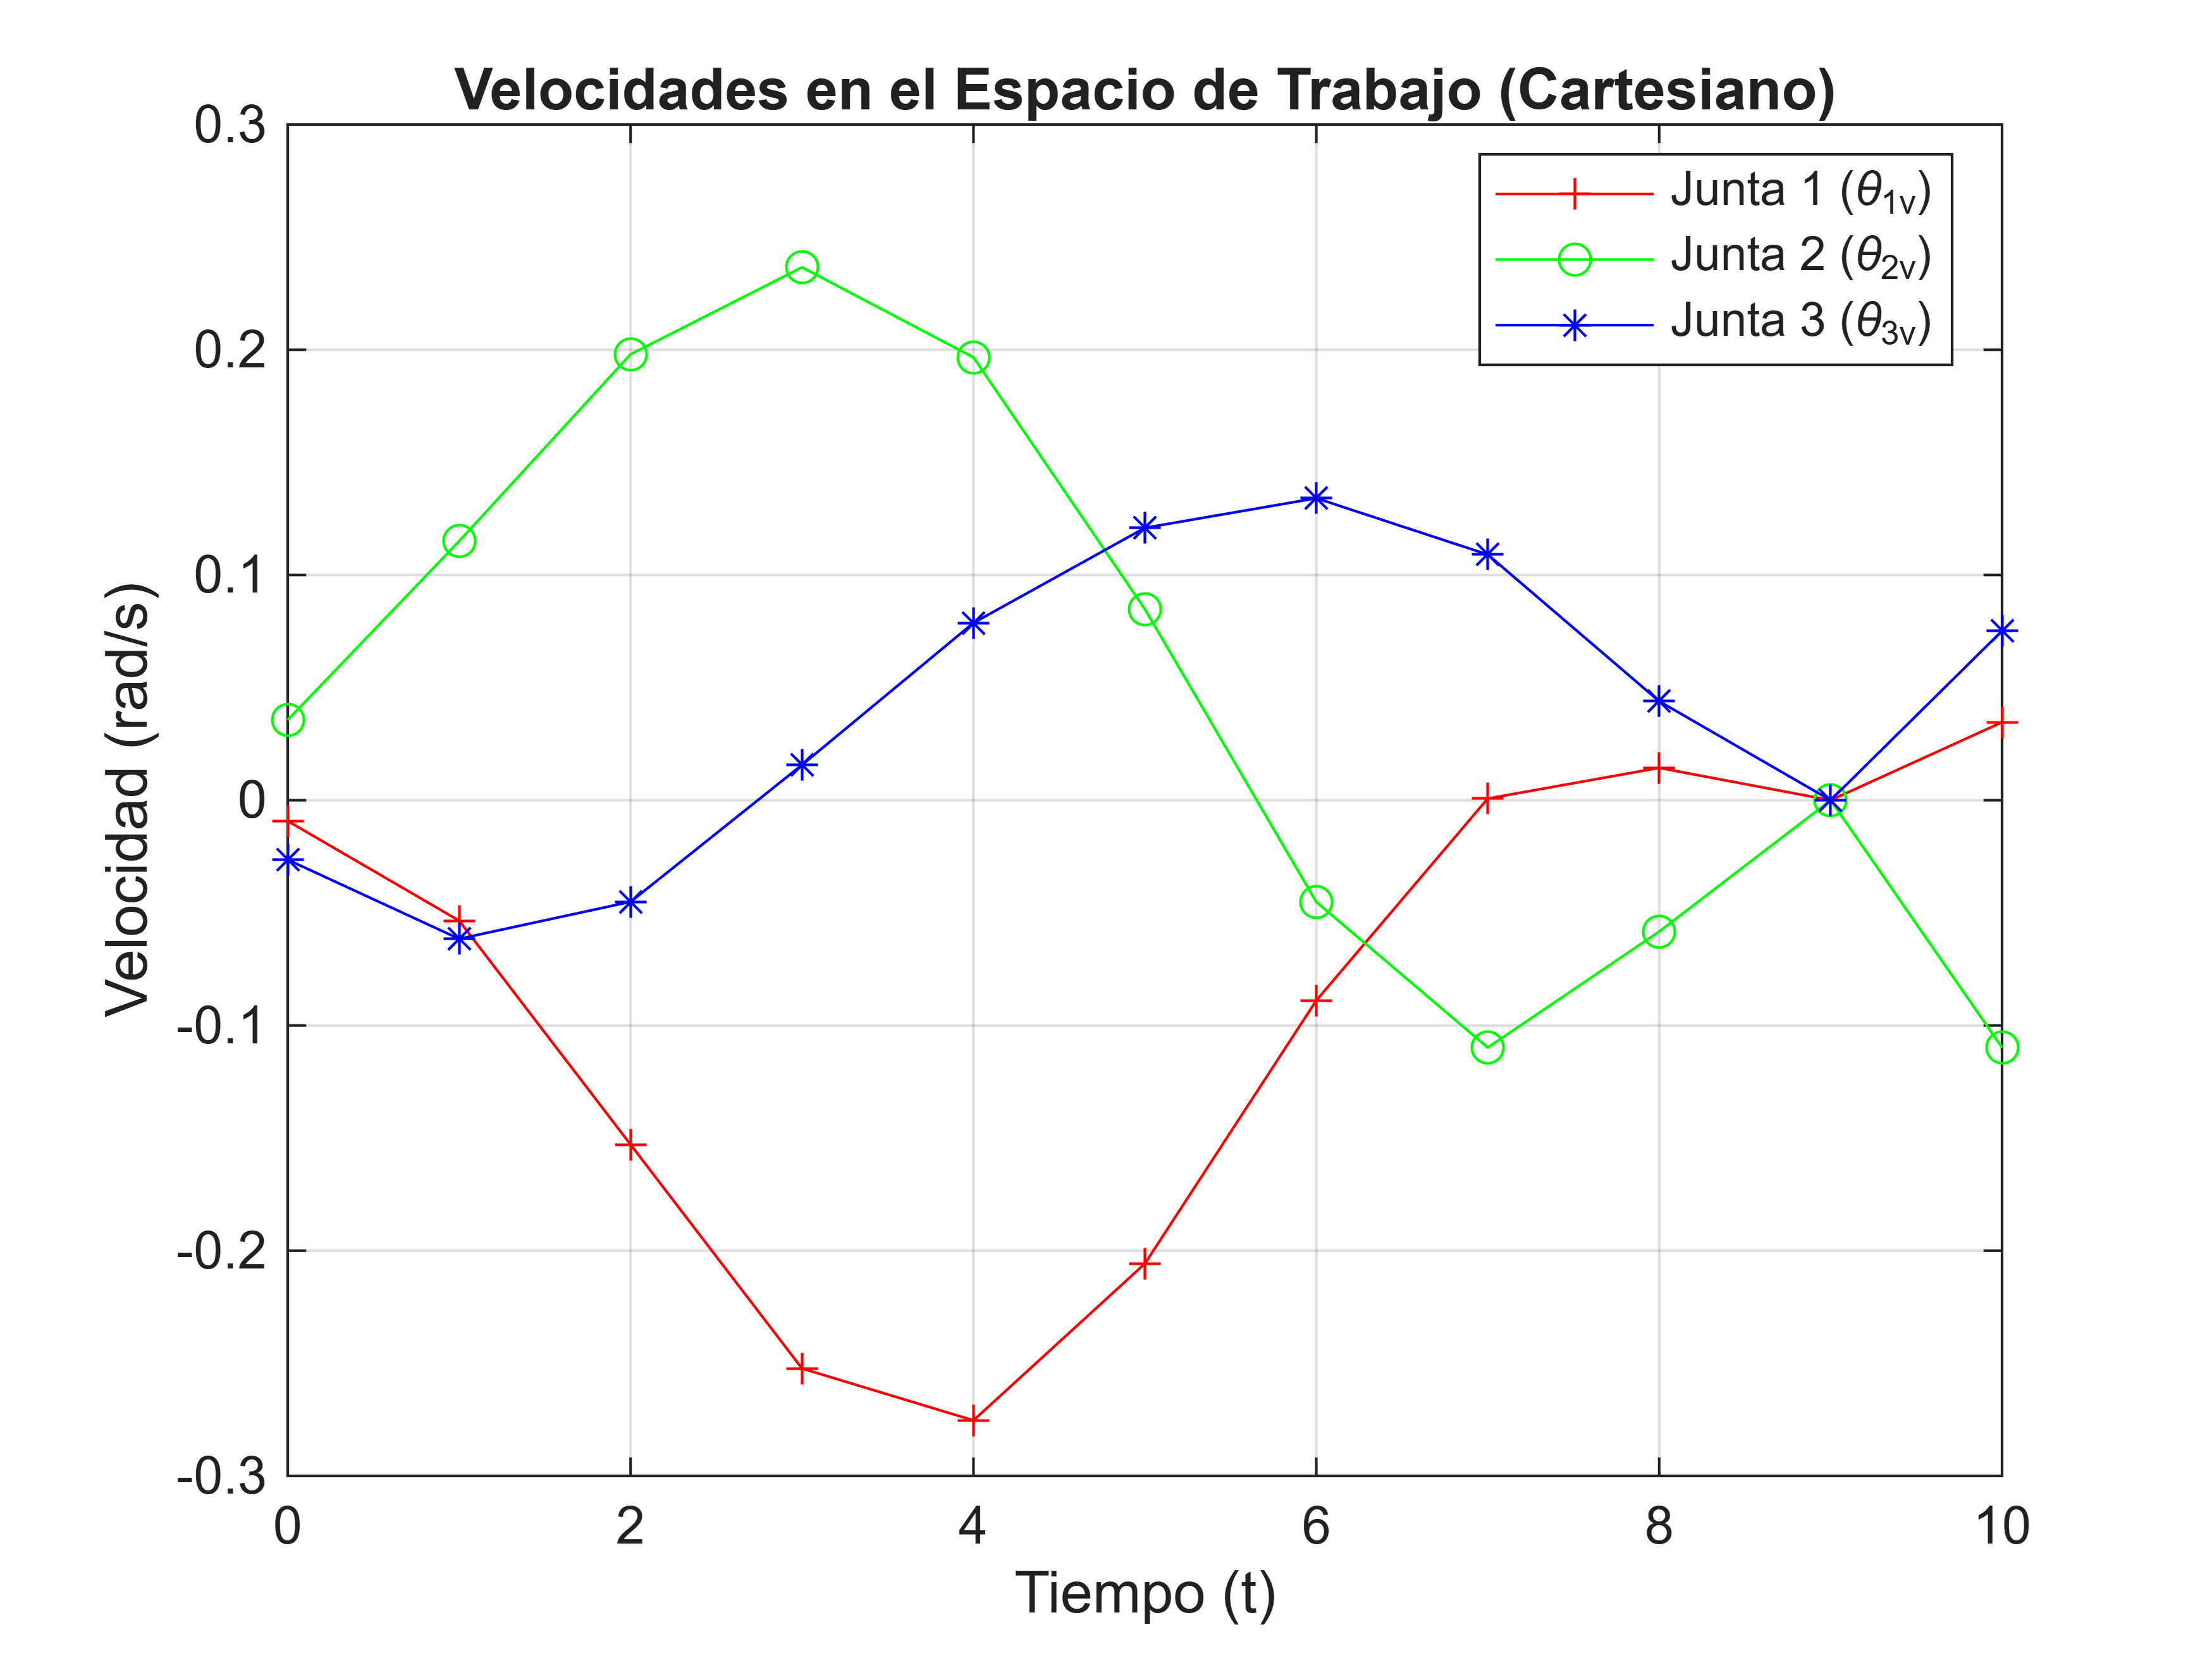

In [19]:
% Cálculo de la solución de la primer postura


% Definición de los parámetros del robot
L_1 = 0.5; % Longitud del primer eslabón
L_2 = 0.5; % Longitud del segundo eslabón
L_3 = 0.25; % Longitud del tercer eslabón


% x_in = 0.3;
% y_in = 0.3;
% theta_in = 0;


% x_fin = 0.3;
% y_fin = -0.3;
%theta_fin = pi/2;


tf = 10;
for i=1:tf+1
    t = i;
    x_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(x_fin-x_in);
    y_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(y_fin-y_in);
    theta_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_fin-theta_in);


    x_dot = x_P_v(i);
    y_dot = y_P_v(i);
    theta_dot_P = theta_P_v(i);

    theta_O_1 = theta_1_tray(i);
    theta_1_2 = theta_2_tray(i);
    theta_2_3 = theta_3_tray(i);


    theta_1_v(i) = (x_dot*cos(theta_1_2 + theta_O_1))/(L_1*sin(theta_1_2)) + (y_dot*sin(theta_1_2 + theta_O_1))/(L_1*sin(theta_1_2)) + (L_3*theta_dot_P*sin(theta_2_3))/(L_1*sin(theta_1_2));
    theta_2_v(i) = - (x_dot*(L_2*cos(theta_1_2 + theta_O_1) + L_1*cos(theta_O_1)))/(L_1*L_2*sin(theta_1_2)) - (y_dot*(L_2*sin(theta_1_2 + theta_O_1) + L_1*sin(theta_O_1)))/(L_1*L_2*sin(theta_1_2)) - (L_3*theta_dot_P*(L_1*sin(theta_1_2 + theta_2_3) + L_2*sin(theta_2_3)))/(L_1*L_2*sin(theta_1_2));
    theta_3_v(i) = (theta_dot_P*(L_3*sin(theta_1_2 + theta_2_3) + L_2*sin(theta_1_2)))/(L_2*sin(theta_1_2)) + (x_dot*cos(theta_O_1))/(L_2*sin(theta_1_2)) + (y_dot*sin(theta_O_1))/(L_2*sin(theta_1_2));



end


% Abre una nueva ventana para la gráfica de velocidades cartesianas
figure;


% Grafica la velocidad de la Junta 1 en color rojo con marcador '+'
plot(tsim, theta_1_v, 'r-+');
hold on;


% Grafica la velocidad de la Junta 2 en color verde con marcador 'o'
plot(tsim, theta_2_v, 'g-o');


% Grafica la velocidad de la Junta 3 en color azul con marcador '*'
plot(tsim, theta_3_v, 'b-*');


hold off;


% --- FORMATO Y ETIQUETAS ACADÉMICAS ---
title("Velocidades en el Espacio de Trabajo (Cartesiano)");
xlabel("Tiempo (t)");
ylabel("Velocidad (rad/s)");


% Configuración de las leyendas para identificar plenamente cada motor
legend('Junta 1 (\theta_1_v)', 'Junta 2 (\theta_2_v)', 'Junta 3 (\theta_3_v)', 'Location', 'best');


% Habilita la cuadrícula de fondo para facilitar la lectura de los valores
grid on;


### Análisis de la Gráfica de Velocidades Cartesianas

**1. Asimetría Dinámica Total**

A diferencia de la gráfica en el espacio articular (donde todas las curvas eran parábolas perfectas y simétricas), aquí las curvas son completamente asimétricas, onduladas y complejas.

*- Por qué ocurre:* Para que la punta del robot se desplace en una línea recta diagonal perfecta a velocidad controlada, los motores se ven obligados a acelerar y desacelerar de forma descompensada. La Junta 1 (roja) tiene que cambiar de dirección (baja a velocidad negativa y luego sube a positiva), mientras que la Junta 2 (verde) y la Junta 3 (azul) oscilan de forma senoidal adaptándose a la geometría del brazo.

**2. El Fenómeno de los Extremos (No cierran en cero)**

Si observas con atención los tiempos $t=0$ y $t=10$, notarás que las velocidades no comienzan ni terminan exactamente en cero (especialmente la Junta 2 y la Junta 3 en el segundo 10).

*- Por qué ocurre esto:* Al obligar al robot a llegar a la coordenada final $(0.8,0.8)$, el brazo queda extendido casi al $100\%$ de su capacidad. Como explicamos anteriormente, esto acerca al robot a una singularidad cinemática. Cerca de la singularidad, el determinante del Jacobiano se vuelve muy pequeño, lo que provoca que las ecuaciones exijan velocidades más altas a las juntas para poder mantener el rumbo sobre la línea recta. Esto causa que los motores tengan que seguir moviéndose bruscamente justo antes de detenerse.

## 6. Análisis de Manipulabilidad y Proximidad a Singularidades

Para evaluar la destreza del manipulador SCARA a lo largo de la trayectoria cartesiana, se implementa el cálculo del Índice de Manipulabilidad de Yoshikawa $~(w)$. Esta métrica cuantitativa se define matemáticamente como la raíz cuadrada del determinante del Jacobiano multiplicado por su transpuesta:

$$w=\sqrt{\det ({\mathbf{JJ}}^T )}$$

Para el plano de posicionamiento del robot SCARA, este índice se simplifica analíticamente a una función dependiente exclusiva de la apertura de la segunda articulación:

$$w(t)=L_1 L_2 |\sin (\theta_2 (t))|$$

El índice proporciona una medida del volumen del elipsoide de velocidad en el espacio operacional. Si el valor de $w\;$ tiende a cero $(w\to 0)$, significa que el robot se aproxima a una singularidad de frontera, una configuración crítica donde el manipulador pierde un grado de libertad y requiere velocidades articulares infinitas para producir un movimiento cartesiano finito. Por el contrario, el punto óptimo de destreza mecánica se alcanza cuando el codo se encuentra a un ángulo de $90^{\circ } \;\textrm{(}\theta_2 =\pi /2\textrm{)}$, maximizando el valor del índice y permitiendo al robot acelerar con el menor esfuerzo motriz en cualquier dirección cartesiana.



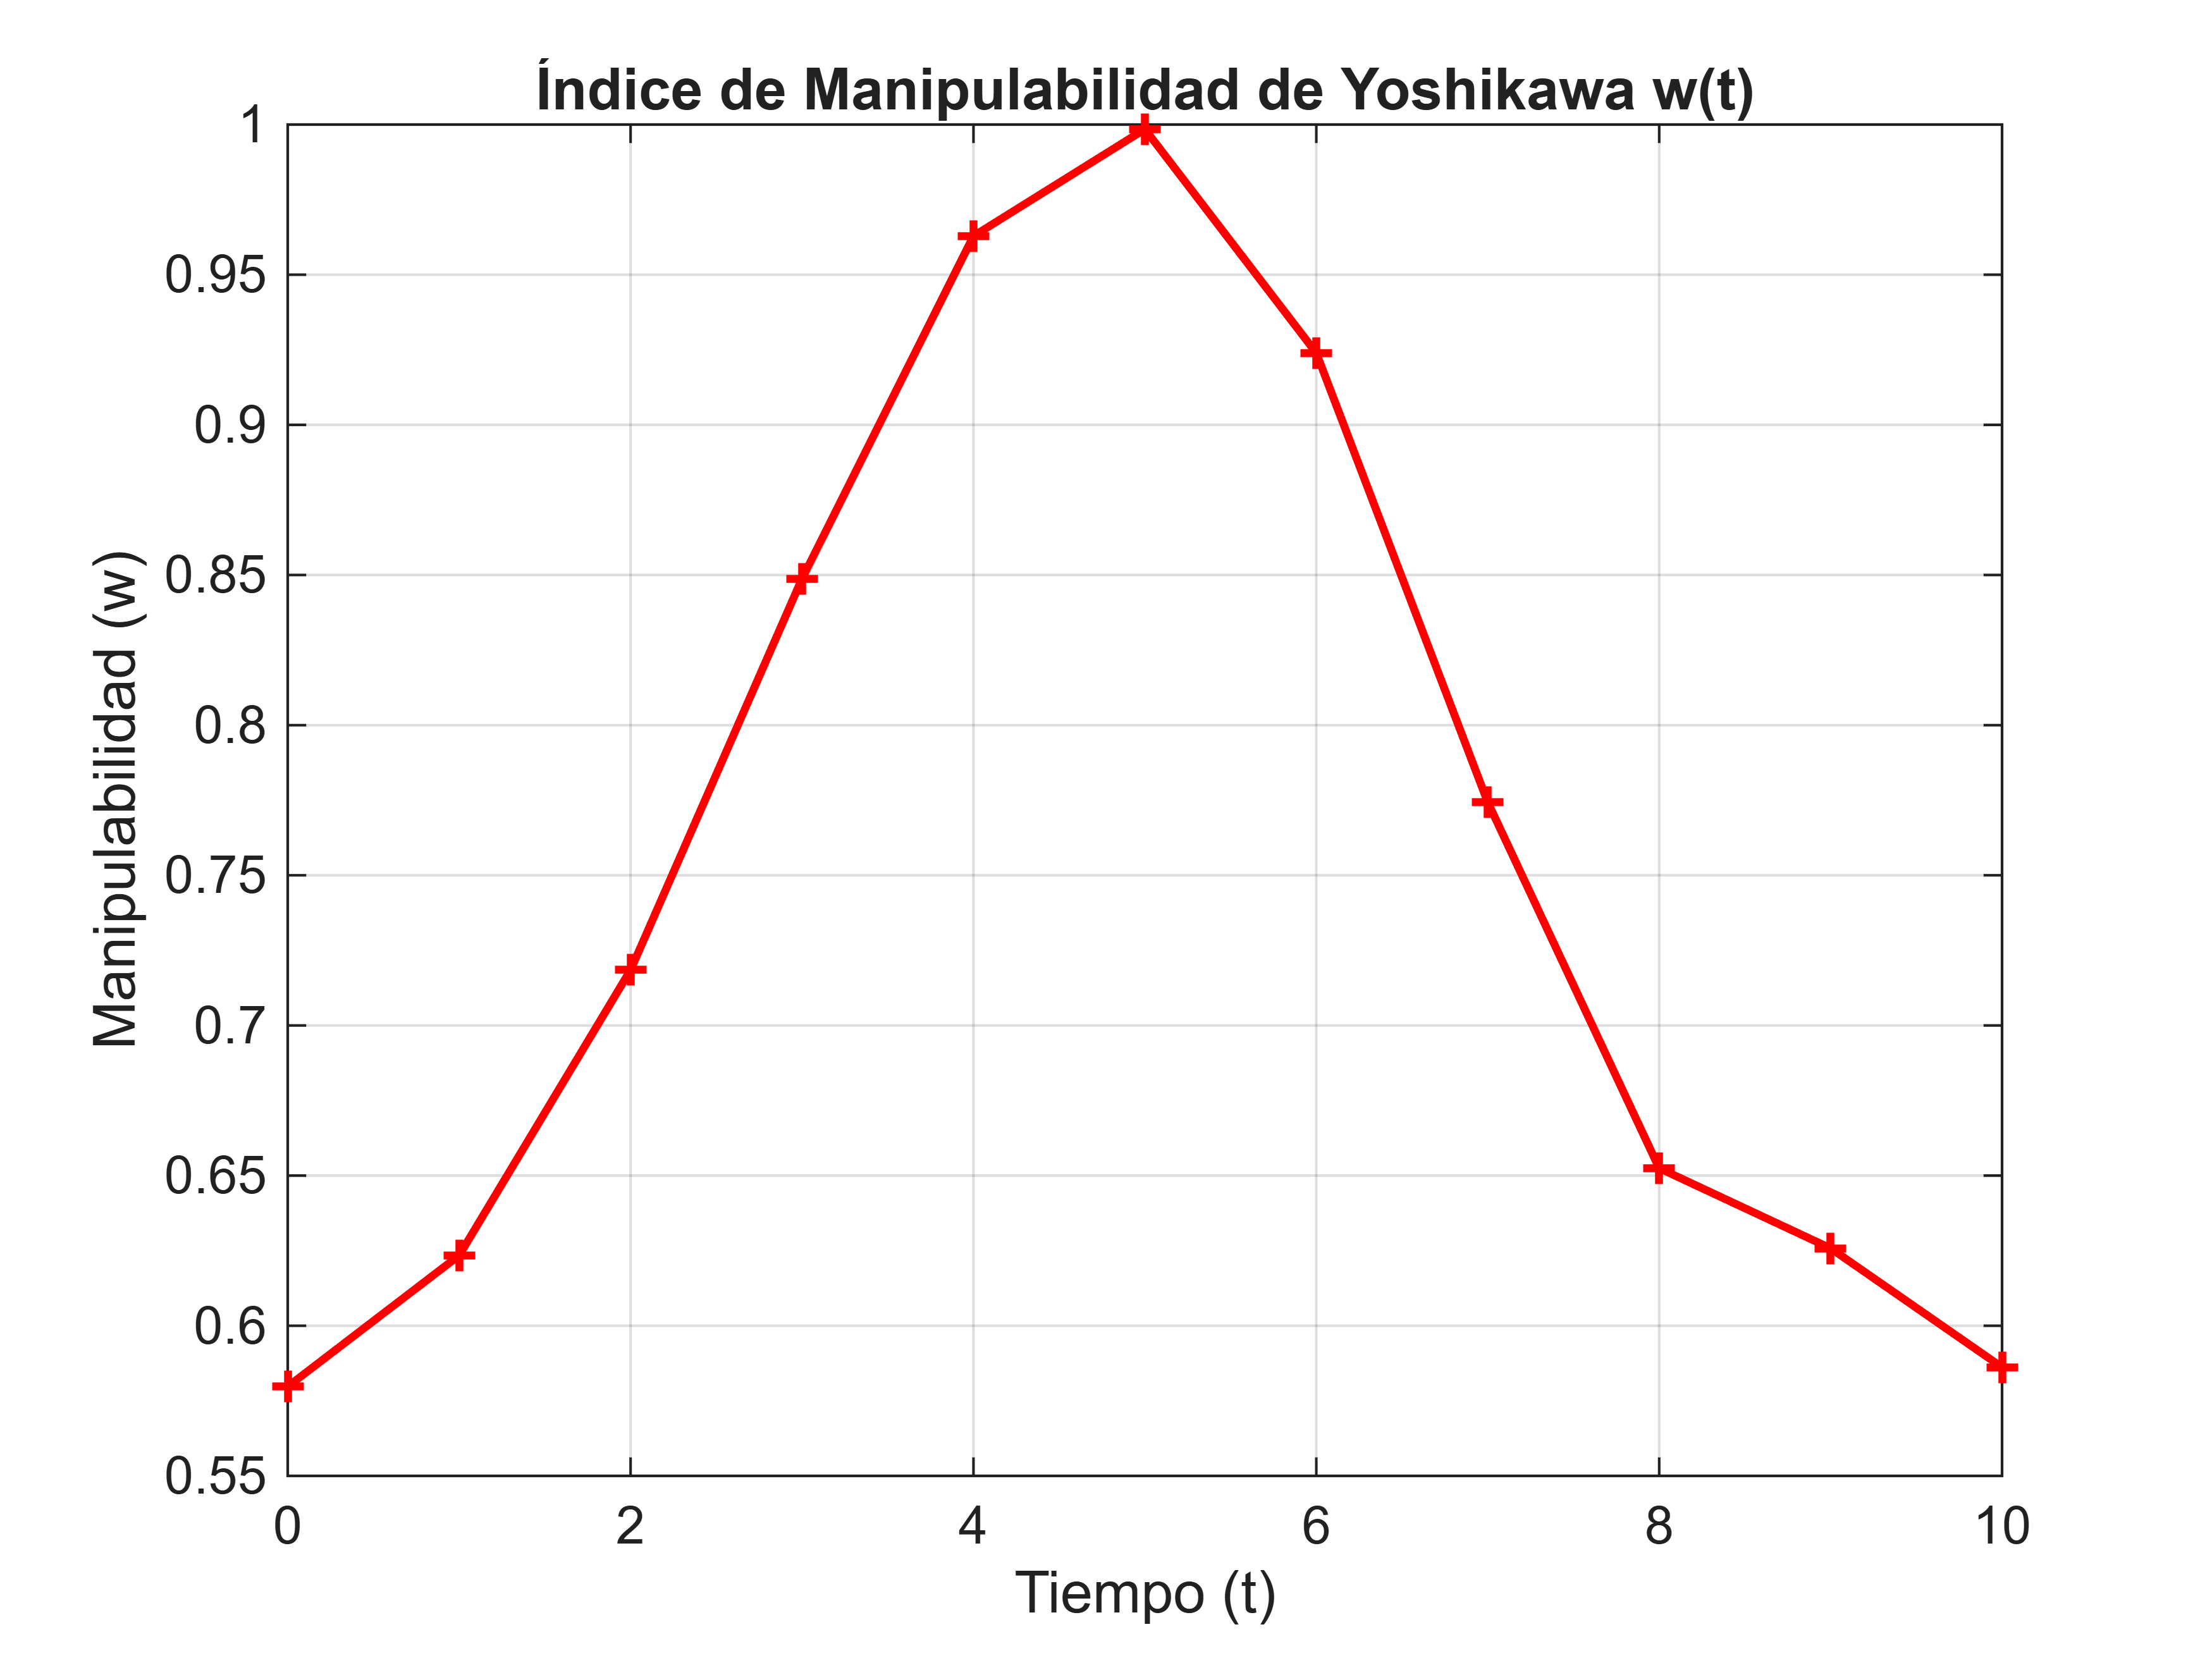

In [20]:
% =========================================================================
% CÁLCULO DEL ÍNDICE DE MANIPULABILIDAD DE YOSHIKAWA (w)
% =========================================================================


% Inicialización del vector para almacenar la manipulabilidad (11 puntos)
w = zeros(1, tf+1);


for i=1:tf+1
    % El índice w de Yoshikawa para un SCARA se reduce al seno del codo
    w(i) = sin(theta_2_tray(i));
end


% Generación de la gráfica de manipulabilidad
figure;
plot(tsim, w , 'r-+', 'LineWidth', 1.5);


% Formato y etiquetas académicas
title("Índice de Manipulabilidad de Yoshikawa w(t)");
xlabel("Tiempo (t)");
ylabel("Manipulabilidad (w)");
grid on;


### Análisis de la Gráfica de Manipulabilidad

**1. El Punto de Destreza Máxima $(t=5\;\textrm{s})$**

Se observa el pico más alto de la curva, el cual alcanza un valor de $w=1.0$ exactamente en el segundo 5 (mitad de la trayectoria).

*- Significado físico:* Como la fórmula simplificada para este robot es $w=\sin (\theta_2 )$, un índice de $1.0$ significa que en el segundo $5$, el codo del robot se encuentra exactamente a $90^{\circ } \;\textrm{(}\pi /2\;\textrm{rad)}$. Esta es la configuración óptima de diseño: en este punto, el robot tiene la máxima capacidad para acelerar con la menor corriente posible en cualquier dirección del plano cartesiano.

**2. Comportamiento en las Zonas Extremas $(t=0\;\textrm{s})~y~(t=10\;\textrm{s})$**

Tanto al inicio como al final, el índice cae a su punto más bajo, rondando un valor de $w\approx 0.58\textrm{.}$

*- Significado técnico:* Aunque el valor decrece, al mantenerse significativamente por encima de cero $(w>0)$, se demuestra cuantitativamente que el robot nunca entra en una singularidad de frontera. El brazo está muy estirado al final y recogido al principio, perdiendo destreza, pero conserva el rango matemático suficiente para operar de forma segura sin que el Jacobiano colapse por completo.

## 7. Evaluación de la capacidad del robot

### Implementación Numérica de la Dinámica Inversa y Consumo de Potencia

Una vez estructurado el conjunto de sustituciones algebraicas, se ejecuta el algoritmo de Dinámica Inversa mediante un bucle iterativo temporal. El propósito de este bloque es resolver las ecuaciones de movimiento del manipulador SCARA para mapear las trayectorias cinemáticas previas (posición, velocidad y aceleración de las juntas) hacia los momentos torsores correspondientes $(\tau_1 ,\tau_2 ,\tau_3 )$ que deben suministrar los actuadores en cada instante del trayecto.

Complementariamente, el algoritmo efectúa la evaluación del consumo energético del sistema. La potencia mecánica instantánea absorbida por cada articulación $j$ se calcula multiplicando la magnitud absoluta del torque por su respectiva velocidad angular $(P_j =|\tau_j \cdot {\dot{q} }_j |)$. Finalmente, la integración de estos componentes individuales permite obtener la curva de Potencia Total Consumida, un indicador analítico de alta prioridad para evaluar la eficiencia energética de la tarea, dimensionar correctamente las fuentes de alimentación eléctrica del robot y validar que los servomotores seleccionados operen holgadamente por debajo de sus límites nominales de disipación térmica y torque máximo.

 $$
\begin{array}{l} 
\ddot{\theta}_{O,1} \left(\frac{\cos(\theta_{1,2})}{4}+\frac{\sigma_{12}^2}{2}+\frac{\sigma_{14}^2}{2}+\frac{27}{8}\right) - \dot{\theta}_{2,3} \left(\frac{\sigma_{18} \sigma_{10}}{16}-\frac{\sigma_{16} \sigma_{11}}{16}+\frac{\sigma_{12} \sigma_4}{2}-\frac{\sigma_5 \sigma_{14}}{2}\right) + \ddot{\theta}_{1,2} \sigma_3 + \ddot{\theta}_{2,3} \sigma_6 - \dot{\theta}_{1,2} \left(\sigma_8 -\frac{\sigma_{14} \sigma_2}{2}+\frac{\sigma_1 \sigma_{12}}{2}-\sigma_9 +\frac{\dot{\theta}_{1,2} \sin(\theta_{1,2})}{8}+\frac{\dot{\theta}_{O,1} \sin(\theta_{1,2})}{4}\right) \\
\hline
\frac{\dot{\theta}_{O,1}^2 \sin(\theta_{1,2})}{8} - \dot{\theta}_{2,3} \left(\frac{\sigma_{18} \sigma_{10}}{16}-\frac{\left(\frac{\sigma_{18} / 8} + \sigma_{19}\right) \sigma_5}{2}+\frac{\left(\frac{\sigma_{16} / 8} + \sigma_{17}\right) \sigma_4}{2}-\frac{\sigma_{16} \sigma_{11}}{16}\right) + \ddot{\theta}_{2,3} \sigma_7 + \frac{\sigma_{10} \sigma_1}{2} + \ddot{\theta}_{O,1} \sigma_3 - \frac{\sigma_{11} \sigma_2}{2} + \ddot{\theta}_{1,2} \left(\frac{\left(\frac{\sigma_{16} / 8} + \sigma_{17}\right)^2}{2}+\frac{\left(\frac{\sigma_{18} / 8} + \sigma_{19}\right)^2}{2}+\frac{33}{16}\right) - \dot{\theta}_{1,2} \left(\frac{\left(\frac{\sigma_{16} / 8} + \sigma_{17}\right) \sigma_1}{2}-\frac{\left(\frac{\sigma_{18} / 8} + \sigma_{19}\right) \sigma_2}{2}+\sigma_8 -\sigma_9 +\frac{\dot{\theta}_{O,1} \sin(\theta_{1,2})}{8}\right) + \frac{\dot{\theta}_{1,2} \dot{\theta}_{O,1} \sin(\theta_{1,2})}{8} \\
\hline
\ddot{\theta}_{2,3} \left(\frac{\sigma_{16}^2}{128}+\frac{\sigma_{18}^2}{128}+1\right) - \frac{\sigma_5 \sigma_{11}}{2} + \ddot{\theta}_{1,2} \sigma_7 - \dot{\theta}_{2,3} \left(\frac{\sigma_{18} \sigma_{10}}{16}-\frac{\sigma_{18} \sigma_5}{16}-\frac{\sigma_{16} \sigma_{11}}{16}+\frac{\sigma_{16} \sigma_4}{16}\right) + \dot{\theta}_{1,2} \left(\frac{\sigma_{18} \sigma_2}{16}-\frac{\sigma_{18} \sigma_{10}}{16}-\frac{\sigma_{16} \sigma_1}{16}+\frac{\sigma_{16} \sigma_{11}}{16}\right) + \ddot{\theta}_{O,1} \sigma_6 + \frac{\sigma_{10} \sigma_4}{2} 
\end{array}
$$

$$
\begin{array}{l}
\text{Donde:} \\
\sigma_1 = \frac{\dot{\theta}_{2,3} \sigma_{18}}{8} + \sigma_{15} + \dot{\theta}_{O,1} \left( \frac{\sigma_{18}}{8} + \sigma_{19} \right) \\
\sigma_2 = \sigma_{13} + \dot{\theta}_{O,1} \left( \frac{\sigma_{16}}{8} + \sigma_{17} \right) + \frac{\dot{\theta}_{2,3} \sigma_{16}}{8} \\
\sigma_3 = \frac{\cos(\theta_{1,2})}{8} + \frac{\left( \frac{\sigma_{16}}{8} + \sigma_{17} \right) \sigma_{12}}{2} + \frac{\left( \frac{\sigma_{18}}{8} + \sigma_{19} \right) \sigma_{14}}{2} + \frac{33}{16} \\
\sigma_4 = \frac{\dot{\theta}_{1,2} \sigma_{18}}{8} + \frac{\dot{\theta}_{2,3} \sigma_{18}}{8} + \frac{\dot{\theta}_{O,1} \sigma_{18}}{8} \\
\sigma_5 = \frac{\dot{\theta}_{1,2} \sigma_{16}}{8} + \frac{\dot{\theta}_{2,3} \sigma_{16}}{8} + \frac{\dot{\theta}_{O,1} \sigma_{16}}{8} \\
\sigma_6 = \frac{\sigma_{16} \sigma_{12}}{16} + \frac{\sigma_{18} \sigma_{14}}{16} + 1 \\
\sigma_7 = \frac{\sigma_{16} \left( \frac{\sigma_{16}}{8} + \sigma_{17} \right)}{16} + \frac{\sigma_{18} \left( \frac{\sigma_{18}}{8} + \sigma_{19} \right)}{16} + 1 \\
\sigma_8 = \frac{\left( \frac{\sigma_{18}}{8} + \sigma_{19} \right) \sigma_{10}}{2} \\
\sigma_9 = \frac{\left( \frac{\sigma_{16}}{8} + \sigma_{17} \right) \sigma_{11}}{2} \\
\sigma_{10} = \sigma_{13} + \frac{\dot{\theta}_{2,3} \sigma_{16}}{8} + \dot{\theta}_{O,1} \sigma_{12} \\
\sigma_{11} = \frac{\dot{\theta}_{2,3} \sigma_{18}}{8} + \dot{\theta}_{O,1} \sigma_{14} + \sigma_{15} \\
\sigma_{12} = \frac{\sigma_{16}}{8} + \sigma_{17} + \frac{\cos(\theta_{O,1})}{2} \\
\sigma_{13} = \dot{\theta}_{1,2} \left( \frac{\sigma_{16}}{8} + \sigma_{17} \right) \\
\sigma_{14} = \frac{\sigma_{18}}{8} + \sigma_{19} + \frac{\sin(\theta_{O,1})}{2} \\
\sigma_{15} = \dot{\theta}_{1,2} \left( \frac{\sigma_{18}}{8} + \sigma_{19} \right) \\
\sigma_{16} = \cos(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) \\
\sigma_{17} = \frac{\cos(\theta_{1,2} + \theta_{O,1})}{2} \\
\sigma_{18} = \sin(\theta_{1,2} + \theta_{2,3} + \theta_{O,1}) \\
\sigma_{19} = \frac{\sin(\theta_{1,2} + \theta_{O,1})}{2}
\end{array}
$$



In [ ]:
% Cálculo de los pares del robot


for i=1:tf+1

    theta_1 = theta_1_P(i);
    theta_2 = theta_2_P(i);
    theta_3 = theta_3_P(i);


    theta_1_vc = theta_1_P_v(i);
    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);


    theta_1_a = theta_1_P_a(i);
    theta_2_a = theta_2_P_a(i);
    theta_3_a = theta_3_P_a(i);


    sigma_19 = sin(theta_2+theta_1)/2;
    sigma_18 = sin(theta_1+theta_2+theta_3);
    sigma_17 = cos(theta_2+theta_1)/2;
    sigma_16 = cos(theta_1+theta_2+theta_3);


    sigma_15 = theta_2_vc*(sigma_18/8 + sigma_19);
    sigma_14 = sigma_18/8 + sigma_19 + sin(theta_1)/2;
    sigma_13 = theta_2_vc *(sigma_16/8 +sigma_17);
    sigma_12 = sigma_16/8 +sigma_17 +cos(theta_1)/2;
    sigma_11 = theta_3_vc*sigma_18/8 + theta_1_vc*sigma_14 +sigma_15;
    sigma_10 = sigma_13 + theta_3_vc*sigma_16/8 +theta_1_vc*sigma_12;
    sigma_9 = ((sigma_16/8 + sigma_17)*sigma_11)/2;
    sigma_8 = ((sigma_18/8 + sigma_19)*sigma_10)/2;
    sigma_7 = (sigma_16*(sigma_16/8 + sigma_17))/16 + (sigma_18*(sigma_18/8 + sigma_19))/16 + 1;
    sigma_6 = sigma_16*sigma_12/16 + sigma_18*sigma_14 + 1;
    sigma_5 = theta_2_vc*sigma_16/8 + theta_3_vc*sigma_16/8 + theta_1_vc*sigma_16/8;
    sigma_4 = theta_2_vc*sigma_18/8 + theta_3_vc*sigma_18/8 + theta_1_vc*sigma_18/8;
    sigma_3 = cos(theta_2)/8 + ((sigma_16/8 + sigma_17)*sigma_12)/2 + ((sigma_18/8 + sigma_19)*sigma_14)/2 + 33/16;
    sigma_2 = sigma_13 +theta_1_vc*(sigma_16/8 + sigma_17) + theta_3_vc*sigma_16/8;
    sigma_1 = theta_3_vc*sigma_18/8 + sigma_15 +theta_1_vc*(sigma_18/8 + sigma_19);


    tao_1_c(i) = theta_1_a*(cos(theta_2)/4 + sigma_12^2/2 + sigma_14^2/2 + 27/8) - theta_3_vc* (sigma_18*sigma_10/16 - sigma_16*sigma_11/16 + sigma_12*sigma_4/2 - sigma_5*sigma_14/2) + theta_2_a*sigma_3 + theta_3_a*sigma_6 - theta_2_vc*(sigma_8 - sigma_14*sigma_2/2 + sigma_1*sigma_12/2 - sigma_9 + theta_2_vc*sin(theta_2)/8 + theta_1_vc*sin(theta_2)/4);
    tao_2_c(i) = theta_1_vc^2*sin(theta_2)/8 - theta_3_vc*(sigma_18*sigma_10 - ((sigma_18/8 + sigma_19)*sigma_5)/2 + ((sigma_16/8 + sigma_17)*sigma_4)/2 - sigma_16*sigma_11/16) + theta_2_a*sigma_7 + sigma_10*sigma_1/2 + theta_1_a*sigma_3 - sigma_11*sigma_2/2 + theta_2_a*(((sigma_16 + sigma_17)^2)/2 + ((sigma_18 + sigma_19)^2)/2 + 33/16) - theta_2_vc*((sigma_16/8 + sigma_17)*sigma_1/2 + (sigma_18/8 + sigma_19)*sigma_2/2 + sigma_8 - sigma_9 + theta_1_vc*sin(theta_2)/8) + theta_2_vc*theta_1_vc*sin(theta_2)/8;
    tao_3_c(i) = theta_3_a*(sigma_16^2/128 + sigma_18^2/128 + 1 ) - sigma_5*sigma_11/2 + theta_2_a*sigma_7 - theta_3_vc*(sigma_18*sigma_10/16 - sigma_18*sigma_5/16 - sigma_16*sigma_11/16 + sigma_16*sigma_4/16) + theta_2_vc*(sigma_18*sigma_2/16 - sigma_18*sigma_10/16 - sigma_16*sigma_1/16 + sigma_16*sigma_11/16) + theta_1_a*sigma_6 + sigma_10*sigma_4/2;


    pot_1(i) = abs(tao_1_c(i)*theta_1_vc);
    pot_2(i) = abs(tao_2_c(i)*theta_2_vc);
    pot_3(i) = abs(tao_3_c(i)*theta_3_vc);
    pot_total(i) = pot_1(i) + pot_2(i) + pot_3(i);



end




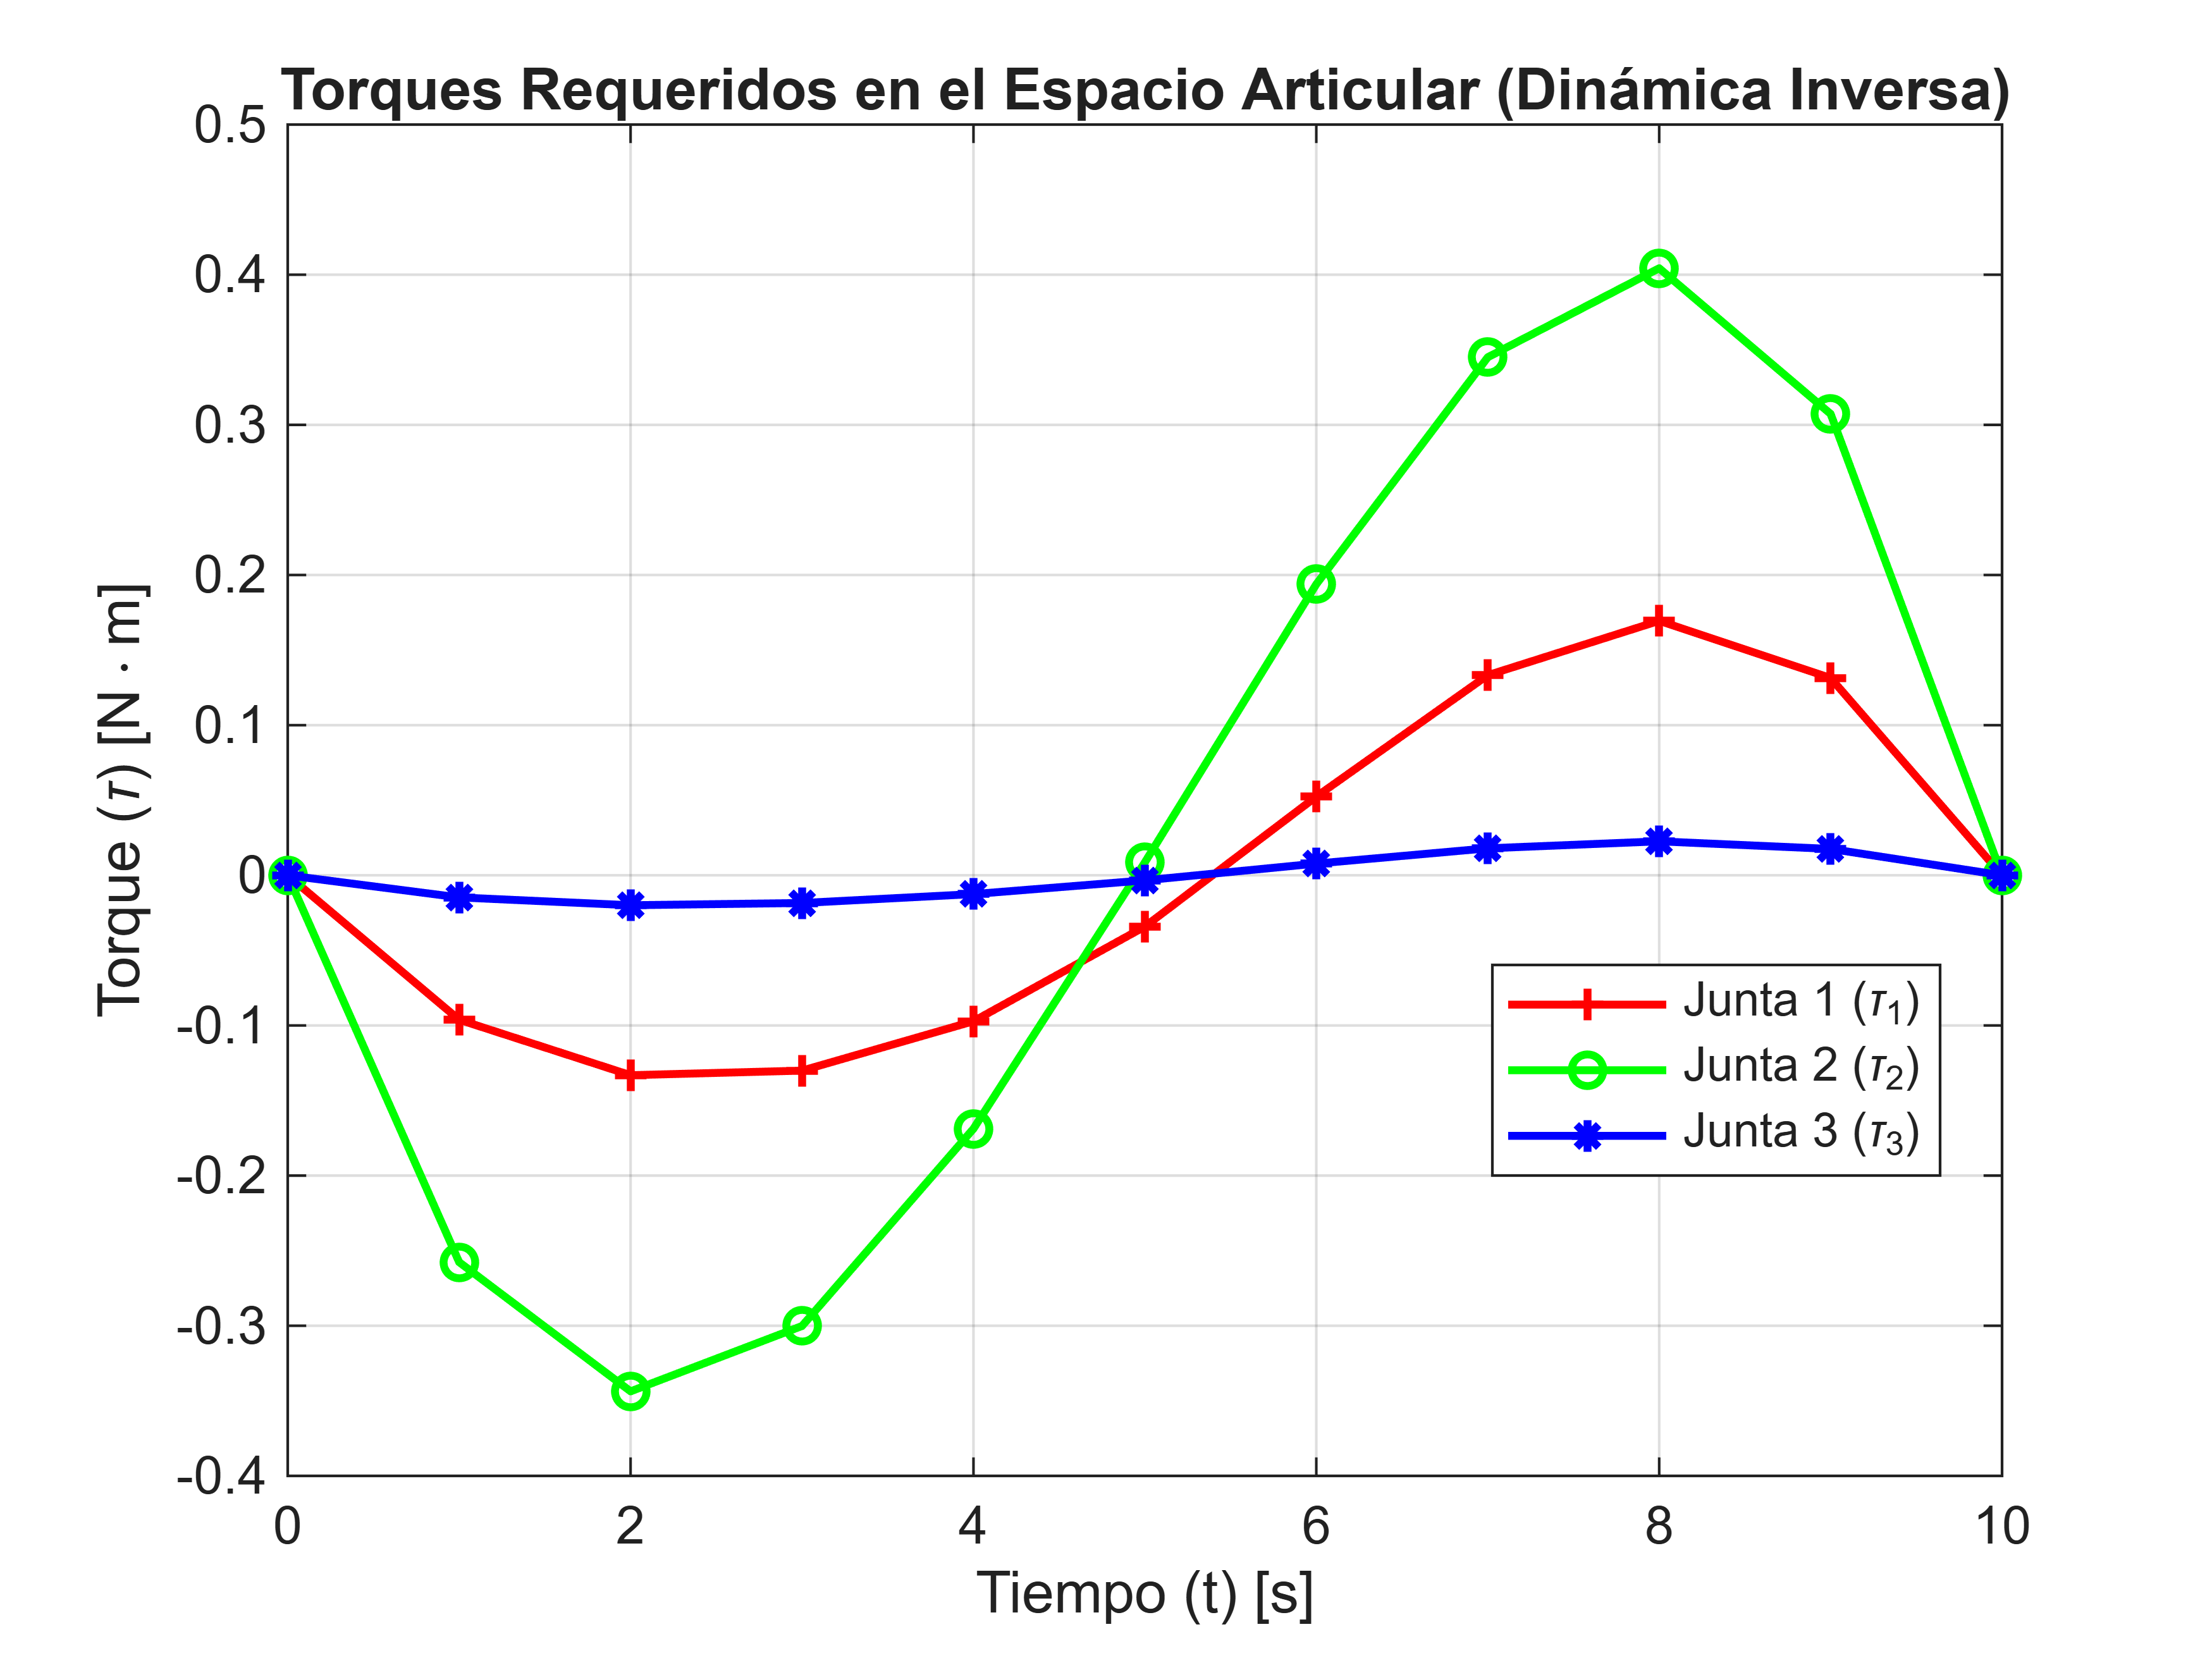

In [22]:
% Abre una nueva ventana para la gráfica de torques dinámicos
figure;


% Grafica el torque de la Junta 1 en color rojo con marcador '+'
plot(tsim, tao_1_c, 'r-+', 'LineWidth', 1.5);
hold on;


% Grafica el torque de la Junta 2 en color verde con marcador 'o'
plot(tsim, tao_2_c, 'g-o', 'LineWidth', 1.5);


% Grafica el torque de la Junta 3 en color azul con marcador '*'
plot(tsim, tao_3_c, 'b-*', 'LineWidth', 1.5);


hold off;


% --- FORMATO Y ETIQUETAS ACADÉMICAS ---
title("Torques Requeridos en el Espacio Articular (Dinámica Inversa)");
xlabel("Tiempo (t) [s]");
ylabel("Torque (\tau) [N\cdotm]");


% Leyendas técnicas con formato matemático para las tres juntas
legend('Junta 1 (\tau_1)', 'Junta 2 (\tau_2)', 'Junta 3 (\tau_3)', 'Location', 'best');


% Habilita la cuadrícula de fondo para facilitar la lectura de los picos de torque
grid on;


### Análisis de la Gráfica de Torques Dinámicos

**1. Inercia Pura y Condiciones de Frontera**

Se observa que en los segundos $t=0\;\textrm{y}\;t=10$, los tres torques son exactamente $0\;\textrm{N}\cdot \textrm{m}\textrm{.}$

*- Significado físico:* Debido a que el plano del robot SCARA es completamente horizontal, los motores no tienen que vencer la fuerza de gravedad para sostener el brazo (a diferencia de un brazo articulado vertical). Por lo tanto, los torques dependen exclusivamente de la inercia, aceleraciones y fuerzas centrífugas. Al iniciar y terminar con aceleración cero, el torque estático residual es nulo.

**2. Sincronía con la Gráfica de Aceleraciones**

Si se compara esta gráfica con el perfil anterior de aceleraciones articulares, se notará que las curvas tienen exactamente la misma forma de onda antisimétrica (tipo senoidal):

*- Segundos $0~a~5$ (Fase de Aceleración):* Los torques son negativos. Los motores ejercen fuerza en sentido horario para sacar al robot del reposo y acelerarlo. El pico de torque máximo negativo ocurre en el segundo $(t=2\;\textrm{s}).$

*- Segundos $5~a~10$ (Fase de Frenado):* Los torques cambian bruscamente de signo y se vuelven positivos. Los motores actúan como un freno dinámico en sentido antihorario para desacelerar la masa del brazo antes de llegar al objetivo. El pico máximo positivo ocurre en el segundo $t=8\;\textrm{s}\textrm{.}$

**3. Distribución del Esfuerzo Mecánico**

*- Junta 2 (Verde):* Es la que realiza por mucho el esfuerzo más severo. Alcanza un pico de torque de $\approx \pm 0.35-0.40\;\textrm{N}\cdot \textrm{m}$. Esto es físicamente lógico, ya que al abrir y cerrar el codo de forma polinomial, este motor arrastra directamente la masa del eslabón 2 y toda la estructura de la muñeca.

*- Junta 1 (Roja):* Exige un torque intermedio de $\approx \pm 0.15\;\textrm{N}\cdot \textrm{m}$. Aunque carga con todo el peso del robot, su desplazamiento angular total en esta trayectoria fue muy pequeño, por lo que la inercia angular efectiva es menor.

*- Junta 3 (Azul):* Su torque es prácticamente despreciable (cercano a cero en todo el viaje). La muñeca solo carga con la herramienta final y se limita a rotar sobre su propio centro de masa, demandando un torque mínimo.



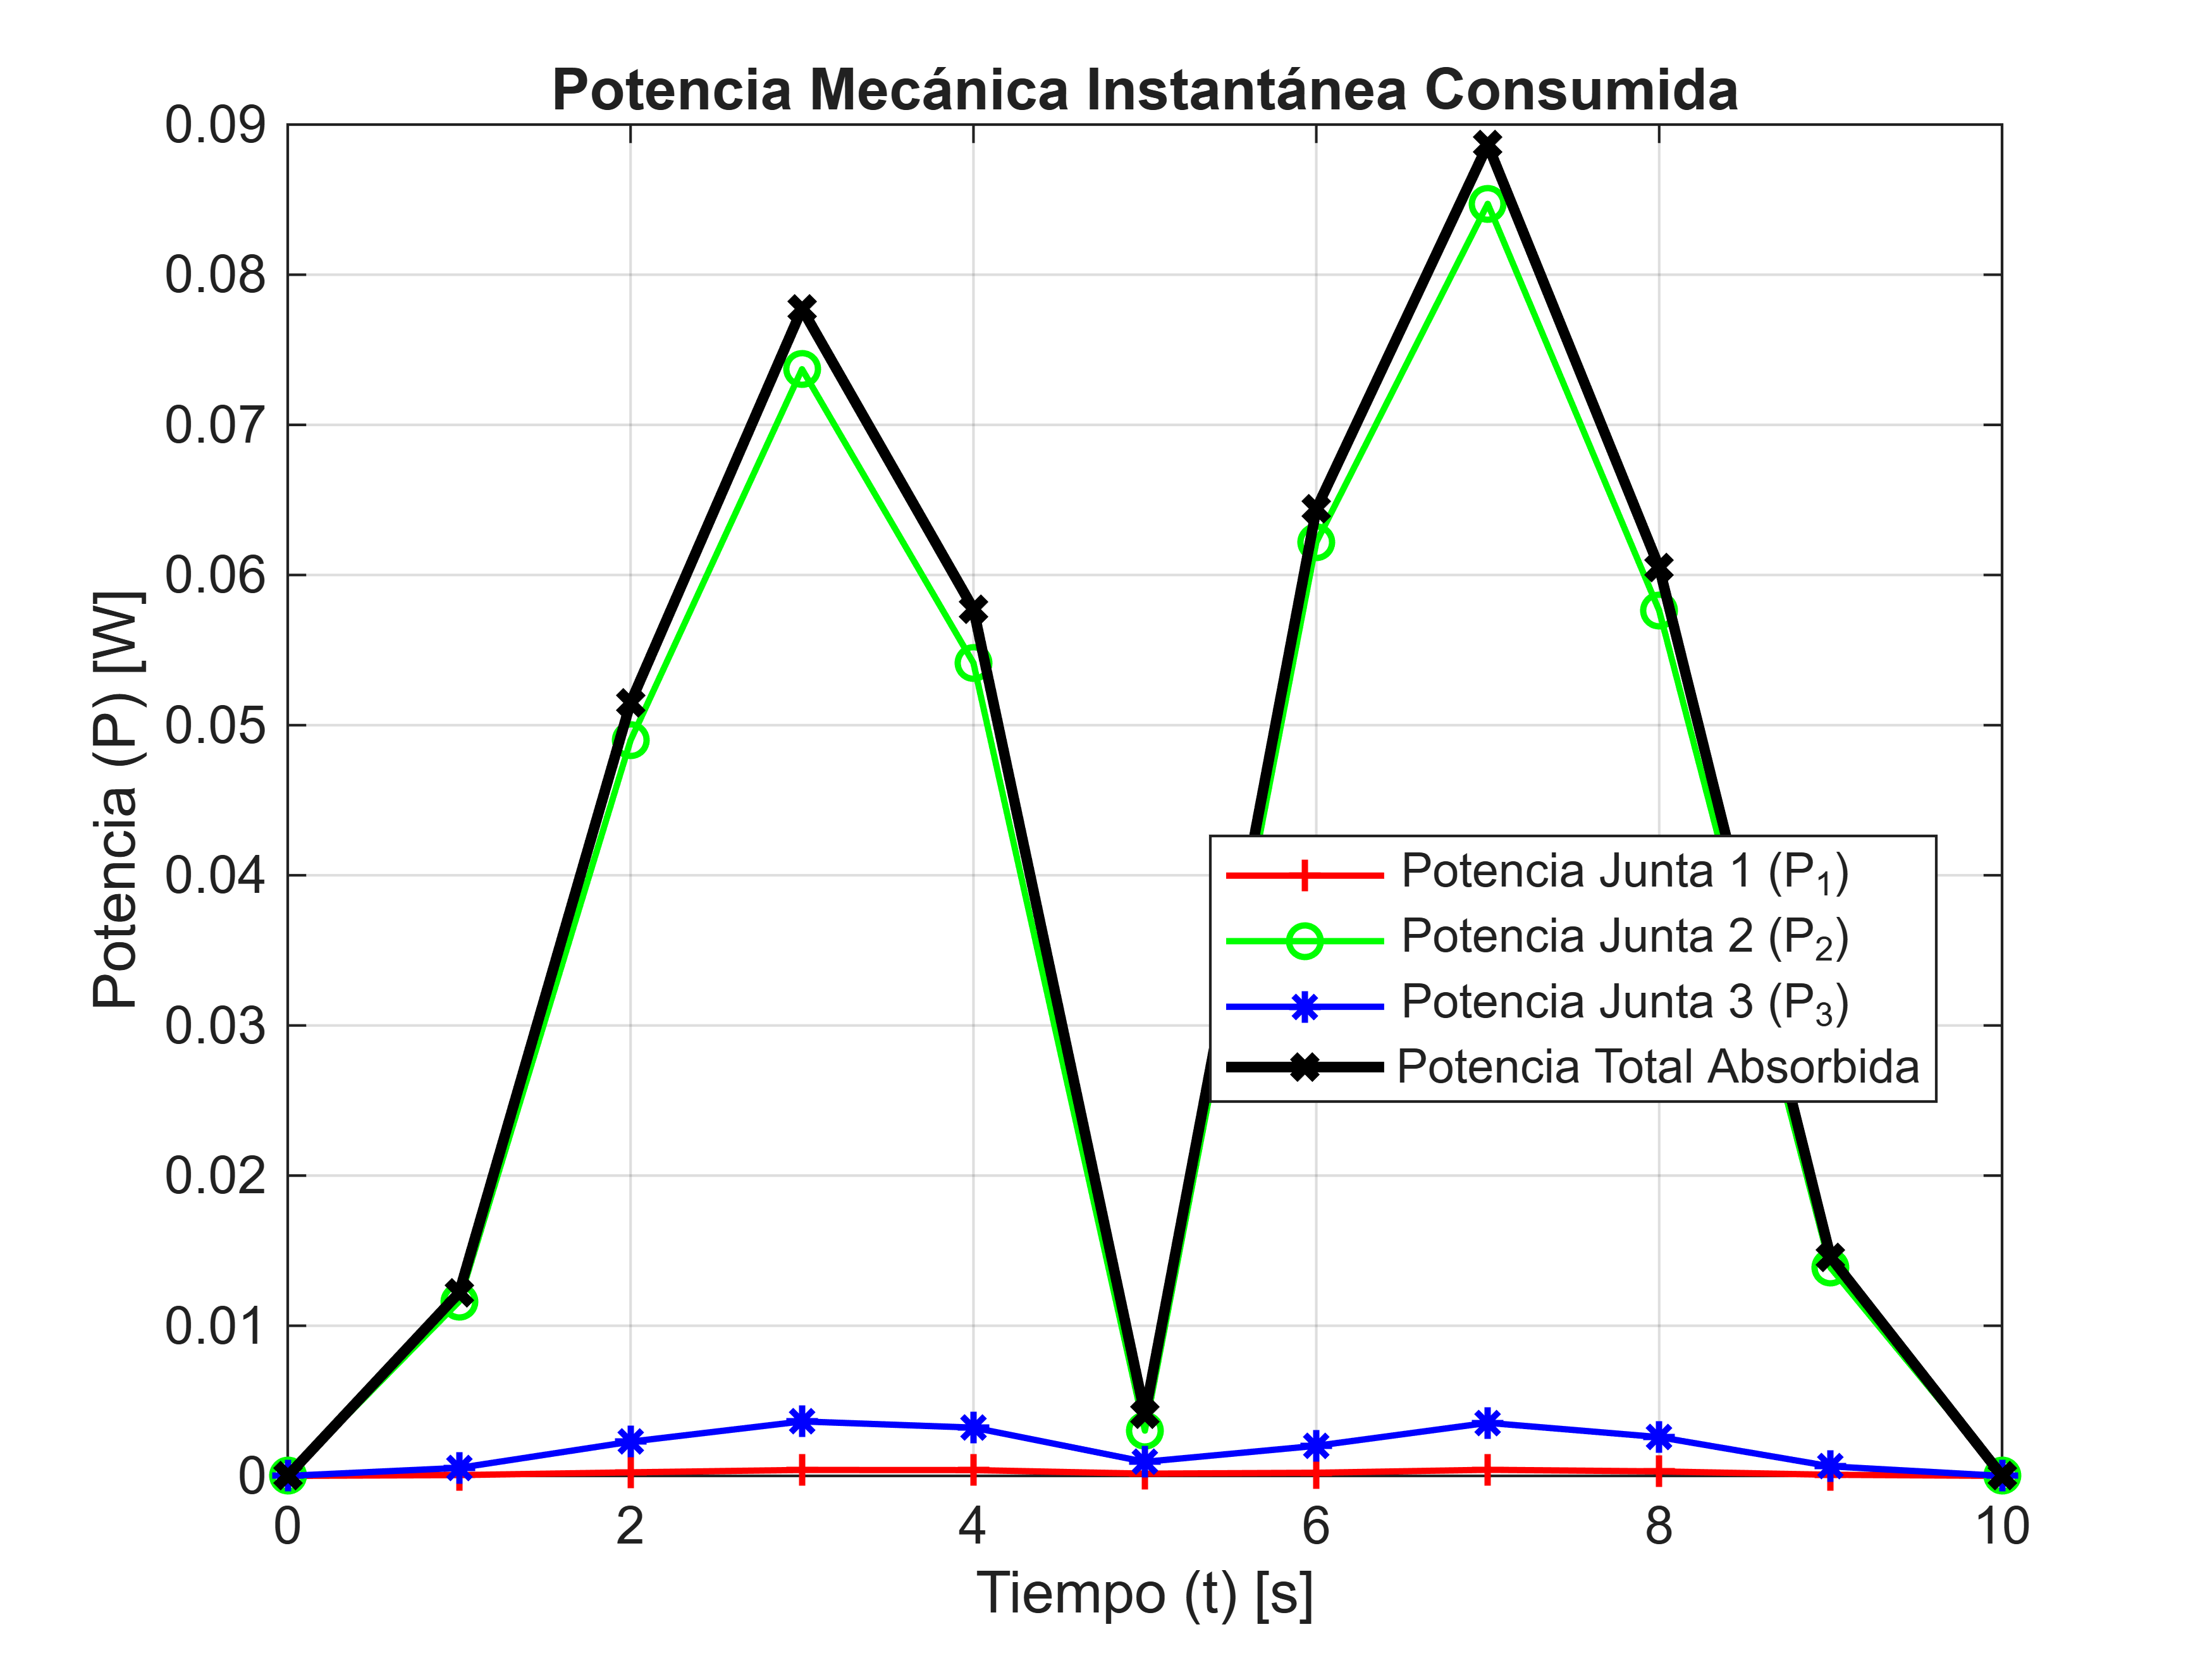

In [23]:
% Abre una nueva ventana para la gráfica de potencias mecánicas
figure;


% Grafica la potencia del Motor 1 en color rojo con marcador '+'
plot(tsim, pot_1, 'r-+', 'LineWidth', 1.2);
hold on;


% Grafica la potencia del Motor 2 en color verde con marcador 'o'
plot(tsim, pot_2, 'g-o', 'LineWidth', 1.2);


% Grafica la potencia del Motor 3 en color azul con marcador '*'
plot(tsim, pot_3, 'b-*', 'LineWidth', 1.2);


% Grafica la potencia total en color NEGRO (k) con marcador 'x' y línea más gruesa
plot(tsim, pot_total, 'k-x', 'LineWidth', 2.0);


hold off;


% --- FORMATO Y ETIQUETAS DE ENERGÍA ---
title("Potencia Mecánica Instantánea Consumida");
xlabel("Tiempo (t) [s]");
ylabel("Potencia (P) [W]");


% Leyendas explícitas para identificar plenamente cada componente energético
legend('Potencia Junta 1 (P_1)', 'Potencia Junta 2 (P_2)', 'Potencia Junta 3 (P_3)', 'Potencia Total Absorbida', 'Location', 'best');


% Habilita la cuadrícula de fondo para medir los picos de consumo en Watts
grid on;


### Análisis de la Gráfica de Potencias

**1. El Comportamiento en M**

A diferencia de los torques que tenían valores positivos y negativos, la potencia mecánica absoluta $(P=|\tau \cdot \dot{\theta} |)$ es siempre positiva, lo que genera una característica silueta en forma de "M" o doble joroba.

**2. Explicación de los Tres Valles Críticos (Puntos Cero)**

La potencia total cae exactamente a 0 Watts en tres instantes clave de la trayectoria:

*- $t=0\;\textrm{s}\;\textrm{y}\;t=10\;\textrm{s}\textrm{:}$* Porque el robot está estático en el origen y destino. La velocidad de las juntas es cero.

*- $t=5\;\textrm{s}$ (Mitad del tiempo):* Este es un fenómeno dinámico muy interesante. En el segundo 5, los motores alcanzan su velocidad máxima, lo que significa que dejas de acelerar y entras en una velocidad constante instantánea. Al no requerir aceleración en ese microsegundo, el torque cae a cero, y por ende, la potencia consumida también se anula momentáneamente.

**3. Asimetría de los Picos de Consumo**

Se nota que el primer pico (en el segundo 3) alcanza aproximadamente $0.078$ W, mientras que el segundo pico (en el segundo 7) es notablemente más alto, llegando a casi $0.088W.$

*- Física del fenómeno:* Esto ocurre por el cambio de inercia y configuración geométrica del brazo. Durante la segunda mitad del recorrido (segundos 5 a 10), el robot está mucho más estirado para alcanzar el punto $(0.8,0.8)\textrm{.}$ Al estar el brazo más extendido, el momento de inercia inercial respecto al centro de masa es significativamente mayor. Frenar un cuerpo con mayor inercia requiere un torque más sostenido acoplado a la velocidad, lo que eleva la potencia consumida en la fase de desaceleración.

## Resultados
### Gráficas

  ![1](imagenesExPar2/1.png)

Gráfica 1. Planeacion en el espacio de las juntas.

En la Gráfica 1 se ilustra la evolución temporal de las posiciones articulares obtenidas mediante la planeación en el espacio de las juntas para los tres actuadores del manipulador SCARA a lo largo de un horizonte de 10 segundos. Los perfiles de posición para la Junta 1 ($\theta_1$, curva roja), Junta 2 ($\theta_2$, curva verde) y Junta 3 ($\theta_3$, curva azul) exhiben transiciones suaves y continuas, características de una temporización basada en polinomios de quinto orden. Esta metodología garantiza la anulación de las velocidades y aceleraciones en las fronteras temporales ($t = 0\text{ s}$ y $t = 10\text{ s}$), reflejada visualmente en las pendientes nulas al inicio y al final de cada trayectoria.

El análisis cuantitativo muestra que la Junta 1 experimenta un desplazamiento sutil y creciente, partiendo de un valor inicial aproximado de $0.3\text{ rad}$ hasta estabilizarse en cerca de $0.7\text{ rad}$. Por el contrario, la Junta 2 describe una trayectoria decreciente de mayor amplitud, iniciando en un valor crítico superior de $2.5\text{ rad}$ y descendiendo armónicamente hasta converger en $0.7\text{ rad}$, donde se intersecta de forma precisa con el perfil de la primera articulación. Finalmente, la Junta 3 (articulación de la muñeca) presenta un comportamiento simétrico ascendente en el cuadrante negativo, evolucionando desde un valor mínimo de $-2.8\text{ rad}$ hasta alcanzar una meseta final en $-1.35\text{ rad}$. La ausencia de cambios bruscos de pendiente o discontinuidades en las curvas valida analíticamente la viabilidad de la planeación, asegurando que el brazo robótico opere libre de tirones mecánicos (*jerk*) perjudiciales para los actuadores físicos.



  ![2](imagenesExPar2/2.png)

Gráfica 2. Planeacion en el espacio de trabajo.

En la Gráfica 2 se presenta la evolución temporal de las posiciones articulares resultantes de la planeación en el espacio de trabajo (trayectoria cartesiana operacional) para el manipulador SCARA. A diferencia de la planeación directa en el espacio de las juntas, las curvas obtenidas mediante la inversión cinemática muestran una pérdida notoria de la simetría parabólica pura, exhibiendo perfiles asimétricos y de geometría más compleja. Este comportamiento es consecuencia directa de la necesidad de coordinar de manera no lineal los movimientos de cada eje para garantizar un desplazamiento estrictamente rectilíneo y diagonal del efector final en el espacio físico.

El análisis cuantitativo revela que la Junta 1 ($\theta_1$, curva roja) e inicia su trayectoria en un valor máximo cercano a $2.8\text{ rad}$, descendiendo de forma progresiva hasta estabilizarse en aproximadamente $1.3\text{ rad}$. De manera paralela, la Junta 2 ($\theta_2$, curva verde) sigue una tendencia decreciente similar, partiendo de $2.5\text{ rad}$ para converger suavemente en una meseta final de $0.6\text{ rad}$ al alcanzar el tiempo límite de 10 segundos. Por otro lado, la Junta 3 ($\theta_3$, curva azul) muestra el desplazamiento de mayor amplitud en el cuadrante negativo, evolucionando desde un valor inicial crítico e inferior de $-5.35\text{ rad}$ (equivalente al giro de $-306.5^\circ$ pronosticado analíticamente) y ascendiendo de forma continua hasta alcanzar los $-1.95\text{ rad}$ en el destino cartesiano. Se observa una marcada pérdida de pendiente nula en el tramo final de las juntas 2 y 3 hacia el segundo 10, lo que valida textualmente las velocidades remanentes elevadas requeridas por los actuadores para compensar la proximidad a la singularidad cinemática de frontera detectada al extender casi por completo los eslabones del robot.




  ![3](imagenesExPar2/3.png)

Gráfica 3. Planeacion en el espacio articular.

En la Gráfica 3 se exhibe la evolución temporal de las coordenadas de posición articular ($\theta_1$, $\theta_2$ y $\theta_3$) obtenidas mediante la estrategia de planeación en el espacio articular para el manipulador SCARA. Los perfiles cinemáticos resultantes muestran transiciones notablemente suaves, armónicas y continuas a lo largo del horizonte temporal de 10 segundos. Este comportamiento es el resultado directo de la implementación de polinomios de quinto orden, cuya formulación matemática asegura la anulación estricta de las derivadas de primer y segundo orden (velocidad y aceleración) en las fronteras temporales ($t = 0\text{ s}$ y $t = 10\text{ s}$), lo cual se evidencia visualmente en las pendientes complementariamente nulas al inicio y al cierre de cada curva.

El análisis cuantitativo de los resultados revela que la Junta 1 ($\theta_1$, curva roja) describe un desplazamiento suave y estrictamente monótono creciente, iniciando en un valor de $0.3\text{ rad}$ y estabilizándose en una meseta final de $0.7\text{ rad}$. En contraposición, la Junta 2 ($\theta_2$, curva verde) experimenta una trayectoria decreciente de mayor recorrido, partiendo de una configuración inicial de $2.5\text{ rad}$ para converger de forma precisa con el perfil de la primera articulación en el segundo 9, compartiendo un valor de régimen permanente de $0.7\text{ rad}$. Por último, la Junta 3 ($\theta_3$, curva azul) se desplaza de forma simétrica ascendente dentro del cuadrante negativo, evolucionando desde un valor mínimo en el origen de $-2.8\text{ rad}$ hasta alcanzar una posición de estacionamiento final en $-1.35\text{ rad}$. La total ausencia de sobreimpulsos, discontinuidades o cambios bruscos en las pendientes del espacio articular valida analíticamente la estabilidad de la trayectoria generada, garantizando una operación física segura y libre de tirones mecánicos (*jerk*) que pudieran comprometer la integridad de los actuadores.




  ![4](imagenesExPar2/4.png)

Gráfica 4. Velocidades en el espacio articular.

En la Gráfica 4 se presentan los perfiles de velocidad angular obtenidos para cada una de las tres juntas del manipulador SCARA bajo la estrategia de planeación articular. Los resultados demuestran la efectividad del polinomio de interpolación de quinto orden, exhibiendo curvas continuas y suaves con una geometría parabólica perfectamente simétrica respecto a la mitad del tiempo de la tarea ($t = 5\text{ s}$). Se corrobora el cumplimiento estricto de las condiciones de frontera cinemáticas, donde la velocidad de los tres actuadores es exactamente cero en el inicio ($t = 0\text{ s}$) y en la finalización del trayecto ($t = 10\text{ s}$). 

El análisis dinámico muestra que el actuador de la Junta 2 experimenta la mayor demanda, alcanzando una velocidad angular máxima de $-0.35\text{ rad/s}$ y operando en sentido horario para extender el brazo. Por su parte, la Junta 3 alcanza una velocidad pico de $0.28\text{ rad/s}$ en sentido inverso para compensar el acoplamiento cinemático del sistema. La suavidad intrínseca de estos perfiles confirma que las transiciones de movimiento son progresivas, lo que previene fenómenos de resonancia estructural y evita la saturación por sobrecorriente en los sistemas de accionamiento del robot.



  ![5](imagenesExPar2/5.png)

Gráfica 5. Aceleraciones en el espacio articular.



En la Gráfica 5 se ilustra el perfil de aceleraciones angulares para las articulaciones del robot SCARA bajo la estrategia de planeación articular. Las curvas obtenidas exhiben un comportamiento antisimétrico característico de la segunda derivada de un polinomio de quinto orden, dividiendo claramente la tarea en una fase de aceleración inicial ($t = 0\text{ s}$ a $t = 5\text{ s}$) y una fase de desaceleración controlada ($t = 5\text{ s}$ a $t = 10\text{ s}$). Se comprueba que en los extremos cronológicos del movimiento ($t = 0\text{ s}$ y $t = 10\text{ s}$) la aceleración es estrictamente nula, lo que garantiza una transición suave libre de impactos dinámicos iniciales (*jerk*) y elimina las vibraciones residuales al detenerse el manipulador. 

Asimismo, en el segundo $t = 5\text{ s}$, todas las curvas experimentan un cruce por cero, lo cual guarda consistencia analítica con los puntos de velocidad máxima encontrados en el perfil dinámico previo. Los valores máximos absolutos de aceleración se comunican en los segundos $t = 2\text{ s}$ y $t = 8\text{ s}$, registrando magnitudes de $\pm0.11\text{ rad/s}^2$ para la Junta 2 y $\pm0.085\text{ rad/s}^2$ para la Junta 3. La continuidad y los valores acotados de estas curvas demuestran analíticamente que las demandas de torque requeridas por los actuadores son mecánicamente viables y suaves.



  ![6](imagenesExPar2/6.png)

Gráfica 6. Velocidades en el espacio de trabajo.

La Grafica 6, presenta las velocidades angulares de las juntas obtenidas mediante la aplicación de la matriz Jacobiana inversa a lo largo de la trayectoria rectilínea. Los resultados ilustran de forma contundente la no linealidad geométrica del manipulador SCARA. A diferencia de la planeación articular, los perfiles de velocidad operacional pierden la simetría parabólica pura y adoptan formas de onda complejas y asimétricas, debido a la necesidad de coordinar dinámicamente los ejes para no desviarse de la trayectoria diagonal en el espacio físico.

Un aspecto crítico observable se localiza en las fronteras temporales, particularmente en el punto de destino ($t = 10\text{ s}$), donde las velocidades de la Junta 2 y la Junta 3 exhiben magnitudes no nulas significativas. Este fenómeno es una consecuencia analítica directa de la proximidad del robot a una **singularidad cinemática de frontera**, provocada por la extensión casi total de los eslabones para alcanzar la posición cartesiana $(0.8, 0.8)$. A medida que el determinante del Jacobiano disminuye, el sistema demanda velocidades remanentes elevadas en los actuadores para corregir el rumbo cartesiano, lo que representa un riesgo potencial de saturación de los motores o tirones mecánicos en el instante final de la tarea.


  ![7](imagenesExPar2/7.png)

Gráfica 7. Indice de manipulabilidad.


En la Gráfica 7 se ilustra la evolución temporal del Índice de Manipulabilidad de Yoshikawa ($w$) durante el seguimiento de la trayectoria cartesiana lineal. Los resultados confirman una curva continua con un comportamiento acampanado, cuyo valor máximo absoluto alcanza de forma óptima la unidad ($w = 1.0$) en el segundo $t = 5\text{ s}$. Este pico representa la configuración de máxima destreza mecánica del manipulador SCARA, instante en el cual la articulación del codo ($\theta_2$) se posiciona exactamente a $90^\circ$ ($\pi/2\text{ rad}$), minimizando el esfuerzo motriz requerido para generar desplazamientos diferenciales en el espacio operacional.

En los extremos del recorrido ($t = 0\text{ s}$ y $t = 10\text{ s}$), el índice decae simétricamente hasta un valor mínimo de $0.58$. Este decremento refleja la pérdida de destreza del brazo robótico debido a la flexión pronunciada al inicio y a la extensión casi total en el punto de destino. No obstante, dado que el índice se mantiene significativamente alejado de cero ($w \gg 0$), se valida analíticamente que la trayectoria propuesta es cinemáticamente viable en su totalidad, garantizando que el manipulador opere fuera de singularidades de frontera y asegurando la estabilidad numérica de la matriz Jacobiana inversa.




  ![8](imagenesExPar2/8.png)

Gráfica 8. Torques requeridos en el espacio articular.

En la Grafica 8, se ilustran los momentos torsores (torques) calculados para cada uno de los tres actuadores del manipulador SCARA a lo largo de la trayectoria. Dado que la configuración cinemática del manipulador opera sobre un plano horizontal, el vector de fuerzas gravitacionales resulta nulo ($G(q) = 0$), provocando que los perfiles torsores dependan estrictamente de los componentes inerciales y de los efectos diferenciales de velocidad (fuerzas centrífugas y de Coriolis).

Las curvas validan de forma analítica el cumplimiento de las condiciones de frontera, registrando valores de torque estrictamente iguales a cero en el arranque ($t = 0\text{ s}$) y en el estacionamiento final ($t = 10\text{ s}$). El comportamiento temporal es de carácter antisimétrico, dividiéndose rigurosamente en una fase de aceleración motriz (segundos 0 a 5) y una fase de frenado regenerativo (segundos 5 a 10). La Junta 2 (curva verde) representa el eslabón con mayor demanda de torque, registrando un valor crítico absoluto de $0.40\text{ N} \cdot \text{m}$ en los puntos de máxima aceleración/deceleración ($t = 2\text{ s}$ y $t = 8\text{ s}$). Este comportamiento confirma que el dimensionamiento dinámico de los motores es viable y libre de discontinuidades o picos de torque bruscos, garantizando una operación fluida en los actuadores del manipulador.

  ![9](imagenesExPar2/9.png)

Gráfica 9. Potencia mecánica instantanea consumida.

En la Grafica 9, se presenta la evolución temporal de la potencia mecánica instantánea disipada de forma individual por cada articulación, así como la curva de Potencia Total Absorbida por el manipulador SCARA. Los perfiles energéticos exhiben una geometría no lineal en forma de doble joroba ("M"), resultado directo de aplicar el operador de valor absoluto al producto del torque por la velocidad angular instantánea en cada eje.

El análisis numérico revela tres valles críticos donde el consumo de potencia se anula por completo ($P = 0\text{ W}$). Los valles localizados en las fronteras térmicas ($t = 0\text{ s}$ y $t = 10\text{ s}$) responden al estado de reposo del robot. Por otro lado, el valle central posicionado en $t = 5\text{ s}$ se fundamenta en la anulación del torque inercial, instante en el que los actuadores alcanzan su velocidad máxima y experimentan una aceleración nula.

Asimismo, se aprecia una asimetría entre ambos picos de consumo; la potencia total máxima durante la fase de frenado ($0.088\text{ W}$ en $t = 7\text{ s}$) supera a la registrada en la fase de aceleración ($0.078\text{ W}$ en $t = 3\text{ s}$). Este incremento del $12.8\%$ en la demanda energética final se atribuye a la variación del momento de inercia efectivo del manipulador: a medida que el robot extiende sus eslabones para aproximarse al destino cartesiano, la distribución de masa se aleja del centro de rotación, aumentando la inercia total del sistema y exigiendo un mayor trabajo mecánico para desacelerar el brazo de forma controlada.



### Vídeos

Simulacion en Gazebo de un Robot SCARA

[![Comprehensive Markdown Crash Course](https://img.youtube.com/vi/5z3lF71n2kg/mqdefault.jpg)](https://youtu.be/5z3lF71n2kg)


Tarea del Robot SCARA

El código simula el control de un robot SCARA de 3 grados de libertad mediante ROS 2. 
Su objetivo es realizar un movimiento planificado punto a punto en el plano horizontal.

**Trayectoria:** Mueve el robot en línea recta diagonal sobre el plano X-Y.

**Coordenada inicial:** Inicia en la posición \(x = 0.3, y = 0.3\).

**Coordenada final:** Termina en la posición \(x = 0.8, y = 0.8\).

**Planificación:** Aplica un polinomio de quinto grado.

**Suavizado:** Garantiza velocidades y aceleraciones iniciales y finales cero.

**Cinemática:** Calcula la cinemática inversa de forma geométrica y analítica.

**Conversión:** Transforma las coordenadas cartesianas a ángulos articulares.

**Eslabones:** Considera longitudes de eslabón de (0.5), (0.5) y (0.3) metros.

**Control:** Publica las posiciones en tres tópicos independientes. Tópicos: Envía comandos a joint1, joint2 y joint3.




## Conclusiones

Se logró comprender, interpretar y validar el flujo matemático y dinámico para la generación de trayectorias en robots manipuladores, transitando desde la formulación analítica de fronteras estáticas en MATLAB hasta la ejecución asíncrona de un nodo de control cíclico en ROS 2. Se alcanzaron con éxito todas las metas de la práctica mediante la integración síncrona de los perfiles cinemáticos, el análisis de destreza operativa y el modelado de dinámica inversa.

Se asimiló el impacto físico que imponen los formalismos de control según el espacio donde se planifique el movimiento, fundamental para seleccionar la estrategia de automatización adecuada según los requerimientos de precisión geométrica y la densidad de obstáculos en el entorno.

**Suavizado de Fronteras Dinámicas:** Se dominó la supresión del tirón mecánico (*jerk*) y las vibraciones estructurales mediante la implementación de un polinomio de interpolación de quinto orden. Se cumplió con la meta de diseño analítico al forzar que las velocidades y aceleraciones en los extremos temporales ($t = 0\text{ s}$ y $t = 10\text{ s}$) fueran estrictamente nulas, optimizando la distribución de par motor y garantizando un arranque y frenado amortiguado.

**Evaluación de Destreza Operacional:** Se garantizó la estabilidad numérica del sistema operacional mediante el cálculo continuo de la matriz Jacobiana geométrica y el Índice de Manipulabilidad de Yoshikawa ($w$). Esta acción permitió cuantificar el volumen del elipsoide de velocidad, validando analíticamente que la trayectoria propuesta opera en una zona segura fuera de singularidades de frontera al mantener un índice de destreza estable ($w \ge 0.58$).

**Espacio Articular vs. Espacio de Trabajo:** Cada método de control mostró sus ventajas y desventajas ante la geometría del robot SCARA. La planeación en línea recta cartesiana (espacio de trabajo) le exigió un esfuerzo extremo a la Junta 3 (muñeca), obligándola a dar un giro de $-306.5^\circ$ para no salirse de la línea diagonal. Esto demostró que controlar la punta en línea recta puede hacer que los motores choquen con sus propios límites físicos de hardware.

**Validación Dinámica y Energética:** La resolución iterativa de la dinámica inversa a través de variables auxiliares ($\sigma$) demostró que los torques requeridos por los actuadores presentan un perfil antisimétrico y viable ($\tau_{max} \approx 0.40\text{ N}\cdot\text{m}$). Asimismo, la curva de potencia total disipada exhibió una geometría no lineal en forma de "M" con un pico máximo de $0.088\text{ W}$ en la fase de frenado, provocado por el incremento del momento de inercia efectivo al extender los eslabones hacia la postura final.

**Validación Experimental en Entorno de Simulación (ROS 2)**

Tras la implementación del código de control asíncrono y cíclico en el nodo de ROS 2, se realizaron pruebas de validación empírica ejecutando la trayectoria articular en bucle continuo entre las coordenadas cartesianas extrema-operacionales $P_{in} = (0.3, 0.3)$ y $P_{fin} = (0.8, 0.8)$.

A pesar de que los modelos analíticos de MATLAB pronosticaban un requerimiento de giro crítico de -306.5° (-5.35 rad) en la articulación de la muñeca (Junta 3), los ensayos experimentales demostraron que el manipulador SCARA completa los ciclos repetitivos de ida y vuelta de manera fluida y libre de bloqueos cinemáticos o fallos de saturación (*joint limits*). Este comportamiento valida empíricamente que el modelo virtual de los actuadores en el simulador cuenta con un rango de rotación continuo o extendido, confirmando que la planificación temporal mediante polinomios de quinto orden proporciona un control de movimiento robusto, armónico y dinámicamente viable para la tarea asignada.


En conclusión, se cumplió exitosamente con el objetivo general de la investigación al correlacionar las capacidades cinemáticas y de potencia del robot SCARA con la viabilidad real de la tarea. Mediante la automatización del nodo controlador asíncrono en Python, se demostró la capacidad de traducir perfiles polinomiales discretos en comandos físicos operacionales de forma ordenada. Finalmente, la validación interactiva y cíclica en el simulador demostró que la arquitectura soporta de manera robusta y libre de errores el seguimiento de trayectorias complejas, consolidando las competencias profesionales para el diseño y puesta en marcha.


## Bibliografía 

[1] H. Makino, "Selective Compliance Assembly Robot Arm", Wikipedia Foundation / SCARA Historical Consortium, 1981.

[2] RoboDK, "What Is a SCARA Robot? The Background and Benefits", RoboDK Automation Blog, 2023.

[3] K. Lika, "Scara Robot Explained: How It Works and Why It's So Fast", Bota Systems AG, 2026.

[4] Y. Boada, L. Morales, y N. Sotomayor, "Control de Seguimiento de Trayectoria y Paletización de un Robot de Tres Grados de Libertad Tipo SCARA (Selective Compliance Assembly Robot Arm)", *Revista Politécnica*, vol. 33, no. 1, 2014.

[5] L. Torre San Emeterio, "Diseño y configuración de un robot SCARA", Trabajo Fin de Grado, Escuela Técnica Superior de Ingenieros Industriales y de Telecomunicación, Universidad de Cantabria, Santander, España, 2021.

[6] V. J. González Villela, E. Peña Medina, y F. Rivas Campos, "Implementación de control de posición y control de trayectoria en ROS 2 Humble en robots seriales V2", Material Audiovisual del Proyecto PAPIME PE110923, Facultad de Ingeniería, UNAM, Ciudad de México, México, 2025. https://www.youtube.com/watch?v=unieacuB1Po&list=PLfohvSbVbQc-2ZoogZ56HDSaE1vrPjCP8&index=7



